# EverFlavor AI - Data Pipeline Notebook

**Team:** EverGlow  
**Course:** ITAI 2277  
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System  

---

## Project Overview

EverFlavor AI is a multi-agent system designed to create authentic global recipes, track nutritional information, respect dietary restrictions, and help users find specialty ingredient stores. The system targets five cuisine families: **Asian, European, Latin American, African, and Middle Eastern**.

This notebook covers three weeks of work:

| Week | Topic |
|------|-------|
| Week 4 | Data Acquisition - identifying and downloading source datasets |
| Week 5 | Data Preprocessing and Feature Engineering |
| Week 6 | Exploratory Data Analysis and Baseline Model |

## Contents

**Week 4 - Data Acquisition**
- 2.1 Identified Data Sources
- 2.2 Environment Setup
- 2.3 Environment Detection and Folder Structure
- 2.4 Data Collection
  - 2.4.1 USDA FoodData Central
  - 2.4.2 Food.com Recipes (Kaggle)
  - 2.4.3 Hugging Face - Recipes with Nutrition
  - 2.4.4 Open Food Facts
  - 2.4.5 CulinaryDB
  - 2.4.6 TheMealDB
  - 2.4.7 RecipeDB (optional)
  - 2.4.8 Google Places API (later)
- 2.5 Privacy and Ethics Note

**Week 5 - Data Preprocessing and Feature Engineering**
- 5.1 Load the Raw Datasets
- 5.2 Data Quality Assessment (5.2.1 - 5.2.3)
- 5.3 Data Cleaning (5.3.1 - 5.3.2)
- 5.4 Feature Engineering (5.4.1 - 5.4.5)
- 5.5 Transformation Pipeline
- 5.6 Combine All Sources
- 5.7 Train / Validation / Test Split
- 5.8 Fill In Missing Nutrition (5.8.1 - 5.8.6)
- 5.9 Data Validation
- 5.10 Save the Processed Data
- 5.11 Hand-Check Sample for Restriction Flags

**Week 6 - Exploratory Data Analysis**
- 6.0 Setup
- 6.1 Statistical Analysis (6.1.1 - 6.1.5)
- 6.2 Pattern Identification
- 6.3 Simple Baseline Model
- 6.4 Key Insights for the Three EverFlavor Agents
- 6.5 Final Dataset Summary
- 6.6 Preparing for Week 7: Leak-Free Features and Evaluation
- Weeks 4-6 Completion Checklist

---

---

# WEEK 4 - DATA ACQUISITION

## 2.1 Identified Data Sources

This section describes every data source we plan to use for EverFlavor AI. Each source was chosen because it contributes a distinct type of information that supports one or more of our three agents: the Nutritionist Agent, the Chef Agent, and the Sourcing Agent.

---

### 2.1.1 Nutritional Data (Calories and Nutrients)

**1a. USDA FoodData Central (official U.S. government)**  
Official U.S. government food database and API. We will use it to retrieve and verify calorie and nutrient information for ingredients used in recipes.  
Website + Free API: https://fdc.nal.usda.gov/

**1b. Open Food Facts (global, crowd-sourced)**  
Global, crowd-sourced food database and API. We will use it as an additional source for nutrition, ingredient, and packaged-food information.  
API Documentation: https://openfoodfacts.github.io/documentation/

---

### 2.1.2 Recipe and International Cuisine Data

**2a. Food.com Recipes and User Interactions (Kaggle)**  
This will be our primary recipe dataset. It provides recipe and ingredient data that can be used for preprocessing, exploratory analysis, and model development.  
Kaggle Dataset: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

**2b. CulinaryDB - Structured recipes across 22 world regions**  
Collected in section 2.4.5. It adds African and Middle Eastern recipes (titles and ingredient lists), and may later support ingredient substitution and flavor compatibility.  
Website: https://cosylab.iiitd.edu.in/culinarydb/

**2c. Hugging Face - Recipes with Nutrition**  
This dataset will provide additional recipe information, including nutrition and diet/health-related information.  
Dataset: https://huggingface.co/datasets/datahiveai/recipes-with-nutrition

---

**2d. TheMealDB - Recipes with full instructions**  
A free public recipe API with about 800 recipes from many countries, each with instructions and ingredients. Collected in section 2.4.6.  
Website: https://www.themealdb.com

---

### 2.1.3 Additional Dataset Considered

**RecipeDB - 118,000+ recipes from 74 countries**  
This dataset contains international recipes from many countries. We will keep this as an additional option if more international recipe data is needed after evaluating the selected datasets.  
Website: https://cosylab.iiitd.edu.in/recipedb

---

### 2.1.4 Location and Sourcing Data

**Google Places API**  
The Google Places API will be used by the Sourcing Agent to find real specialty grocery stores based on the user's location and cuisine needs.

---

---

## 2.2 Environment Setup

This notebook runs in **Google Colab** and in a **local Jupyter kernel** (VS Code, Antigravity, or JupyterLab). The same cells work in all of them:

- `%pip install` installs into the Python that runs this notebook. (`!pip` can install into a different Python on a local machine, which leads to `ModuleNotFoundError`.)
- The setup cell in 2.3 detects where the notebook is running, moves to the project folder, and loads secrets from the right place.

Run the two cells below first, and again after every kernel restart.

In [1]:
# Install all required libraries for Weeks 4-6.
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
# Locally you can instead run once in a terminal: pip install -r config/requirements.txt
%pip install -q kaggle kagglehub datasets requests pandas pyarrow matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


---

## 2.3 Environment Detection and Folder Structure

This cell adapts the notebook to wherever it is running:

| | Google Colab | VS Code / Antigravity / JupyterLab |
|---|---|---|
| Project folder | `/content` (or a cloned copy of the repo) | The repo folder that contains `notebooks/` and `data/` |
| Secrets | Colab Secrets (key icon in the sidebar) | `config/.env` file in the repo (copy `config/.env.example`) |

It also defines `get_secret(name)`, which every later cell uses to read API keys. It checks Colab Secrets first, then `.env`, then normal environment variables, and it never prints the values.

We organize all data into three standard folders:
- `data/raw` - original, unmodified downloads
- `data/interim` - partially cleaned or transformed data
- `data/processed` - final cleaned and feature-engineered data ready for modeling

Generated data files are listed in `.gitignore`, so large CSVs are never pushed to GitHub.

**Downloads are reused.** Every download cell in 2.4 skips data that is already on disk, so after an interruption you can simply run all cells again and only the missing parts are downloaded. Section 2.3.2 shows what is already there, and 2.3.3 sets the chart style. To download everything again, set `REFRESH_DOWNLOADS = True` in the setup cell.

#### 2.3.1 Set up the environment

In [2]:
# Standard-library modules used throughout the notebook. Every section
# needs this cell after a kernel restart, so they are imported once here.
import ast
import importlib.util
import json
import os
import re
import sys
import time
from pathlib import Path

# -------------------------------------------------------
# 1. Where is this notebook running?
# -------------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

RUNTIME = "Google Colab" if IN_COLAB else "Local Jupyter (VS Code / Antigravity / JupyterLab)"

# -------------------------------------------------------
# 2. Move to the project folder so every relative path
#    (data/raw, data/processed, config/.env) means the same thing
#    everywhere. Local kernels usually start inside
#    notebooks/, so we walk up to the folder that holds
#    both notebooks/ and data/.
# -------------------------------------------------------
def find_project_root(start):
    """Return the nearest folder at or above `start` with notebooks/ and data/, or None."""
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    # The repo was cloned into Colab with: !git clone <repo url>
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    # Notebook opened on its own (e.g. Colab straight from GitHub): work in the current folder
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)


def short_path(p):
    """Show a path with the home folder as ~, so usernames stay out of saved outputs."""
    p, home = str(p), str(Path.home())
    return "~" + p[len(home):] if p.startswith(home) else p

# -------------------------------------------------------
# 3. Secrets.
# Local runs: read KEY=value lines from config/.env in the
# project folder (.env is in .gitignore, so it is never pushed).
# Values already set in the environment are not replaced,
# and empty values are skipped.
# -------------------------------------------------------
def load_env_file(env_path):
    """Load KEY=value lines from an .env file into os.environ. Returns True if found."""
    if not env_path.is_file():
        return False
    # utf-8-sig also handles files saved by Windows Notepad (which adds a BOM)
    with open(env_path, encoding="utf-8-sig") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            key = key.strip()
            if key.startswith("export "):
                key = key[len("export "):].strip()
            value = value.strip().strip('"').strip("'")
            if value and key not in os.environ:
                os.environ[key] = value
    return True

ENV_FILE_FOUND = load_env_file(PROJECT_ROOT / "config" / ".env")


def get_secret(name):
    """Return a secret by name, or None if it is not set anywhere.

    Order: Colab Secrets (in Colab), then environment variables,
    which include everything loaded from .env.
    """
    if IN_COLAB:
        try:
            from google.colab import userdata
            value = userdata.get(name)
        except Exception:  # noqa: BLE001 - secret not added or notebook access off; the error type varies by Colab version
            value = None
        if value:
            return value
    return os.environ.get(name) or None

# Libraries such as kagglehub and Hugging Face read these from
# environment variables, so copy them there if they are set.
for _name in ["HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]:
    if _name not in os.environ:
        _value = get_secret(_name)
        if _value:
            os.environ[_name] = _value

# -------------------------------------------------------
# 4. Create the standard project folder structure
# -------------------------------------------------------
# Download cells in 2.4 reuse files that are already on disk.
# Set this to True to download everything again.
REFRESH_DOWNLOADS = False

folders = ["data/raw", "data/interim", "data/processed"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# -------------------------------------------------------
# 5. Report (secret names only, never their values)
# -------------------------------------------------------
REQUIRED_PACKAGES = {"kagglehub": "kagglehub", "datasets": "datasets", "requests": "requests",
                     "pandas": "pandas", "pyarrow": "pyarrow", "matplotlib": "matplotlib",
                     "seaborn": "seaborn", "scikit-learn": "sklearn"}
missing_packages = [pkg for pkg, module in REQUIRED_PACKAGES.items()
                    if importlib.util.find_spec(module) is None]

print(f"Runtime        : {RUNTIME}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
if not IN_COLAB:
    print(f".env file      : {'found' if ENV_FILE_FOUND else 'not found (copy config/.env.example to config/.env)'}")
for _name in ["USDA_API_KEY", "HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]:
    print(f"  {_name:15s}: {'set' if get_secret(_name) else 'not set'}")
for folder in folders:
    print(f"Folder ready   : {folder}")

if sys.version_info < (3, 10):  # noqa: UP036 - warns anyone running an older Python
    print("\nWARNING: Python 3.10 or newer is required.")
if missing_packages:
    print(f"\nWARNING: missing packages: {', '.join(missing_packages)}")
    print("Run the %pip install cell above, then restart the kernel.")

print("\nEnvironment is set up.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
.env file      : found
  USDA_API_KEY   : set
  HF_TOKEN       : not set
  KAGGLE_USERNAME: not set
  KAGGLE_KEY     : not set
Folder ready   : data/raw
Folder ready   : data/interim
Folder ready   : data/processed

Environment is set up.


#### 2.3.2 Check what is already downloaded

Lists each download and output file, with its size, or MISSING. It never downloads anything, so you can run it any time to see where a run stopped.

In [3]:
# -------------------------------------------------------
# What is already downloaded or built? Safe to run any time:
# it only looks at files and never downloads anything.
# -------------------------------------------------------
def folder_has(folder, pattern):
    """Return the first file matching `pattern` under `folder`, or None."""
    folder = Path(folder).expanduser()
    return next(folder.rglob(pattern), None) if folder.is_dir() else None


def describe(path):
    """Size of a file or folder, plus the row count for Parquet files."""
    path = Path(path)
    files = [path] if path.is_file() else [f for f in path.rglob("*") if f.is_file()]
    total = sum(f.stat().st_size for f in files)
    size = f"{total / 1e6:,.1f} MB" if total >= 1e6 else f"{total / 1e3:,.0f} KB"
    if path.suffix == ".parquet":
        try:
            import pyarrow.parquet as pq
            return f"{size}, {pq.ParquetFile(path).metadata.num_rows:,} rows"
        except Exception:  # noqa: BLE001 - unreadable or partly written file: show the size only
            return size
    if path.is_dir():
        return f"{size}, {len(files)} files"
    return size


# Where kagglehub and Hugging Face keep their downloads (outside the project)
KAGGLE_CACHE = Path(os.environ.get("KAGGLEHUB_CACHE", "~/.cache/kagglehub")).expanduser()
HF_CACHE = Path(os.environ.get("HF_HUB_CACHE")
                or Path(os.environ.get("HF_HOME", "~/.cache/huggingface")) / "hub").expanduser()

# (step, what, file or folder that proves it is there)
DOWNLOAD_CHECKS = [
    ("2.4.1", "USDA ingredient sample",           Path("data/raw/usda_sample.csv")),
    ("2.4.2", "Food.com dataset (kagglehub)",     folder_has(KAGGLE_CACHE, "RAW_recipes.csv")),
    ("2.4.2", "Food.com 1,000-row sample",        Path("data/raw/food_com_sample.csv")),
    ("2.4.3", "Hugging Face dataset (cache)",     HF_CACHE / "datasets--datahiveai--recipes-with-nutrition"),
    ("2.4.3", "Hugging Face 1,000-row sample",    Path("data/raw/hf_recipes_sample.csv")),
    ("2.4.4", "Open Food Facts saved searches",   Path("data/raw/off_cache")),
    ("2.4.4", "Open Food Facts sample",           Path("data/raw/open_food_facts_sample.csv")),
    ("2.4.5", "CulinaryDB download",              Path("data/raw/culinarydb")),
    ("2.4.5", "CulinaryDB recipes",               Path("data/raw/culinarydb_recipes.parquet")),
    ("2.4.6", "TheMealDB recipes",                Path("data/raw/themealdb_recipes.parquet")),
    ("5.8",   "USDA FNDDS dishes (bulk download)", Path("data/raw/usda_fdc/FoodData_Central_survey_food_json_2024-10-31.zip")),
    ("5.8",   "USDA SR Legacy (bulk download)",   Path("data/raw/usda_fdc/FoodData_Central_sr_legacy_food_json_2018-04.zip")),
    ("5.8",   "USDA ingredient nutrition table",  Path("data/processed/usda_ingredient_nutrition.csv")),
    ("5.10",  "Combined recipe table",            Path("data/interim/recipes_all.parquet")),
    ("5.10",  "Train / val / test splits",        Path("data/processed/recipes_test.parquet")),
    ("6.6",   "Baseline cuisine model",           Path("models/cuisine_baseline.joblib")),
]

print(f"{'Step':6s} {'Item':34s} Status")
print("-" * 70)
missing_steps = []
for step, label, path in DOWNLOAD_CHECKS:
    present = path is not None and Path(path).exists() and (
        Path(path).is_file() or any(Path(path).iterdir()))
    status = f"yes  ({describe(path)})" if present else "MISSING"
    print(f"{step:6s} {label:34s} {status}")
    if not present and step not in missing_steps:
        missing_steps.append(step)

print()
if not missing_steps:
    print("Everything is downloaded and built. Running all cells reuses it.")
else:
    print(f"Still to do: {', '.join(missing_steps)}. Run all cells; finished parts are skipped.")
if REFRESH_DOWNLOADS:
    print("REFRESH_DOWNLOADS is True: the cells in 2.4 will download everything again.")

Step   Item                               Status
----------------------------------------------------------------------
2.4.1  USDA ingredient sample             yes  (1 KB)
2.4.2  Food.com dataset (kagglehub)       yes  (294.5 MB)
2.4.2  Food.com 1,000-row sample          yes  (1.3 MB)
2.4.3  Hugging Face dataset (cache)       yes  (449.8 MB, 6 files)
2.4.3  Hugging Face 1,000-row sample      yes  (11.4 MB)
2.4.4  Open Food Facts saved searches     yes  (966 KB, 8 files)
2.4.4  Open Food Facts sample             yes  (9 KB)
2.4.5  CulinaryDB download                yes  (25.1 MB, 4 files)
2.4.5  CulinaryDB recipes                 yes  (7.1 MB, 45,749 rows)


2.4.6  TheMealDB recipes                  yes  (498 KB, 791 rows)
5.8    USDA FNDDS dishes (bulk download)  yes  (3.8 MB)
5.8    USDA SR Legacy (bulk download)     yes  (13.5 MB)
5.8    USDA ingredient nutrition table    yes  (3.9 MB)
5.10   Combined recipe table              yes  (89.7 MB, 291,771 rows)
5.10   Train / val / test splits          yes  (14.0 MB, 43,774 rows)
6.6    Baseline cuisine model             yes  (284 KB)

Everything is downloaded and built. Running all cells reuses it.


#### 2.3.3 Chart style and helpers

Sets one look for every chart (bold titles, no box, the same color for each cuisine family) and defines the helpers that save each chart to `data/processed/figures/`. Part of the setup: run it again after a kernel restart.

In [4]:
# -------------------------------------------------------
# One chart style for the whole notebook. Every chart is shown
# here and also saved to data/processed/figures/.
# -------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,     # no box around the plot
    "axes.spines.right": False,
    "legend.frameon": False,
    "grid.alpha": 0.5,
})
FIGURE_DIR = Path("data/processed/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_LABELS = {"foodcom": "Food.com", "huggingface": "Hugging Face",
                 "culinarydb": "CulinaryDB", "themealdb": "TheMealDB"}
FAMILY_ORDER = ["African", "Middle Eastern", "Latin American", "Asian", "European", "Other"]
# Same color for each cuisine family in every chart
FAMILY_COLORS = dict(zip(FAMILY_ORDER, sns.color_palette("muted", 5) + [(0.7, 0.7, 0.7)]))


def show_figure(fig, name):
    """Tidy, save to data/processed/figures/<name>.png, and display a chart."""
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight", dpi=110)
    plt.show()


def thousands(ax, axis="y"):
    """Show 12,000 instead of 12000 on a count axis."""
    formatter = plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(formatter)


def label_bars(ax, fmt="{:,.0f}", **kwargs):
    """Write each bar's value on top of it."""
    for container in ax.containers:
        ax.bar_label(container, labels=[fmt.format(v) for v in container.datavalues],
                     padding=2, fontsize=9, **kwargs)

print(f"Chart style set. Charts are saved to {FIGURE_DIR.as_posix()}/")

Chart style set. Charts are saved to data/processed/figures/


---

## 2.4 Data Collection

We collect data from the sources below. Each subsection downloads or queries one source and saves the result to `data/raw/`.

| Section | Source | What it gives us | Access |
|---|---|---|---|
| 2.4.1 | USDA FoodData Central | Official nutrient values for single ingredients | Free API key |
| 2.4.2 | Food.com Recipes (Kaggle) | Main recipe dataset (~231,000 recipes) | `kagglehub` download |
| 2.4.3 | Hugging Face - Recipes with Nutrition | Recipes with exact nutrition and health labels | `datasets` library |
| 2.4.4 | Open Food Facts | Packaged and specialty products | Free API, no key |
| 2.4.5 | CulinaryDB | Extra African and Middle Eastern recipes | Free download |
| 2.4.6 | TheMealDB | Recipes with full instructions | Free API, no key |
| 2.4.7 | RecipeDB (optional) | Recipes with nutrition | API key from CoSyLab |
| 2.4.8 | Google Places API (later) | Specialty store search | Not used yet |

### 2.4.1 USDA FoodData Central

**Source:** https://fdc.nal.usda.gov/

The USDA FoodData Central is the official U.S. government nutrition database. We use the free REST API to look up accurate calorie and nutrient values for individual ingredients. This directly supports the Nutritionist Agent, which needs reliable macronutrient data to verify that a recipe meets a user's calorie target.

**API key setup:** The key is stored in Google Colab Secrets (the key icon in the left sidebar) under the name `USDA_API_KEY`. When the notebook runs outside Colab (VS Code, Antigravity), the same name is read from the local `config/.env` file instead (copy `config/.env.example` to `config/.env`; git ignores it). Either way the key is loaded by `get_secret()` from section 2.3 and is never visible in the notebook code.

#### 2.4.1.1 Connect to the USDA API and test one search

In [5]:
import os

import pandas as pd
import requests

# -------------------------------------------------------
# Load the USDA API key with get_secret() from section 2.3.
# In Colab: go to the key icon in the left sidebar, add a
# secret named USDA_API_KEY and switch on notebook access.
# In VS Code / Antigravity: put USDA_API_KEY in config/.env.
# Get a free key from: https://fdc.nal.usda.gov/api-guide.html
# -------------------------------------------------------
USDA_API_KEY = get_secret("USDA_API_KEY")

if not USDA_API_KEY:
    raise RuntimeError(
        "USDA_API_KEY not found. In Colab, add it to Secrets; "
        "locally, add it to config/.env, then re-run the setup cell in 2.3."
    )

# Base URL for the USDA FoodData Central search endpoint
USDA_BASE_URL = "https://api.nal.usda.gov/fdc/v1/foods/search"

def usda_search(query, page_size=5, data_type="Foundation,SR Legacy"):
    """Search the USDA FoodData Central API for a given ingredient.

    Args:
        query (str): The ingredient name to search for.
        page_size (int): Number of results to return.
        data_type (str): Comma-separated USDA data types to search.
            "Foundation,SR Legacy" returns generic raw ingredients
            instead of branded products (plantain, not plantain chips).

    Returns:
        dict: The raw JSON response from the API.

    Raises:
        RuntimeError: If the API returns an error status
            (for example 403 for an invalid key).
    """
    params = {
        "api_key": USDA_API_KEY,  # Use the variable, never paste the key directly
        "query": query,
        "pageSize": page_size,
        "dataType": data_type,
    }
    response = requests.get(USDA_BASE_URL, params=params, timeout=15)
    if not response.ok:
        # Do not use raise_for_status() here: its message contains the
        # full request URL, which would print the API key in the output.
        raise RuntimeError(f"USDA API request failed with HTTP {response.status_code}")
    return response.json()

# --- Test the API with a representative ingredient ---
data = usda_search("chicken breast", page_size=3)

print("API request succeeded.")
print("Total hits  :", data.get("totalHits"))
if data.get("foods"):
    print("First result:", data["foods"][0]["description"])
else:
    print("First result: none returned")

API request succeeded.
Total hits  : 438
First result: Lunchmeat, chicken breast, sliced


#### 2.4.1.2 Collect an ingredient sample and save it

In [6]:
from pathlib import Path

# ---------------------------------------------------------
# Collect a small multi-ingredient sample and save it to
# data/raw so we have a reference for later notebooks.
# ---------------------------------------------------------
# USDA's search ranks plain names poorly ("basmati rice" returns rice
# crackers), so each ingredient has a USDA-style search phrase and a
# word the matched description must contain.
test_ingredients = {
    # ingredient     : (USDA search phrase, word the match must contain)
    "chicken breast" : ("chicken breast skinless boneless meat only raw", "breast"),
    "basmati rice"   : ("rice white long-grain regular raw", "rice"),
    "olive oil"      : ("oil olive salad or cooking", "olive"),
    "chickpeas"      : ("chickpeas garbanzo beans mature seeds cooked boiled without salt", "chickpea"),
    "coconut milk"   : ("nuts coconut milk canned", "coconut milk"),
    "plantain"       : ("plantains yellow raw", "plantain"),
    "miso paste"     : ("miso", "miso"),
    "tahini"         : ("tahini", "tahini"),
}

# USDA reports energy under several names, and some entries are in kJ.
# We only accept kcal values, in this order of preference.
ENERGY_NAMES = ["Energy", "Energy (Atwater General Factors)", "Energy (Atwater Specific Factors)"]

def get_energy_kcal(food_nutrients):
    """Return the energy value in kcal, or None if no kcal value is listed."""
    kcal_values = {
        n.get("nutrientName"): n.get("value")
        for n in food_nutrients
        if str(n.get("unitName", "")).upper() == "KCAL"
    }
    for name in ENERGY_NAMES:
        if name in kcal_values:
            return kcal_values[name]
    return None

USDA_SAMPLE_FILE = Path("data/raw/usda_sample.csv")

records = []
# Reuse the saved sample unless REFRESH_DOWNLOADS is True (set in 2.3)
already_saved = USDA_SAMPLE_FILE.exists() and not REFRESH_DOWNLOADS
for ingredient, (usda_query, must_contain) in ({} if already_saved else test_ingredients).items():
    result = usda_search(usda_query, page_size=10)
    # First result that lists kcal and whose description has the required word
    food = next((f for f in result.get("foods", [])
                 if get_energy_kcal(f.get("foodNutrients", [])) is not None
                 and must_contain in f.get("description", "").lower()), None)
    if food is None:
        print(f"  No USDA match for '{ingredient}'")
        continue
    food_nutrients = food.get("foodNutrients", [])
    # Pull out the key nutrient fields we care about
    nutrients = {n.get("nutrientName"): n.get("value") for n in food_nutrients}
    records.append({
        "query"      : ingredient,
        "fdc_id"     : food.get("fdcId"),
        "description": food.get("description"),
        "data_type"  : food.get("dataType"),
        "calories"   : get_energy_kcal(food_nutrients),
        "protein_g"  : nutrients.get("Protein"),
        "fat_g"      : nutrients.get("Total lipid (fat)"),
        "carbs_g"    : nutrients.get("Carbohydrate, by difference")
    })

if already_saved:
    usda_sample = pd.read_csv(USDA_SAMPLE_FILE)
    print(f"USDA sample already downloaded: {len(usda_sample)} records in {USDA_SAMPLE_FILE.as_posix()}")
else:
    usda_sample = pd.DataFrame(records)
    usda_sample.to_csv(USDA_SAMPLE_FILE, index=False)
    print(f"Saved {len(usda_sample)} ingredient records to {USDA_SAMPLE_FILE.as_posix()}")
print()
# Show the matched description so we can confirm USDA picked the right food
print(usda_sample[["query", "description", "calories", "protein_g", "fat_g", "carbs_g"]].to_string(index=False))

USDA sample already downloaded: 8 records in data/raw/usda_sample.csv

         query                                                                         description  calories  protein_g  fat_g  carbs_g
chicken breast              Chicken, broiler or fryers, breast, skinless, boneless, meat only, raw       120      22.50   2.62     0.00
  basmati rice                                     Rice, white, long-grain, regular, raw, enriched       365       7.13   0.66    80.00
     olive oil                                                        Oil, olive, salad or cooking       884       0.00 100.00     0.00
     chickpeas Chickpeas (garbanzo beans, bengal gram), mature seeds, cooked, boiled, without salt       164       8.86   2.59    27.40
  coconut milk            Nuts, coconut milk, canned (liquid expressed from grated meat and water)       197       2.02  21.30     2.81
      plantain                                                              Plantains, yellow, raw       122     

---

### 2.4.2 Food.com Recipes and User Interactions (Kaggle)

**Source:** https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

This is our **primary recipe dataset**. It contains over 230,000 recipes with ingredient lists, step-by-step instructions, nutritional summaries, and user interaction data. We will use it for preprocessing, exploratory analysis, and as the primary training corpus for the Chef Agent. The dataset also includes a pre-processed version (`PP_recipes.csv`) with tokenized ingredients, which will be useful for feature engineering.

#### 2.4.2.1 Download the dataset with kagglehub

In [7]:
import kagglehub

# Download the Food.com dataset via kagglehub.
# On the first run this may take a few minutes depending on network speed.
# On subsequent runs it reads from the local cache.
try:
    path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")
except Exception as e:
    raise RuntimeError(
        "Kaggle download failed. If the error mentions credentials, add KAGGLE_USERNAME "
        "and KAGGLE_KEY (Colab Secrets or .env), re-run the setup cell in 2.3, then retry. "
        f"Original error: {e}"
    ) from e

print("Path to dataset files:", short_path(path))
print("\nFiles inside the folder:")
print(os.listdir(path))

Path to dataset files: ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2

Files inside the folder:
['ingr_map.pkl', 'interactions_test.csv', 'interactions_train.csv', 'interactions_validation.csv', 'PP_recipes.csv', 'PP_users.csv', 'RAW_interactions.csv', 'RAW_recipes.csv']


#### 2.4.2.2 Load the raw recipe file

In [8]:
import pandas as pd

# Load the raw recipe file
recipes_raw = pd.read_csv(f"{path}/RAW_recipes.csv")

print("Shape (rows, columns):", recipes_raw.shape)
print("\nColumn names:")
print(list(recipes_raw.columns))
print()
recipes_raw.head(3)

Shape (rows, columns): (231637, 12)

Column names:
['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']



,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


#### 2.4.2.3 Check that all files are present

In [9]:
# Walk the dataset folder to confirm all files are present
print("All files in the Food.com dataset folder:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(" ", short_path(os.path.join(root, file)))

All files in the Food.com dataset folder:
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\ingr_map.pkl
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\interactions_test.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\interactions_train.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\interactions_validation.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\PP_recipes.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\PP_users.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\RAW_interactions.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\RAW_recipes.csv


#### 2.4.2.4 Save a 1,000-row sample

In [10]:
# Save a 1,000-row sample to data/raw for quick reference in later notebooks
recipes_raw.head(1000).to_csv("data/raw/food_com_sample.csv", index=False)
print("Saved 1,000-row Food.com sample to data/raw/food_com_sample.csv")

Saved 1,000-row Food.com sample to data/raw/food_com_sample.csv


---

### 2.4.3 Hugging Face - Recipes with Nutrition

**Source:** https://huggingface.co/datasets/datahiveai/recipes-with-nutrition

This dataset provides approximately 39,000 recipes that already include structured nutrition information, diet labels (such as Balanced or Low-Fat), health labels (such as Vegetarian, Gluten-Free), and cuisine type. It is useful for enriching our recipe data and for testing how well our Nutritionist Agent can classify and verify recipes.

#### 2.4.3.1 Load the dataset

In [11]:
from datasets import load_dataset

# Load the full training split from Hugging Face.
# This will download ~450 MB on the first run.
hf_dataset = load_dataset("datahiveai/recipes-with-nutrition", split="train")

print("Dataset info:")
print(hf_dataset)
print("\nAvailable columns:")
print(list(hf_dataset.features.keys()))

Dataset info:
Dataset({
    features: ['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest'],
    num_rows: 39447
})

Available columns:
['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest']


#### 2.4.3.2 Convert to a DataFrame and preview it

In [12]:
# Convert to a pandas DataFrame for easier exploration
hf_df = hf_dataset.to_pandas()

print("Shape:", hf_df.shape)
print()

# Show a few key columns so we know what we are working with
preview_cols = ["recipe_name", "calories", "cuisine_type", "diet_labels", "health_labels"]
print(hf_df[preview_cols].head(5).to_string())

Shape: (39447, 18)

                                                   recipe_name     calories          cuisine_type                diet_labels                                                                                                  health_labels
0       Classic Cabbage Slaw with Grandmother Shinn's Dressing   511.283250          ["american"]               ["Balanced"]             ["Vegetarian","Gluten-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]
1                                              Black Bean Soup  1850.998990          ["american"]             ["High-Fiber"]  ["Dairy-Free","Gluten-Free","Egg-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]
2  Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe  1643.758565             ["asian"]  ["High-Fiber","Low-Carb"]                    ["Vegan","Vegetarian","Dairy-Free","Egg-Free","Tree-Nut-Free","Fish-Free","Shellfish-Free"]
3                                   

#### 2.4.3.3 Save a 1,000-row sample

In [13]:
# Save a 1,000-row sample to data/raw
hf_df.head(1000).to_csv("data/raw/hf_recipes_sample.csv", index=False)
print("Saved 1,000-row Hugging Face sample to data/raw/hf_recipes_sample.csv")

Saved 1,000-row Hugging Face sample to data/raw/hf_recipes_sample.csv


---

### 2.4.4 Open Food Facts (Global, Crowd-Sourced)

**Source:** https://openfoodfacts.github.io/documentation/  
**License:** Open Database License (ODbL) - free to use, share, and adapt with attribution  
**No API key required.**

Open Food Facts is a global, community-driven food database containing over 3 million products from more than 170 countries. It is especially useful for EverFlavor AI because:

- It covers **packaged and specialty ingredients** commonly found in international recipes (miso paste, tahini, harissa, coconut milk brands, etc.).
- Each product record includes **ingredient lists, allergen flags, nutrition facts per 100 g, Nutri-Score, and NOVA group** (level of food processing).
- The data is updated continuously by volunteers worldwide, making it a living supplement to the USDA database.

**How we use it in EverFlavor AI:**

| Agent | Use Case |
|-------|----------|
| Nutritionist Agent | Cross-check calorie and macro data for packaged ingredients not in the USDA database |
| Chef Agent | Retrieve ingredient lists and allergen tags for authenticity and safety checks |
| Sourcing Agent | Look up brand names and country of origin to help users find specific products |

**API endpoints used in this notebook:**

| Endpoint | Purpose |
|----------|---------|
| `/cgi/search.pl` | Full-text product search by ingredient or product name |
| `/api/v2/product/{barcode}.json` | Fetch a single product by its barcode |

The five cells below are fully runnable. They will connect to the live Open Food Facts API, retrieve real product data, run a quality check, and save a sample CSV to `data/raw/`.

#### 2.4.4.1 Helper functions (paced, retried requests)

In [14]:
import pandas as pd

# -------------------------------------------------------
# Open Food Facts helper functions.
# No API key is required. The API is free and public.
# -------------------------------------------------------

OFF_BASE_URL = "https://world.openfoodfacts.org"

# Open Food Facts asks every client to send a descriptive User-Agent.
# Requests without one can be blocked with 403 Forbidden.
OFF_HEADERS = {
    "User-Agent": "EverFlavorAI - Colab Academic Project - Version 1.0 (contact: team@everglow.com)"
}

# Status codes that mean "try again later" (rate limit or server busy)
OFF_RETRY_STATUS = {429, 500, 502, 503, 504}

# Open Food Facts allows 10 search requests and 15 product requests per
# minute per user, and answers 503 when it is over its limits or busy.
# We keep at least this many seconds between requests of each kind.
OFF_MIN_INTERVAL = {"search": 6.5, "product": 4.5}
_off_last_request = {"search": 0.0, "product": 0.0}


def _off_wait_turn(kind):
    """Sleep just long enough to stay under the rate limit for this kind of request."""
    wait = OFF_MIN_INTERVAL[kind] - (time.monotonic() - _off_last_request[kind])
    if wait > 0:
        time.sleep(wait)
    _off_last_request[kind] = time.monotonic()


def off_get(url, params=None, kind="product", retries=3, backoff=10.0):
    """GET a URL from Open Food Facts and return the JSON body.

    Requests are paced to respect the API's rate limits. Temporary
    failures (rate limits, busy servers, timeouts) are retried after
    the wait the server asks for (Retry-After), or 10 s, then 20 s.
    Any other error is raised.

    Args:
        url (str): Full endpoint URL.
        params (dict | None): Query parameters.
        kind (str): "search" or "product" (they have different limits).
        retries (int): Maximum number of attempts.
        backoff (float): Seconds to wait after the first failure;
            the wait doubles with each attempt.

    Returns:
        dict: The parsed JSON response.
    """
    for attempt in range(1, retries + 1):
        _off_wait_turn(kind)
        try:
            response = requests.get(url, params=params, headers=OFF_HEADERS, timeout=20)
        except (requests.ConnectionError, requests.Timeout):
            if attempt == retries:
                raise
            time.sleep(backoff * 2 ** (attempt - 1))
            continue
        if response.status_code in OFF_RETRY_STATUS and attempt < retries:
            retry_after = response.headers.get("Retry-After", "")
            wait = float(retry_after) if retry_after.isdigit() else backoff * 2 ** (attempt - 1)
            time.sleep(min(wait, 120))
            continue
        if not response.ok:
            # Short message (the full one repeats the long request URL)
            raise requests.HTTPError(f"Open Food Facts answered HTTP {response.status_code}",
                                     response=response)
        return response.json()


def off_search(query, page_size=5):
    """Search Open Food Facts for products matching a query string.

    Only returns products that already have completed nutrition facts,
    so every result will have at least a calorie value.

    Args:
        query (str): Ingredient or product name to search for.
        page_size (int): Maximum number of results to return.

    Returns:
        list[dict]: List of raw product dictionaries from the API.
    """
    url = f"{OFF_BASE_URL}/cgi/search.pl"
    params = {
        "search_terms"   : query,
        "search_simple"  : 1,
        "action"         : "process",
        "json"           : 1,
        "page_size"      : page_size,
        # Only return products with completed nutrition facts
        "tagtype_0"      : "states",
        "tag_contains_0" : "contains",
        "tag_0"          : "en:nutrition-facts-completed",
    }
    return off_get(url, params=params, kind="search").get("products", [])


def off_get_by_barcode(barcode):
    """Fetch a single product record from Open Food Facts by barcode.

    Args:
        barcode (str): The product barcode (EAN-13 or UPC).

    Returns:
        dict | None: The product dictionary, or None if not found.
    """
    url = f"{OFF_BASE_URL}/api/v2/product/{barcode}.json"
    try:
        data = off_get(url)
    except requests.HTTPError as e:
        # The API answers 404 for barcodes it does not know
        if e.response is not None and e.response.status_code == 404:
            return None
        raise
    if data.get("status") == 1:
        return data.get("product")
    return None


def extract_off_record(product):
    """Pull the fields we need from a raw Open Food Facts product dict.

    Fields: product_name, brands, countries, ingredients_text,
    energy_kcal_100g, proteins_100g, fat_100g, carbs_100g,
    fiber_100g, sodium_100g, nutriscore_grade, nova_group,
    allergens, image_url.

    Text fields that are missing come back as an empty string.

    Args:
        product (dict): A raw product dictionary from the OFF API.

    Returns:
        dict: A flat dictionary of cleaned fields.
    """
    nut = product.get("nutriments") or {}
    # OFF uses "unknown" or "not-applicable" when there is no score.
    # We store those as "" so they are counted as missing.
    grade = (product.get("nutriscore_grade") or "").upper()
    return {
        "product_name"     : (product.get("product_name") or "").strip(),
        "brands"           : product.get("brands") or "",
        "countries"        : product.get("countries") or "",
        "ingredients_text" : product.get("ingredients_text") or "",
        # All nutrition values are per 100 g of product
        "energy_kcal_100g" : nut.get("energy-kcal_100g"),
        "proteins_100g"    : nut.get("proteins_100g"),
        "fat_100g"         : nut.get("fat_100g"),
        "carbs_100g"       : nut.get("carbohydrates_100g"),
        "fiber_100g"       : nut.get("fiber_100g"),
        "sodium_100g"      : nut.get("sodium_100g"),
        # Nutri-Score: A (best) to E (worst)
        "nutriscore_grade" : grade if grade in {"A", "B", "C", "D", "E"} else "",
        # NOVA group: 1 (unprocessed) to 4 (ultra-processed)
        "nova_group"       : product.get("nova_group"),
        "allergens"        : product.get("allergens") or "",
        "image_url"        : product.get("image_url") or "",
    }


print("Open Food Facts helper functions are ready.")
print("  off_search()          - search by ingredient or product name")
print("  off_get_by_barcode()  - fetch one product by barcode")
print("  extract_off_record()  - flatten a raw product dict into clean fields")

Open Food Facts helper functions are ready.
  off_search()          - search by ingredient or product name
  off_get_by_barcode()  - fetch one product by barcode
  extract_off_record()  - flatten a raw product dict into clean fields


#### 2.4.4.2 Search specialty ingredients

In [15]:

# -------------------------------------------------------
# Search for specialty ingredients from our target
# cuisine families and collect the results.
# -------------------------------------------------------

off_queries = [
    ("miso paste",      "Asian"),
    ("tahini",          "Middle Eastern"),
    ("harissa",         "African"),
    ("coconut milk",    "Asian"),
    ("plantain chips",  "Latin American"),
    ("ghee",            "Asian"),
    ("gochujang",       "Asian"),
    ("preserved lemon", "Middle Eastern"),
]

# Successful searches are saved here and reused on later runs, so a
# re-run only asks Open Food Facts for the searches that failed before.
OFF_CACHE_DIR = Path("data/raw/off_cache")
OFF_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def cached_off_search(query, page_size=3):
    """Return (products, came_from_cache) for a search, using the saved copy if there is one."""
    cache_file = OFF_CACHE_DIR / (re.sub(r"[^a-z0-9]+", "_", query.lower()) + ".json")
    if cache_file.exists() and not REFRESH_DOWNLOADS:
        return json.loads(cache_file.read_text(encoding="utf-8")), True
    products = off_search(query, page_size=page_size)
    cache_file.write_text(json.dumps(products), encoding="utf-8")
    return products, False

off_records = []
from_cache, skipped = 0, []
print(f"Searching {len(off_queries)} ingredients (about 7 seconds each, to respect the API's limits)...")

for query, cuisine_family in off_queries:
    try:
        # Paced, retried, and cached (see the helper cell above)
        products, cached = cached_off_search(query, page_size=3)
        from_cache += cached
    except Exception as e:  # noqa: BLE001 - a failed search is skipped and reported, never fatal
        skipped.append(query)
        reason = str(e) if isinstance(e, requests.HTTPError) else type(e).__name__
        print(f"  Skipped '{query}': {reason}")
        continue

    for p in products:
        record = extract_off_record(p)
        # Skip records missing a product name or calorie data
        if not record["product_name"] or record["energy_kcal_100g"] is None:
            continue
        record["search_query"]   = query
        record["cuisine_family"] = cuisine_family
        off_records.append(record)

off_df = pd.DataFrame(off_records)

print(f"Retrieved {len(off_df)} product records from Open Food Facts "
      f"({from_cache} searches reused from earlier runs).")
if skipped:
    print(f"Skipped searches: {skipped}. Open Food Facts was busy; run this cell again later.\n"
          "Saved results are reused, so only the skipped searches are tried again.")

if not off_df.empty:
    print(f"Queries with at least one result: {off_df['search_query'].nunique()} of {len(off_queries)}")
    print()

    # Show a concise preview of the most important columns
    preview_cols = [
        "search_query", "product_name", "energy_kcal_100g",
        "proteins_100g", "fat_100g", "carbs_100g", "nutriscore_grade"
    ]
    print(off_df[preview_cols].to_string(index=False))
else:
    print("No records found. The DataFrame is empty due to API errors.")

Searching 8 ingredients (about 7 seconds each, to respect the API's limits)...
Retrieved 22 product records from Open Food Facts (8 searches reused from earlier runs).
Queries with at least one result: 8 of 8

   search_query                                  product_name  energy_kcal_100g  proteins_100g   fat_100g  carbs_100g nutriscore_grade
     miso paste                            Organic Miso Paste        176.000000      11.000000   6.700000   16.000000                E
     miso paste              Wakame Miso Soup Paste 5 Sachets        100.000000       7.100000   3.600000   16.000000                 
     miso paste                 Mellow yellow miso soup paste         12.000000       0.900000   0.500000    0.900000                C
         tahini                     Tahin purée de sésame bio        666.000000      24.200000  60.000000    4.100000                D
         tahini                      Houmous Tahini au sésame        335.000000       6.800000  28.000000   13.0000

#### 2.4.4.3 Barcode lookup example

In [16]:
# -------------------------------------------------------
# Barcode lookup example.
# Barcode 3036810201211 is Maille Dijon mustard (Moutarde Fine),
# a European condiment widely available internationally
# and a good test case for the Sourcing Agent.
# -------------------------------------------------------

sample_barcode = "3036810201211"
try:
    product = off_get_by_barcode(sample_barcode)
except Exception as e:  # noqa: BLE001 - the example is optional; report and continue
    print(f"API request failed: {e}")
    product = None

if product:
    rec = extract_off_record(product)
    print(f"Barcode lookup result for {sample_barcode}:")
    print(f"  Product name  : {rec['product_name']}")
    print(f"  Brand         : {rec['brands']}")
    print(f"  Countries     : {rec['countries']}")
    print(f"  Energy        : {rec['energy_kcal_100g']} kcal / 100 g")
    print(f"  Protein       : {rec['proteins_100g']} g / 100 g")
    print(f"  Fat           : {rec['fat_100g']} g / 100 g")
    print(f"  Carbs         : {rec['carbs_100g']} g / 100 g")
    print(f"  Nutri-Score   : {rec['nutriscore_grade'] or 'not available'} (A = best, E = worst)")
    print(f"  NOVA group    : {rec['nova_group']} (1 = unprocessed, 4 = ultra-processed)")
    print(f"  Allergens     : {rec['allergens']}")
else:
    print(f"Product with barcode {sample_barcode} was not found or could not be loaded from Open Food Facts.")

Barcode lookup result for 3036810201211:
  Product name  : Moutarde Fine de Dijon au vinaigre Maille
  Brand         : Maille, Unilever
  Countries     : France
  Energy        : 150 kcal / 100 g
  Protein       : 7 g / 100 g
  Fat           : 11 g / 100 g
  Carbs         : 3.5 g / 100 g
  Nutri-Score   : E (A = best, E = worst)
  NOVA group    : 3 (1 = unprocessed, 4 = ultra-processed)
  Allergens     : moutarde, anhydride sulfureux et sulfites


#### 2.4.4.4 Quality check

In [17]:
# -------------------------------------------------------
# Quality check on the Open Food Facts sample
# -------------------------------------------------------

if not off_df.empty:
    print("=== Open Food Facts Sample - Quality Report ===")
    print(f"Total records          : {len(off_df)}")
    print(f"Missing energy_kcal    : {off_df['energy_kcal_100g'].isna().sum()}")
    # extract_off_record stores "unknown" / "not-applicable" scores as ""
    print(f"Missing Nutri-Score    : {(off_df['nutriscore_grade'] == '').sum()}")
    print(f"Missing ingredient txt : {(off_df['ingredients_text'] == '').sum()}")
    print()
    print("Nutri-Score distribution:")
    print(off_df["nutriscore_grade"].replace("", "(missing)").value_counts().to_string())
    print()
    print("Calorie range (kcal per 100 g):")
    print(off_df["energy_kcal_100g"].describe().round(1).to_string())
    print()
    print("Results by cuisine family:")
    print(off_df["cuisine_family"].value_counts().to_string())
else:
    print("OFF dataframe is empty. Check your network connection and try again.")

=== Open Food Facts Sample - Quality Report ===
Total records          : 22
Missing energy_kcal    : 0
Missing Nutri-Score    : 4
Missing ingredient txt : 1

Nutri-Score distribution:
nutriscore_grade
E            12
(missing)     4
C             3
D             2
A             1

Calorie range (kcal per 100 g):
count     22.0
mean     318.9
std      276.3
min       12.0
25%       83.8
50%      224.5
75%      525.8
max      900.0

Results by cuisine family:
cuisine_family
Asian             10
Middle Eastern     6
African            3
Latin American     3


#### 2.4.4.5 Save the sample

In [18]:
# -------------------------------------------------------
# Save the Open Food Facts sample to data/raw
# -------------------------------------------------------

if not off_df.empty:
    off_df.to_csv("data/raw/open_food_facts_sample.csv", index=False)
    print(f"Saved {len(off_df)} records to data/raw/open_food_facts_sample.csv")
    print()
    print("Column completeness summary:")
    for col in off_df.columns:
        # Empty strings count as missing, not only NaN / None
        filled = off_df[col].notna() & (off_df[col].astype(str).str.strip() != "")
        non_null = filled.sum()
        pct      = non_null / len(off_df) * 100
        print(f"  {col:22s} {non_null:>4}/{len(off_df)} ({pct:.0f}% complete)")
else:
    print("Nothing to save. The dataframe is empty.")

Saved 22 records to data/raw/open_food_facts_sample.csv

Column completeness summary:
  product_name             22/22 (100% complete)
  brands                   21/22 (95% complete)
  countries                22/22 (100% complete)
  ingredients_text         21/22 (95% complete)
  energy_kcal_100g         22/22 (100% complete)
  proteins_100g            22/22 (100% complete)
  fat_100g                 22/22 (100% complete)
  carbs_100g               22/22 (100% complete)
  fiber_100g               16/22 (73% complete)
  sodium_100g              22/22 (100% complete)
  nutriscore_grade         18/22 (82% complete)
  nova_group               17/22 (77% complete)
  allergens                13/22 (59% complete)
  image_url                22/22 (100% complete)
  search_query             22/22 (100% complete)
  cuisine_family           22/22 (100% complete)


---

### 2.4.5 CulinaryDB

**Source:** https://cosylab.iiitd.edu.in/culinarydb/
**License:** Creative Commons Attribution-NonCommercial-ShareAlike 3.0 (credit the Complex Systems Lab, IIIT-Delhi; non-commercial use only)

CulinaryDB is a free download (about 5 MB zipped). It has recipe titles, a regional cuisine and an ingredient list for each recipe, but no instructions or nutrition values. We use it mainly for its African and Middle Eastern recipes. Week 5 loads the saved file and combines it with the other recipe sources.

In [19]:
import io
import zipfile

import pandas as pd
import requests

CULINARYDB_URL = "https://cosylab.iiitd.edu.in/culinarydb/static/data/CulinaryDB.zip"
CULINARYDB_DIR = Path("data/raw/culinarydb")
CULINARYDB_OUT = "data/raw/culinarydb_recipes.parquet"


def find_file(folder, name):
    """Return the first file called `name` anywhere under `folder`, or None."""
    return next(Path(folder).rglob(name), None)

# Download and unzip once; later runs reuse the files
# (unless REFRESH_DOWNLOADS is True, set in 2.3)
if REFRESH_DOWNLOADS or find_file(CULINARYDB_DIR, "01_Recipe_Details.csv") is None:
    print("Downloading CulinaryDB ...")
    response = requests.get(CULINARYDB_URL, timeout=120)
    response.raise_for_status()
    zipfile.ZipFile(io.BytesIO(response.content)).extractall(CULINARYDB_DIR)
else:
    print("CulinaryDB already downloaded.")

details = pd.read_csv(find_file(CULINARYDB_DIR, "01_Recipe_Details.csv"))
aliases = pd.read_csv(find_file(CULINARYDB_DIR, "04_Recipe-Ingredients_Aliases.csv"))

# One row per recipe, with its ingredients as a list
ingredient_lists = (aliases.dropna(subset=["Original Ingredient Name"])
                    .groupby("Recipe ID")["Original Ingredient Name"].apply(list))
culinarydb = pd.DataFrame({
    "recipe_id"  : details["Recipe ID"],
    "recipe_name": details["Title"],
    "cuisine"    : details["Cuisine"],
    "origin_site": details["Source"],   # where CulinaryDB got the recipe
    "ingredients": details["Recipe ID"].map(ingredient_lists),
})
culinarydb = culinarydb.dropna(subset=["recipe_name", "ingredients"])

culinarydb.to_parquet(CULINARYDB_OUT, index=False)
print(f"Saved {len(culinarydb):,} recipes to {CULINARYDB_OUT}")
print("\nRecipes by region:")
print(culinarydb["cuisine"].value_counts().to_string())

CulinaryDB already downloaded.


Saved 45,749 recipes to data/raw/culinarydb_recipes.parquet

Recipes by region:
cuisine
USA                       16106
Italy                      7502
Indian Subcontinent        4057
Mexico                     3138
France                     2701
Canada                     1112
Caribbean                  1103
British Isles              1074
Middle East                 993
China                       941
Greece                      934
Spain                       815
Thailand                    666
Africa                      650
South East Asia             611
Japan                       578
Eastern Europe              565
Australia & NZ              494
DACH Countries              487
Scandinavia                 404
South America               310
Korea                       301
Misc.: Portugal             138
Misc.: Dutch                 40
Misc.: Belgian               15
Misc.: Central America       14


---

### 2.4.6 TheMealDB

**Source:** https://www.themealdb.com/api.php
**Access:** free public API. The test key `1` is meant for development and education, which fits this project. If the team gets a supporter key, add it as `THEMEALDB_API_KEY` (Colab Secrets or `config/.env`).

TheMealDB is small but complete: every recipe has instructions, ingredients with measures, a category and a country. We fetch every recipe by searching each first letter and digit (36 requests), with a short pause between requests.

In [20]:
import string

MEALDB_KEY = get_secret("THEMEALDB_API_KEY") or "1"   # "1" is the free test key
MEALDB_URL = f"https://www.themealdb.com/api/json/v1/{MEALDB_KEY}/search.php"
MEALDB_OUT = "data/raw/themealdb_recipes.parquet"

# Status codes that mean "try again later" (rate limit or server busy)
RETRY_STATUS = {429, 500, 502, 503, 504}


def get_json(url, params=None, retries=3, backoff=2.0):
    """GET a URL and return its JSON, retrying temporary errors with a growing wait."""
    for attempt in range(1, retries + 1):
        try:
            response = requests.get(url, params=params, timeout=20)
        except (requests.ConnectionError, requests.Timeout):
            if attempt == retries:
                raise
            time.sleep(backoff * attempt)
            continue
        if response.status_code in RETRY_STATUS and attempt < retries:
            time.sleep(backoff * attempt)
            continue
        if not response.ok:
            # Do not print the URL: it contains the API key
            raise RuntimeError(f"TheMealDB request failed with HTTP {response.status_code}")
        return response.json()


def meal_to_row(meal):
    """Flatten one TheMealDB record (ingredients are in 20 numbered fields)."""
    ingredients, measures = [], []
    for i in range(1, 21):
        name = (meal.get(f"strIngredient{i}") or "").strip()
        if name:
            ingredients.append(name)
            measures.append((meal.get(f"strMeasure{i}") or "").strip())
    return {
        "recipe_id"   : meal["idMeal"],
        "recipe_name" : meal.get("strMeal"),
        # Newer records use strCountry instead of strArea
        "area"        : meal.get("strArea") or meal.get("strCountry"),
        "category"    : meal.get("strCategory"),
        "instructions": meal.get("strInstructions"),
        "ingredients" : ingredients,
        "measures"    : measures,
        "tags"        : meal.get("strTags"),
        "source_url"  : meal.get("strSource"),
    }

def download_themealdb():
    """Search TheMealDB by every first letter and digit; return one row per recipe."""
    meals = {}
    for first_char in string.ascii_lowercase + string.digits:
        try:
            data = get_json(MEALDB_URL, params={"f": first_char})
        except (requests.RequestException, RuntimeError, ValueError) as e:
            # Only the error type: the full message can contain the URL with the key
            print(f"  Warning: search for '{first_char}' failed ({type(e).__name__})")
            continue
        for meal in data.get("meals") or []:
            meals[meal["idMeal"]] = meal
        time.sleep(0.3)   # be polite to the free API
    return pd.DataFrame([meal_to_row(m) for m in meals.values()])

# Reuse the saved recipes unless REFRESH_DOWNLOADS is True (set in 2.3)
if Path(MEALDB_OUT).exists() and not REFRESH_DOWNLOADS:
    themealdb = pd.read_parquet(MEALDB_OUT)
    print(f"TheMealDB already downloaded: {len(themealdb):,} recipes in {MEALDB_OUT}")
else:
    themealdb = download_themealdb()
    if themealdb.empty:
        print("No recipes retrieved. Check your network connection and run this cell again.")
    else:
        themealdb.to_parquet(MEALDB_OUT, index=False)
        print(f"Saved {len(themealdb):,} recipes to {MEALDB_OUT}")

if not themealdb.empty:
    print("\nRecipes by country (top 25):")
    print(themealdb["area"].fillna("(none)").value_counts().head(25).to_string())

TheMealDB already downloaded: 791 recipes in data/raw/themealdb_recipes.parquet

Recipes by country (top 25):
area
British          59
Spanish          48
United States    34
Turkish          30
France           28
Chinese          27
Vietnamese       27
Polish           27
Jamaican         27
Thai             27
Canadian         22
Italian          21
Netherlands      18
Norway           17
Dominica         16
Cambodia         15
India            15
Colombia         13
Australian       13
Algerian         12
Saudi Arabian    12
Brazil           11
Albania          11
Argentina        10
Venezuela        10


---

### 2.4.7 RecipeDB (Optional)

**Source:** https://cosylab.iiitd.edu.in/recipedb/
**License:** CC BY-NC-SA 3.0

RecipeDB has about 118,000 recipes from 26 geo-cultural regions, with nutrition values. It would help most with African and Middle Eastern coverage. Its API needs a key from the CoSyLab team at IIIT-Delhi; request one through their website and mention that this is a student project.

Once the team has a key, store it as `RECIPEDB_API_KEY` in Colab Secrets or `config/.env`, and add a collection cell here, after the TheMealDB cell, following the same pattern as TheMealDB (`get_secret()`, `get_json()` with retries, save to `data/raw/recipedb_recipes.parquet`).

### 2.4.8 Google Places API (Later)

Will be integrated in the Sourcing Agent module. It will use the user's location to recommend nearby specialty grocery stores that carry ingredients for the chosen cuisine.

---

## 2.5 Privacy and Ethics Note

All datasets used in this project are publicly available and were obtained through official channels (USDA government API, Kaggle, and Hugging Face). No personally identifiable information (PII) is collected or stored as part of the EverFlavor AI data pipeline.

- **USDA FoodData Central** is a public government database. No PII is involved.
- **Food.com** data from Kaggle contains anonymized user IDs only. We do not use user identifiers in our models.
- **Hugging Face - Recipes with Nutrition** contains recipe and nutrition data. No user data is present.
- **Open Food Facts** is crowd-sourced and publicly licensed under the Open Database License (ODbL). Contributor identities are not used.
- **CulinaryDB** (Complex Systems Lab, IIIT-Delhi; CC BY-NC-SA 3.0, non-commercial use with credit) and **TheMealDB** contain recipe data only. No user data is present.

API keys (USDA now; Google Places and Groq later) are never written in the notebook code. They are read from Colab Secrets or from a local `.env` file that git ignores, so they are never pushed to GitHub.

When we integrate the **Google Places API** in the Sourcing Agent, user location data will be used only in real time to generate store recommendations and will not be stored or shared.

The team commits to following responsible AI practices: being transparent about data sources, avoiding bias in cuisine representation where possible, and clearly communicating limitations of the model to end users.

---

# WEEK 5 - DATA PREPROCESSING AND FEATURE ENGINEERING

In this section we take the raw data collected in Week 4 and turn it into one clean, analysis-ready recipe table. The goals are:

1. Assess data quality (missing values, duplicates, inconsistent units, outliers)
2. Engineer features that the three EverFlavor agents will actually use
3. Build a reusable transformation pipeline that works for every source
4. Combine all sources into one table with the same columns
5. Split the data into train, validation, and test sets

---

## 5.1 Load the Raw Datasets

We reload the full Food.com and Hugging Face datasets. If you start this section after a kernel restart, run the setup cells in 2.2 and 2.3 first. Run the Week 4 download cells too, so that `path` and `hf_df` are defined; otherwise the 1,000-row samples in `data/raw` are used and the cell prints a warning.

CulinaryDB and TheMealDB are loaded from the files saved in sections 2.4.5 and 2.4.6 (`data/raw/`). If those cells were skipped, the sources are left out and the cell says so.

#### 5.1.1 Load the datasets

In [21]:
import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# The setup cell in 2.3 moves to the project folder; without it,
# the data/ paths below point to the wrong place after a restart.
if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Run the setup cell in section 2.3 first (it is needed after every kernel restart).")

# Recipes above this many kcal per serving are treated as data errors
# (used for both datasets in the cleaning steps below)
MAX_KCAL_PER_SERVING = 3000
# Hugging Face recipes with more servings than this are bulk or
# catering entries whose per-serving values are not reliable
MAX_SERVINGS = 50

# ------------------------------------------------------------------
# Reload Food.com raw recipes
# (If `path` is not defined run the Week 4 kagglehub cell first)
# ------------------------------------------------------------------
try:
    recipes_raw = pd.read_csv(f"{path}/RAW_recipes.csv")
    print("Food.com loaded from kagglehub path.")
except NameError:
    recipes_raw = pd.read_csv("data/raw/food_com_sample.csv")
    print("WARNING: Food.com loaded from the saved 1,000-row sample, not the full dataset.")
    print("         Run the Week 4 kagglehub cell first for full results.")

# ------------------------------------------------------------------
# Reload Hugging Face recipes
# ------------------------------------------------------------------
try:
    _ = hf_df
    print("Hugging Face dataset already in memory.")
except NameError:
    hf_df = pd.read_csv("data/raw/hf_recipes_sample.csv")
    print("WARNING: Hugging Face loaded from the saved 1,000-row sample, not the full dataset.")
    print("         Run the Week 4 Hugging Face cell first for full results.")

# ------------------------------------------------------------------
# CulinaryDB and TheMealDB, saved in sections 2.4.5 and 2.4.6
# (skipped if those cells have not been run)
# ------------------------------------------------------------------
EXTRA_SOURCE_FILES = {
    "culinarydb": "data/raw/culinarydb_recipes.parquet",
    "themealdb" : "data/raw/themealdb_recipes.parquet",
}
extra_raw = {}
for name, file_path in EXTRA_SOURCE_FILES.items():
    if os.path.exists(file_path):
        extra_raw[name] = pd.read_parquet(file_path)
        print(f"{name} loaded: {len(extra_raw[name]):,} recipes")
    else:
        print(f"{name} not found. Run its cell in section 2.4.5 / 2.4.6 to add it.")

print(f"\nFood.com shape : {recipes_raw.shape}")
print(f"HF shape       : {hf_df.shape}")

Food.com loaded from kagglehub path.
Hugging Face dataset already in memory.
culinarydb loaded: 45,749 recipes


themealdb loaded: 791 recipes

Food.com shape : (231637, 12)
HF shape       : (39447, 18)


#### 5.1.2 Chart: raw recipes per source

> **What it shows:** How many recipes each source gives us before any cleaning.

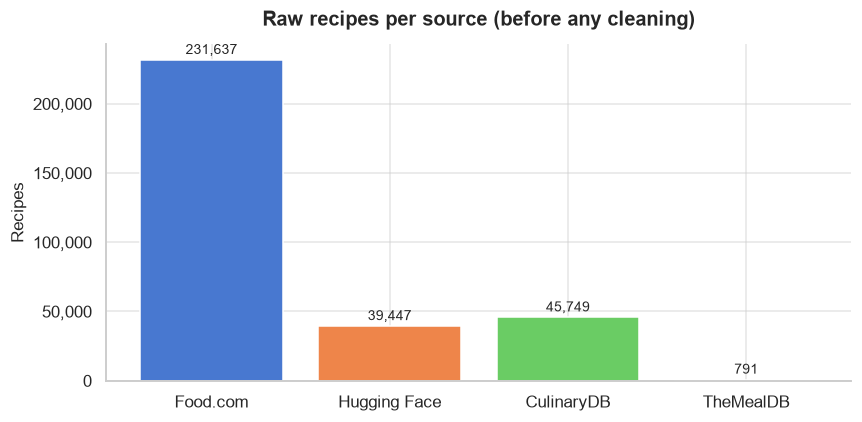

In [22]:
# Chart: how many raw recipes each source provides
raw_counts = pd.Series({"Food.com": len(recipes_raw), "Hugging Face": len(hf_df),
                        **{SOURCE_LABELS[name]: len(df) for name, df in extra_raw.items()}})
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(raw_counts.index, raw_counts.values, color=sns.color_palette("muted", len(raw_counts)))
label_bars(ax)
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title("Raw recipes per source (before any cleaning)")
show_figure(fig, "01_raw_recipes_per_source")

---

## 5.2 Data Quality Assessment

Before we can engineer features, we need to understand what is in our data. We look at:

- **Missing values** - which columns have gaps and how severe are they?
- **Duplicates** - are there repeated recipes that could bias our analysis?
- **Inconsistent units** - calorie values need to be in kcal; quantities need to be numeric.
- **Outliers** - extreme calorie values or cook times that look like data entry errors.

### 5.2.1 Missing Values and Duplicates (Food.com)

In [23]:
# -------------------------------------------------------
# Missing value analysis for the Food.com dataset
# -------------------------------------------------------
missing = recipes_raw.isnull().sum()
missing_pct = (missing / len(recipes_raw) * 100).round(2)

quality_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct"  : missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== Food.com Missing Value Report ===")
print(quality_report.to_string())
print(f"\nTotal rows       : {len(recipes_raw):,}")
print(f"Duplicate rows   : {recipes_raw.duplicated().sum():,}")

=== Food.com Missing Value Report ===
                missing_count  missing_pct
description              4979         2.15
name                        1         0.00
minutes                     0         0.00
id                          0         0.00
contributor_id              0         0.00
submitted                   0         0.00
nutrition                   0         0.00
tags                        0         0.00
n_steps                     0         0.00
steps                       0         0.00
ingredients                 0         0.00
n_ingredients               0         0.00

Total rows       : 231,637


Duplicate rows   : 0


---

### 5.2.2 Missing Values and Duplicates (Hugging Face)

In [24]:
# -------------------------------------------------------
# Missing value analysis for the Hugging Face dataset
# -------------------------------------------------------
hf_missing = hf_df.isnull().sum()
hf_missing_pct = (hf_missing / len(hf_df) * 100).round(2)

hf_quality = pd.DataFrame({
    "missing_count": hf_missing,
    "missing_pct"  : hf_missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== Hugging Face Missing Value Report ===")
print(hf_quality.to_string())
print(f"\nTotal rows       : {len(hf_df):,}")
print(f"Duplicate rows   : {hf_df.duplicated().sum():,}")

=== Hugging Face Missing Value Report ===
                  missing_count  missing_pct
image_url                   277          0.7
recipe_name                   0          0.0
source                        0          0.0
url                           0          0.0
calories                      0          0.0
servings                      0          0.0
total_weight_g                0          0.0
diet_labels                   0          0.0
health_labels                 0          0.0
cautions                      0          0.0
cuisine_type                  0          0.0
meal_type                     0          0.0
dish_type                     0          0.0
ingredient_lines              0          0.0
ingredients                   0          0.0
total_nutrients               0          0.0
daily_values                  0          0.0
digest                        0          0.0

Total rows       : 39,447


Duplicate rows   : 0


---

### 5.2.3 Outliers (Calories, Servings, Cook Time)

#### 5.2.3.1 Outlier checks

In [25]:
# -------------------------------------------------------
# Outlier check - calories per serving in both datasets
# -------------------------------------------------------

# Hugging Face 'calories' is the total for the whole recipe,
# so we divide by 'servings' to get a per-serving value.
hf_servings = pd.to_numeric(hf_df["servings"], errors="coerce")
hf_servings = hf_servings.where(hf_servings > 0)
hf_kcal_per_serving = hf_df["calories"] / hf_servings

print("Whole-recipe calories (Hugging Face):")
print(hf_df["calories"].describe())
print("\nCalories per serving (Hugging Face):")
print(hf_kcal_per_serving.describe())
print(f"\nRows with missing or zero servings          : {hf_servings.isna().sum()}")
print(f"Rows with more than {MAX_SERVINGS} servings              : {(hf_servings > MAX_SERVINGS).sum()}")
print(f"Rows with > {MAX_KCAL_PER_SERVING:,} kcal per serving          : {(hf_kcal_per_serving > MAX_KCAL_PER_SERVING).sum()}")

# Food.com calories are the first value of the 'nutrition' list
# and are already per serving.
fc_kcal_per_serving = pd.to_numeric(
    recipes_raw["nutrition"].str.strip("[]").str.split(",").str[0],
    errors="coerce"
)
print("\nCalories per serving (Food.com):")
print(fc_kcal_per_serving.describe())
print(f"Rows with > {MAX_KCAL_PER_SERVING:,} kcal per serving          : {(fc_kcal_per_serving > MAX_KCAL_PER_SERVING).sum()}")

# Check cook-time outliers in Food.com
print("\nCook time (minutes) distribution (Food.com):")
print(recipes_raw["minutes"].describe())
unrealistic = (recipes_raw["minutes"] > 1440).sum()  # more than 24 hours
print(f"Recipes with cook time > 24 hours : {unrealistic}")

Whole-recipe calories (Hugging Face):
count    39447.000000
mean      2139.060923
std       1924.697195
min          0.060000
25%        866.158614
50%       1656.948000
75%       2817.372416
max      33319.350000
Name: calories, dtype: float64

Calories per serving (Hugging Face):
count    39447.000000
mean       360.003419
std        304.347243
min          0.009000
25%        174.639855
50%        268.987564
75%        444.559492
max       2498.389500
dtype: float64

Rows with missing or zero servings          : 0
Rows with more than 50 servings              : 206
Rows with > 3,000 kcal per serving          : 0



Calories per serving (Food.com):
count    231637.000000
mean        473.942425
std        1189.711374
min           0.000000
25%         174.400000
50%         313.400000
75%         519.700000
max      434360.200000
Name: nutrition, dtype: float64
Rows with > 3,000 kcal per serving          : 3151

Cook time (minutes) distribution (Food.com):
count    2.316370e+05
mean     9.398546e+03
std      4.461963e+06
min      0.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.500000e+01
max      2.147484e+09
Name: minutes, dtype: float64
Recipes with cook time > 24 hours : 2000


#### 5.2.3.2 Chart: what changes when Hugging Face calories are divided by servings

> **What it shows:** Hugging Face lists calories for the whole recipe. Dividing by the number of servings (right) brings them into the same range as Food.com's per-serving values.

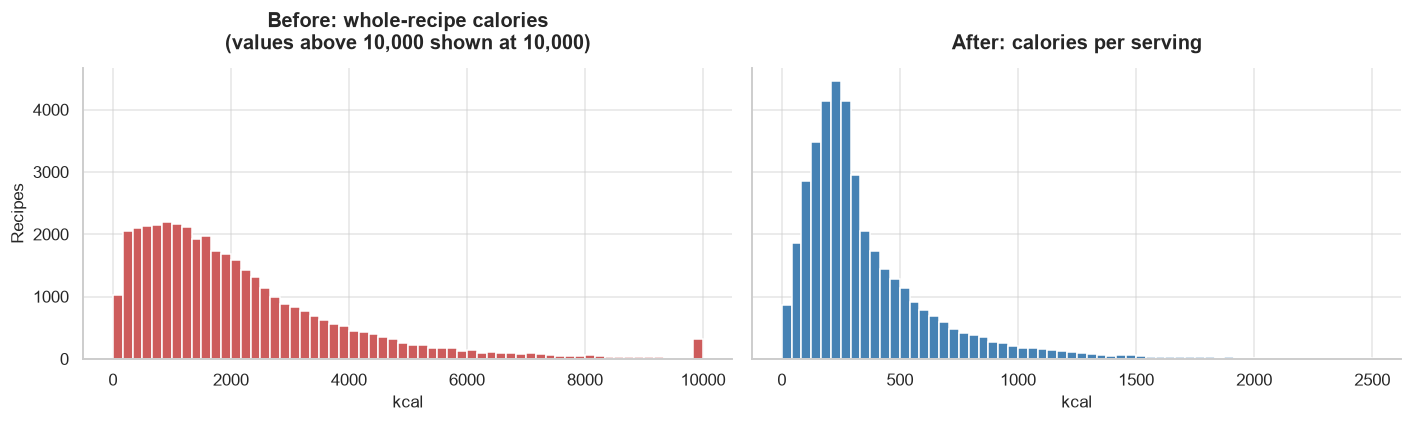

Median before: 1,657 kcal per recipe -> after: 269 kcal per serving


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(hf_df["calories"].clip(upper=10000), bins=60, color="indianred", edgecolor="white")
axes[0].set_title("Before: whole-recipe calories\n(values above 10,000 shown at 10,000)")
axes[1].hist(hf_kcal_per_serving.clip(upper=3000), bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("After: calories per serving")
for ax in axes:
    ax.set_xlabel("kcal")
axes[0].set_ylabel("Recipes")
show_figure(fig, "02_hf_calories_before_after")
print(f"Median before: {hf_df['calories'].median():,.0f} kcal per recipe -> "
      f"after: {hf_kcal_per_serving.median():,.0f} kcal per serving")

---

## 5.3 Data Cleaning

Based on the quality report above, we apply targeted cleaning steps:

1. Drop rows with missing recipe names, ingredient lists, calories, or servings.
2. Remove duplicate recipes.
3. Remove Hugging Face recipes with more than 50 servings (bulk or catering entries; one lists 1,520 servings).
4. Convert Hugging Face calories from whole-recipe totals to calories per serving.
5. Remove recipes above 3,000 kcal per serving (both datasets; Food.com is filtered in 5.4.3 once its nutrition column is parsed).
6. Remove recipes with unrealistically long cook times.

### 5.3.1 Clean the Food.com Dataset

In [27]:
# -------------------------------------------------------
# Clean the Food.com dataset
# -------------------------------------------------------
df_fc = recipes_raw.copy()

# Step 1: Drop rows missing essential fields
before = len(df_fc)
df_fc = df_fc.dropna(subset=["name", "ingredients", "nutrition"])
print(f"Dropped {before - len(df_fc):,} rows with missing name/ingredients/nutrition")

# Step 2: Remove duplicate recipe names (keep the first occurrence)
before = len(df_fc)
df_fc = df_fc.drop_duplicates(subset=["name"], keep="first")
print(f"Dropped {before - len(df_fc):,} duplicate recipe names")

# Step 3: Remove recipes with unrealistically long cook times (> 24 hours)
before = len(df_fc)
df_fc = df_fc[df_fc["minutes"] <= 1440]
print(f"Dropped {before - len(df_fc):,} recipes with cook time > 24 hours")

print(f"\nFood.com clean shape: {df_fc.shape}")

Dropped 1 rows with missing name/ingredients/nutrition


Dropped 1,451 duplicate recipe names
Dropped 1,991 recipes with cook time > 24 hours

Food.com clean shape: (228194, 12)


---

### 5.3.2 Clean the Hugging Face Dataset

#### 5.3.2.1 Clean the dataset

In [28]:
# -------------------------------------------------------
# Clean the Hugging Face dataset
# -------------------------------------------------------
df_hf = hf_df.copy()
df_hf["servings"] = pd.to_numeric(df_hf["servings"], errors="coerce")

# Step 1: Drop rows missing essential fields
before = len(df_hf)
df_hf = df_hf.dropna(subset=["recipe_name", "calories", "cuisine_type", "servings"])
print(f"Dropped {before - len(df_hf):,} rows with missing name/calories/cuisine/servings")

# Step 2: Remove duplicates
before = len(df_hf)
df_hf = df_hf.drop_duplicates(subset=["recipe_name"], keep="first")
print(f"Dropped {before - len(df_hf):,} duplicate recipe names")

# Step 3: Remove recipes with zero servings or too many servings
before = len(df_hf)
df_hf = df_hf[(df_hf["servings"] > 0) & (df_hf["servings"] <= MAX_SERVINGS)].copy()
print(f"Dropped {before - len(df_hf):,} recipes with zero or more than {MAX_SERVINGS} servings")

# Step 4: Convert whole-recipe calories to calories per serving
df_hf["calories_per_serving"] = df_hf["calories"] / df_hf["servings"]

# Step 5: Remove extreme per-serving calorie values
before = len(df_hf)
df_hf = df_hf[df_hf["calories_per_serving"] <= MAX_KCAL_PER_SERVING]
print(f"Dropped {before - len(df_hf):,} recipes with more than {MAX_KCAL_PER_SERVING:,} kcal per serving")

print(f"\nHugging Face clean shape: {df_hf.shape}")

Dropped 0 rows with missing name/calories/cuisine/servings


Dropped 1,205 duplicate recipe names


Dropped 199 recipes with zero or more than 50 servings
Dropped 0 recipes with more than 3,000 kcal per serving

Hugging Face clean shape: (38043, 19)


#### 5.3.2.2 Chart: rows before and after cleaning

> **What it shows:** How many rows each dataset keeps after the cleaning steps above.

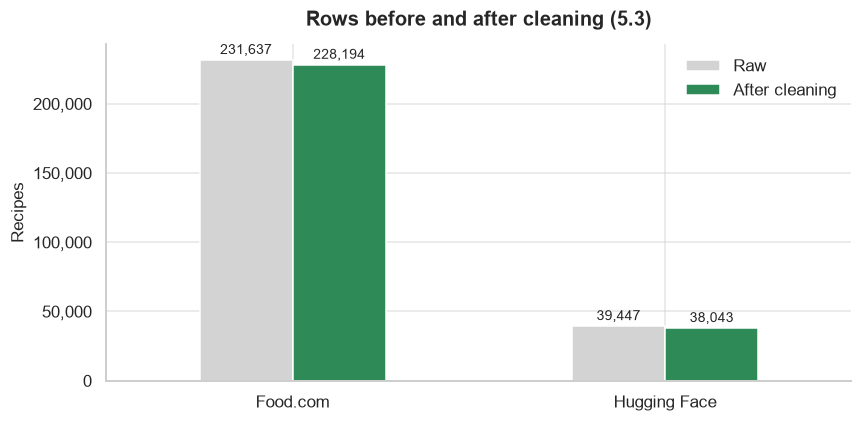

Food.com: 3,443 rows removed (1.5%)
Hugging Face: 1,404 rows removed (3.6%)


In [29]:
cleaning = pd.DataFrame({"Raw": [len(recipes_raw), len(hf_df)],
                         "After cleaning": [len(df_fc), len(df_hf)]},
                        index=["Food.com", "Hugging Face"])
fig, ax = plt.subplots(figsize=(8, 4))
cleaning.plot.bar(ax=ax, rot=0, color=["lightgray", "seagreen"])
label_bars(ax)
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title("Rows before and after cleaning (5.3)")
show_figure(fig, "03_rows_before_after_cleaning")
removed = cleaning["Raw"] - cleaning["After cleaning"]
for name, n in removed.items():
    print(f"{name}: {n:,} rows removed ({n / cleaning.loc[name, 'Raw'] * 100:.1f}%)")

---

## 5.4 Feature Engineering

We engineer the following features that the EverFlavor agents will use directly:

| Feature | Used By | Description |
|---------|---------|-------------|
| `cuisine_family` | All agents | One of: Asian, European, Latin American, African, Middle Eastern, Other |
| `contains_pork`, `contains_alcohol` | Nutritionist | Religious restrictions (for example halal or kosher) |
| `contains_gluten`, `contains_dairy` | Nutritionist | Medical restrictions (celiac disease, lactose intolerance) |
| `contains_egg`, `contains_peanut`, `contains_tree_nut`, `contains_fish`, `contains_shellfish`, `contains_soy`, `contains_sesame` | Nutritionist | Common food allergens |
| `vegetarian`, `vegan` | Nutritionist | Ethical restrictions |
| `calories_per_serving` | Nutritionist | Calorie target matching |
| `protein_g`, `fat_g`, `carbs_g`, `sodium_mg` | Nutritionist | Per serving. Exact for Hugging Face; converted from percent daily value for Food.com (approximate) |
| `ingredient_list` | Chef | Cleaned ingredient names, normalized so that 'eggs', 'large eggs' and 'egg' are one ingredient |
| `complexity` | Chef | Number of unique ingredients (proxy for recipe difficulty) |
| `source` | All agents | Which dataset the recipe came from |

All restriction flags are approximate. They come from ingredient keywords, plus Hugging Face health labels where they exist. When the two disagree, the flag leans toward "contains" (and toward "not vegetarian"), so a restriction filter removes too much rather than too little.

### 5.4.1 Cuisine Family Label

One map turns the cuisine names used by every source (Hugging Face labels, Food.com tags, CulinaryDB regions, TheMealDB countries) into our five families. The first cell defines the map and the matching functions; the second applies them.

#### 5.4.1.1 Cuisine map and matching functions

In [30]:
# -------------------------------------------------------
# 5.4.1 Cuisine Family Label
# One map turns cuisine names from every source into our
# five target families: Hugging Face cuisine labels,
# Food.com tags, CulinaryDB regions and TheMealDB areas.
# -------------------------------------------------------

CUISINE_FAMILIES = {
    "Asian": [
        "asian", "south east asian", "southeast asian", "south east asia", "chinese", "china",
        "cantonese", "szechuan", "hunan", "beijing", "japanese", "japan", "korean", "korea",
        "south korean", "thai", "thailand", "vietnamese", "indian", "india", "indian subcontinent",
        "south asian", "pakistani", "nepalese", "bangladeshi", "sri lankan", "indonesian",
        "malaysian", "filipino", "cambodian", "laotian", "mongolian", "burmese", "singaporean",
        "taiwanese", "cambodia", "laos", "bangladesh", "afghan", "afghanistan",
    ],
    "European": [
        "european", "central europe", "eastern europe", "british", "british isles", "english",
        "irish", "scottish", "welsh", "nordic", "scandinavian", "scandinavia", "swedish",
        "norwegian", "norway", "danish", "finnish", "icelandic", "italian", "italy", "french",
        "france", "greek", "greece", "spanish", "spain", "portuguese", "misc.: portugal", "german",
        "dach countries", "austrian", "swiss", "belgian", "misc.: belgian", "dutch", "netherlands",
        "misc.: dutch", "polish", "russian", "ukrainian", "hungarian", "czech", "croatian",
        "slovakia", "mediterranean", "albania", "albanian", "denmark", "bulgaria",
        "bulgarian", "estonia", "estonian", "belgium", "austria", "andorra",
    ],
    "Latin American": [
        "latin american", "mexican", "mexico", "oaxacan", "baja", "caribbean", "jamaican", "cuban",
        "puerto rican", "central american", "misc.: central america", "costa rican", "guatemalan",
        "honduran", "south american", "south america", "brazilian", "brazil", "peruvian",
        "chilean", "colombian", "argentine", "argentina", "venezuelan", "venezuela", "ecuadorean",
        "uruguayan", "dominica", "colombia", "chile", "costa rica", "cuba", "barbados",
        "aruba", "bahamas", "cayman islands", "antigua and barbuda",
    ],
    "African": [
        "african", "africa", "north african", "west african", "south african", "moroccan",
        "algerian", "tunisian", "libyan", "egyptian", "ethiopian", "nigerian", "kenyan", "somali",
        "somalian", "sudanese", "congolese", "angolan", "namibian", "ghanaian", "senegalese",
        "botswana", "angola",
    ],
    "Middle Eastern": [
        "middle eastern", "middle east", "turkish", "lebanese", "syrian", "persian", "iranian",
        "iranian persian", "iraqi", "palestinian", "israeli", "jordanian", "saudi arabian",
        "yemeni", "emirati", "armenia", "armenian", "azerbaijan", "azerbaijani",
    ],
}
CUISINE_MAP = {name: family for family, names in CUISINE_FAMILIES.items() for name in names}

# A recipe can carry labels from more than one family (for example the
# Food.com tags 'african' and 'middle-eastern' on a Moroccan dish).
# The first family in this list wins. Smaller families come first so
# that a broad tag such as 'european' does not hide a more specific one.
FAMILY_PRIORITY = ["African", "Middle Eastern", "Latin American", "Asian", "European"]


def parse_list_string(raw):
    """Parse a list stored as text, in JSON ('["a"]') or Python ("['a']") form.

    Args:
        raw: The raw value (string, list, or array).

    Returns:
        list: The parsed items, or [] if the value is not a list.
    """
    if isinstance(raw, (list, tuple, np.ndarray)):
        return list(raw)
    if not isinstance(raw, str):
        return []
    for parser in (json.loads, ast.literal_eval):
        try:
            items = parser(raw)
        except (ValueError, SyntaxError):
            continue
        return list(items) if isinstance(items, (list, tuple)) else []
    return []


def parse_label_list(raw):
    """Turn a label value into a list of lowercase labels.

    Handles list strings ('["asian", "indian"]'), real lists, and
    single labels such as 'Middle East'.
    """
    if isinstance(raw, str) and not raw.strip().startswith("["):
        items = [raw]
    else:
        items = parse_list_string(raw)
    return [str(i).strip().lower() for i in items]


def map_cuisine(raw_cuisine, substring_match=True):
    """Map raw cuisine labels to one of the five EverFlavor families.

    Each label is matched exactly against CUISINE_MAP (hyphens count as
    spaces, so the Food.com tag 'south-african' matches 'south african').
    If nothing matches and substring_match is True, we look for a known
    name inside each label. Ties are broken with FAMILY_PRIORITY.

    Args:
        raw_cuisine: Raw label(s) from the dataset.
        substring_match (bool): Allow the substring fallback. Food.com
            tags use exact matching only.

    Returns:
        str: One of Asian / European / Latin American / African /
             Middle Eastern / Other.
    """
    labels = [label.replace("-", " ") for label in parse_label_list(raw_cuisine)]
    families = {CUISINE_MAP[label] for label in labels if label in CUISINE_MAP}
    if not families and substring_match:
        families = {family for label in labels
                    for key, family in CUISINE_MAP.items() if key in label}
    for family in FAMILY_PRIORITY:
        if family in families:
            return family
    return "Other"

#### 5.4.1.2 Apply the map to both datasets

In [31]:
# Hugging Face has a cuisine_type column
df_hf["cuisine_family"] = df_hf["cuisine_type"].apply(map_cuisine)

# Food.com has no cuisine column, but many recipes carry cuisine tags
# such as 'moroccan', 'lebanese' or 'mexican'
df_fc["cuisine_family"] = df_fc["tags"].apply(lambda t: map_cuisine(t, substring_match=False))

print("Cuisine family distribution (Hugging Face):")
print(df_hf["cuisine_family"].value_counts().to_string())
print("\nCuisine family distribution (Food.com, from tags):")
print(df_fc["cuisine_family"].value_counts().to_string())

# Show what ends up in "Other" so the mapping can be checked
print("\nHugging Face cuisine labels mapped to 'Other':")
print(df_hf.loc[df_hf["cuisine_family"] == "Other", "cuisine_type"].value_counts().head(10).to_string())

Cuisine family distribution (Hugging Face):
cuisine_family
Other             17312
European          13877
Asian              3189
Latin American     2953
Middle Eastern      712

Cuisine family distribution (Food.com, from tags):
cuisine_family
Other             178137
European           23857
Asian              11948
Latin American      9530
African             2812
Middle Eastern      1910

Hugging Face cuisine labels mapped to 'Other':
cuisine_type
["american"]             16004
["world"]                 1273
["kosher"]                  34
["kosher","american"]        1


#### 5.4.1.3 Chart: cuisine coverage before and after using Food.com's cuisine tags

> **What it shows:** Using Food.com's own cuisine tags gives many more recipes a cuisine family, so fewer recipes are left as "Other".

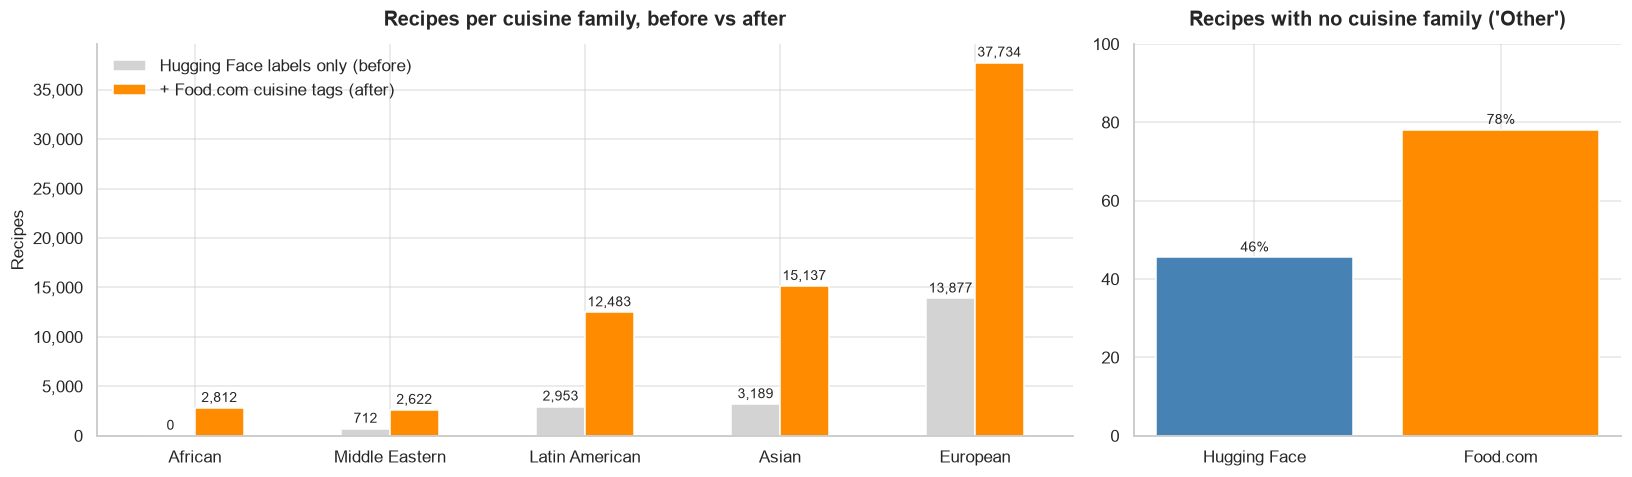

In [32]:
hf_counts = df_hf["cuisine_family"].value_counts().reindex(FAMILY_ORDER, fill_value=0)
fc_counts = df_fc["cuisine_family"].value_counts().reindex(FAMILY_ORDER, fill_value=0)
coverage = pd.DataFrame({"Hugging Face labels only (before)": hf_counts,
                         "+ Food.com cuisine tags (after)": hf_counts + fc_counts})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
coverage.drop(index="Other").plot.bar(ax=axes[0], rot=0, color=["lightgray", "darkorange"])
label_bars(axes[0])
axes[0].set_ylabel("Recipes")
axes[0].set_xlabel("")
thousands(axes[0])
axes[0].set_title("Recipes per cuisine family, before vs after")
other_share = pd.Series({"Hugging Face": (df_hf["cuisine_family"] == "Other").mean() * 100,
                         "Food.com": (df_fc["cuisine_family"] == "Other").mean() * 100})
axes[1].bar(other_share.index, other_share.values, color=["steelblue", "darkorange"])
label_bars(axes[1], fmt="{:.0f}%")
axes[1].set_ylim(0, 100)
axes[1].set_title("Recipes with no cuisine family ('Other')")
show_figure(fig, "04_cuisine_coverage_before_after")

---

### 5.4.2 Dietary Restriction Flags

Flags for religious, medical and ethical restrictions and the most common allergens. The cells below: (1) keyword lists, (2) the matching functions, (3) Food.com flags and an accuracy check against Food.com's own dietary tags, (4) Hugging Face flags, which also use the dataset's health labels.

Keywords are matched as whole words in the ingredients **and the recipe name** ("... with Mussels" counts even when the list leaves the mussels out). The lists were extended after the first blind hand-check in 5.11, which showed that wheat is often hidden in product names (crackers, pastry, spaghetti, buns), and that names such as "butter lettuce" and "sherry vinegar" caused false alarms.

#### 5.4.2.1 Keyword lists

In [33]:
# -------------------------------------------------------
# 5.4.2 Dietary Restriction Flags
# These flags are extracted from ingredient lists and recipe
# names (and, for Hugging Face, health labels). They let the
# Nutritionist Agent filter out recipes that do not meet
# a user's religious, medical or ethical restrictions.
# -------------------------------------------------------
from functools import cache

# --- Keyword lists ---
# Matched as whole words in the ingredients and the recipe name.
# Sausages and cold cuts count as pork unless stated otherwise (the safe side)
PORK_KEYWORDS     = ["pork", "bacon", "ham", "prosciutto", "pancetta", "guanciale",
                     "sausage", "salami", "chorizo", "lard", "lardon", "pepperoni",
                     "kielbasa", "andouille", "bratwurst", "mortadella", "capicola",
                     "boston butt", "spare rib", "baby back rib", "hot dog",
                     "frankfurter", "wiener", "bologna"]
ALCOHOL_KEYWORDS  = ["wine", "beer", "ale", "lager", "rum", "vodka", "whiskey", "whisky",
                     "bourbon", "brandy", "cognac", "sherry", "liqueur", "liquor", "tequila", "gin",
                     "sake", "mirin", "champagne", "prosecco", "vermouth", "kahlua", "amaretto",
                     "marsala", "madeira", "schnapps", "triple sec", "grand marnier", "cointreau",
                     "curacao", "chambord", "frangelico", "baileys", "limoncello", "sambuca", "ouzo",
                     "kirsch", "calvados", "armagnac", "grappa", "mezcal", "pisco", "cachaca", "soju",
                     "shaoxing", "shaohsing", "hard cider"]
# Wheat, barley and rye, including products that are made from them
GLUTEN_KEYWORDS   = ["flour", "bread", "wheat", "pasta", "noodle", "barley", "rye",
                     "soy sauce", "breadcrumb", "cracker", "couscous", "semolina", "bulgur",
                     "spelt", "malt", "seitan", "farro", "orzo", "panko", "beer", "ale", "lager",
                     # pasta shapes and noodles
                     "spaghetti", "macaroni", "lasagna", "lasagne", "penne", "linguine",
                     "fettuccine", "fettuccini", "ditalini", "rigatoni", "ziti", "tortellini",
                     "ravioli", "gnocchi", "vermicelli", "ramen", "udon",
                     # breads, pastry and baked goods
                     "baguette", "bun", "bagel", "brioche", "croissant", "muffin", "biscuit",
                     "pita", "naan", "chapati", "roti", "paratha", "pretzel", "crouton", "pastry",
                     "pie crust", "pie shell", "phyllo", "filo", "dough", "cookie", "dumpling",
                     "wonton", "egg roll wrapper", "spring roll wrapper", "hoagie roll",
                     "dinner roll", "kaiser roll", "sub roll", "bread roll", "matzo", "matzah",
                     "graham", "stuffing", "breading", "bisquick", "cake mix", "brownie mix",
                     "farina", "wheat germ", "durum", "kamut", "freekeh", "triticale",
                     # sauces and soups usually made with wheat
                     "teriyaki", "hoisin", "oyster sauce", "gochujang", "shoyu", "ponzu",
                     "cream of mushroom soup", "cream of chicken soup", "cream of celery soup",
                     "minestrone"]
DAIRY_KEYWORDS    = ["milk", "buttermilk", "cheese", "butter", "cream", "yogurt", "yoghurt",
                     "ghee", "mozzarella", "parmesan", "ricotta", "mascarpone", "feta", "whey",
                     "cheddar", "brie", "camembert", "gouda", "gruyere", "gorgonzola", "burrata",
                     "halloumi", "paneer", "queso", "provolone", "pecorino", "emmental", "manchego",
                     "labneh", "kefir", "quark", "creme fraiche", "half-and-half", "half and half",
                     "custard", "cheesecake", "casein", "caseinate", "whipped topping", "cool whip",
                     "alfredo", "bechamel", "tzatziki", "raita", "lassi"]
EGG_KEYWORDS      = ["egg", "egg white", "egg yolk", "mayonnaise", "mayo", "meringue", "eggnog",
                     "aioli", "hollandaise", "carbonara", "quiche", "frittata", "challah",
                     "brioche", "cheesecake", "macaron", "wonton"]
PEANUT_KEYWORDS   = ["peanut", "peanut butter", "peanut oil", "groundnut"]
TREE_NUT_KEYWORDS = ["almond", "walnut", "pecan", "cashew", "pistachio", "hazelnut",
                     "filbert", "macadamia", "brazil nut", "pine nut", "nut", "nutella",
                     "praline", "marzipan", "macaron", "frangipane", "amaretti", "pesto",
                     "baklava", "nougat", "gianduja", "marcona"]
FISH_KEYWORDS     = ["fish", "salmon", "tuna", "cod", "anchovy", "anchovies", "sardine",
                     "tilapia", "halibut", "trout", "mackerel", "haddock", "catfish",
                     "snapper", "swordfish", "mahi mahi", "flounder", "sole", "hake",
                     "snoek", "pollock", "bass", "kingfish", "orange roughy", "grouper",
                     "perch", "pike", "walleye", "monkfish", "whitefish", "herring",
                     "kipper", "eel", "carp", "bream", "branzino", "surimi", "roe",
                     "fish sauce", "worcestershire sauce", "bonito", "caviar",
                     "dashi", "katsuobushi", "nam pla", "nuoc mam", "caesar dressing"]
SHELLFISH_KEYWORDS = ["shrimp", "prawn", "crab", "crabmeat", "lobster", "langoustine",
                      "langostino", "scampi", "krill", "crawfish", "crayfish", "clam", "cockle",
                      "mussel", "scallop", "oyster", "squid", "calamari", "octopus", "conch",
                      "abalone", "whelk", "belacan", "bagoong"]
SOY_KEYWORDS      = ["soy", "soya", "soy sauce", "soybean", "tofu", "tempeh", "edamame",
                     "miso", "tamari", "teriyaki", "hoisin", "gochujang", "doenjang", "natto",
                     "shoyu", "ponzu", "yuba"]
SESAME_KEYWORDS   = ["sesame", "tahini", "tahina", "halva", "halvah", "za'atar", "zaatar",
                     "za atar", "furikake", "gomasio", "gomashio", "benne"]
LAND_MEAT_KEYWORDS = ["chicken", "beef", "lamb", "mutton", "goat", "turkey", "veal", "duck",
                      "venison", "goose", "rabbit", "bison", "elk", "quail", "pheasant",
                      "cornish hen", "game hen", "fryer", "meat", "steak", "sirloin",
                      "brisket", "chuck", "ground round", "rib eye", "ribeye",
                      "filet mignon", "tri-tip", "porterhouse", "short rib", "oxtail",
                      "pot roast", "rump roast", "round roast", "eye of round", "pastrami",
                      "jerky", "liver", "giblet", "suet", "tallow", "bone marrow",
                      "gelatin", "gelatine", "marshmallow", "jello", "jell-o"] + PORK_KEYWORDS
MEAT_KEYWORDS     = LAND_MEAT_KEYWORDS + FISH_KEYWORDS + SHELLFISH_KEYWORDS
ANIMAL_KEYWORDS   = MEAT_KEYWORDS + DAIRY_KEYWORDS + EGG_KEYWORDS + ["honey"]

# Phrases that contain a keyword but are not that food
# (removed from the text before keywords are matched, longest first)
PORK_EXCEPTIONS     = ["hot dog bun", "hot dog roll", "vegetarian sausage", "veggie sausage",
                       "vegan sausage", "vegetarian bacon", "turkey bacon", "turkey ham"]
ALCOHOL_EXCEPTIONS  = ["wine vinegar", "sherry vinegar", "ginger ale", "ginger beer", "root beer",
                       "non-alcoholic", "alcohol-free", "alcohol free"]
# "gluten-free bread", "gluten free pasta", ...: the food after "gluten-free" is safe
GLUTEN_FREE_FOODS   = ["bread", "flour", "pasta", "noodle", "noodles", "spaghetti", "penne",
                       "macaroni", "cracker", "crackers", "breadcrumb", "breadcrumbs", "soy sauce",
                       "beer", "cookie", "cookies", "dough", "pizza crust", "pie crust", "baking mix",
                       "bisquick", "muffin", "muffins", "bun", "buns", "tortilla", "tortillas",
                       "oats", "teriyaki", "hoisin", "stuffing", "pretzel", "pretzels"]
GLUTEN_EXCEPTIONS   = (["rice flour", "almond flour", "coconut flour", "corn flour", "chickpea flour",
                        "tapioca flour", "potato flour", "cassava flour", "sorghum flour",
                        "arrowroot flour", "teff flour", "millet flour", "quinoa flour", "oat flour",
                        "banana flour", "rice noodle", "rice vermicelli", "rice stick", "rice paper",
                        "glass noodle", "cellophane noodle", "bean thread", "shirataki",
                        "kelp noodle", "zucchini noodle", "sweet potato noodle", "konjac",
                        "spaghetti squash", "cauliflower crust", "corn tortilla", "ginger ale",
                        "rice pasta", "corn pasta", "chickpea pasta", "lentil pasta", "rice cracker",
                        "pasta sauce", "spaghetti sauce", "rice stuffing",
                        "ginger beer", "root beer", "gluten-free", "gluten free"]
                       + [f"gluten{sep}free {food}" for sep in ("-", " ") for food in GLUTEN_FREE_FOODS])
DAIRY_EXCEPTIONS    = ["coconut milk", "almond milk", "soy milk", "oat milk", "rice milk",
                       "cashew milk", "coconut cream", "cream of tartar", "peanut butter",
                       "almond butter", "cashew butter", "apple butter", "cocoa butter",
                       "shea butter", "butter bean", "butter lettuce", "butterhead lettuce",
                       "vegan butter", "plant butter", "vegan cheese", "vegan cream cheese",
                       "dairy-free cheese", "dairy free cheese", "cashew cream", "oat cream",
                       "soy cream", "coconut yogurt", "soy yogurt", "almond yogurt", "vegan yogurt",
                       "non-dairy", "nondairy", "dairy-free", "dairy free"]
EGG_EXCEPTIONS      = ["eggless", "egg-free", "egg free", "egg replacer", "vegan mayo",
                       "vegan mayonnaise", "flax egg", "chia egg"]
PEANUT_EXCEPTIONS   = ["peanut-free", "peanut free"]
TREE_NUT_EXCEPTIONS = ["nut-free", "nut free", "tiger nut"]
SHELLFISH_EXCEPTIONS = ["oyster mushroom"]
MEAT_EXCEPTIONS     = ["oyster mushroom", "duck sauce", "lamb's lettuce", "vegetarian sausage",
                       "veggie sausage", "vegan sausage", "meatless", "meat substitute",
                       "steak sauce", "steak seasoning", "cauliflower steak",
                       "hot dog bun", "hot dog roll", "goat cheese", "goats cheese",
                       "goat's cheese", "goat milk", "goat's milk", "vegan marshmallow",
                       "vegetarian marshmallow"]
ANIMAL_EXCEPTIONS   = MEAT_EXCEPTIONS + DAIRY_EXCEPTIONS + EGG_EXCEPTIONS

# Flag column -> (keywords, exceptions)
FLAG_RULES = {
    "contains_pork"     : (PORK_KEYWORDS, PORK_EXCEPTIONS),
    "contains_alcohol"  : (ALCOHOL_KEYWORDS, ALCOHOL_EXCEPTIONS),
    "contains_gluten"   : (GLUTEN_KEYWORDS, GLUTEN_EXCEPTIONS),
    "contains_dairy"    : (DAIRY_KEYWORDS, DAIRY_EXCEPTIONS),
    "contains_egg"      : (EGG_KEYWORDS, EGG_EXCEPTIONS),
    "contains_peanut"   : (PEANUT_KEYWORDS, PEANUT_EXCEPTIONS),
    "contains_tree_nut" : (TREE_NUT_KEYWORDS, TREE_NUT_EXCEPTIONS),
    "contains_fish"     : (FISH_KEYWORDS, ()),
    "contains_shellfish": (SHELLFISH_KEYWORDS, SHELLFISH_EXCEPTIONS),
    "contains_soy"      : (SOY_KEYWORDS, ()),
    "contains_sesame"   : (SESAME_KEYWORDS, ()),
}
FLAG_COLUMNS = list(FLAG_RULES) + ["vegetarian", "vegan"]

#### 5.4.2.2 Matching functions

In [34]:
# --- Functions that turn keyword lists into true/false flags ---
@cache
def _keyword_pattern(keywords):
    """Compile one whole-word regex for a tuple of keywords (plurals allowed)."""
    alternatives = "|".join(re.escape(k) for k in sorted(keywords, key=len, reverse=True))
    return re.compile(rf"\b(?:{alternatives})(?:s|es)?\b")


def make_flag(ingredient_str, keywords, exceptions=()):
    """Return True if any keyword appears as a whole word in the ingredients.

    Whole-word matching avoids false hits such as 'ham' in 'graham'
    or 'egg' in 'eggplant'. Exception phrases (e.g. 'coconut milk')
    are removed first, longest first, so they do not trigger a keyword.

    Args:
        ingredient_str (str): Ingredient text (may be a list string).
        keywords (list): List of keyword strings to check.
        exceptions (list): Phrases to ignore before matching.

    Returns:
        bool: True if any keyword is found.
    """
    if not isinstance(ingredient_str, str):
        return False
    text = ingredient_str.lower()
    for phrase in sorted(exceptions, key=len, reverse=True):
        text = text.replace(phrase, " ")
    return bool(_keyword_pattern(tuple(keywords)).search(text))


def ingredient_text(value):
    """Turn an ingredient list (or its text form) into one lowercase string."""
    if isinstance(value, str):
        return value.lower()
    if isinstance(value, (list, tuple, np.ndarray)):
        return " | ".join(str(v) for v in value).lower()
    return ""


# A recipe name that declares the dish gluten-free
GLUTEN_FREE_NAME = r"\b(?:gluten[- ]?free|gf|flourless|celiac|coeliac)\b"


def add_keyword_flags(df, ingredient_col, name_col=None):
    """Add every restriction flag to a dataframe from its ingredients and, if given, its name.

    The name catches what the ingredient list leaves out, such as
    "Grilled Lamb Chops with Tzatziki" (only the sauce is listed).
    """
    text = df[ingredient_col].apply(ingredient_text)
    gluten_text = text
    if name_col is not None:
        names = df[name_col].fillna("").astype(str).str.lower()
        text = text + " | " + names
        # "Gluten-free bread" or "flourless cookies": the name describes the kind of dish,
        # not a wheat ingredient, so only the ingredients count for gluten
        gluten_text = text.where(~names.str.contains(GLUTEN_FREE_NAME), gluten_text)
    for col, (keywords, exceptions) in FLAG_RULES.items():
        source_text = gluten_text if col == "contains_gluten" else text
        df[col] = source_text.apply(lambda x, kw=keywords, ex=exceptions: make_flag(x, kw, ex))
    df["vegetarian"] = ~text.apply(lambda x: make_flag(x, MEAT_KEYWORDS, MEAT_EXCEPTIONS))
    df["vegan"]      = ~text.apply(lambda x: make_flag(x, ANIMAL_KEYWORDS, ANIMAL_EXCEPTIONS))
    return df


def add_foodcom_diet_flags(df):
    """Add keyword-based restriction flags to a Food.com dataframe."""
    return add_keyword_flags(df, "ingredients", name_col="name")

#### 5.4.2.3 Food.com flags and accuracy check

In [35]:
# Apply flags to Food.com
df_fc = add_foodcom_diet_flags(df_fc)

print("Restriction flag counts (Food.com):")
for flag in FLAG_COLUMNS:
    pct = df_fc[flag].mean() * 100
    print(f"  {flag:20s}: {df_fc[flag].sum():>8,} ({pct:.1f}%)")

# -------------------------------------------------------
# Accuracy check: Food.com recipes also carry dietary tags
# added by their authors. Where a tag exists, how often does
# our keyword flag agree with it?
# -------------------------------------------------------
TAG_CHECKS = [  # (Food.com tag, our column, value our column should have)
    ("vegetarian",    "vegetarian",        True),
    ("vegan",         "vegan",             True),
    ("gluten-free",   "contains_gluten",   False),
    ("dairy-free",    "contains_dairy",    False),
    ("egg-free",      "contains_egg",      False),
    ("nut-free",      "contains_tree_nut", False),
    ("non-alcoholic", "contains_alcohol",  False),
]
fc_tag_sets = df_fc["tags"].apply(lambda t: set(parse_label_list(t)))
print("\nAgreement with Food.com's own dietary tags:")
for tag, col, expected in TAG_CHECKS:
    tagged = fc_tag_sets.apply(lambda s, tag=tag: tag in s)
    n_tagged = tagged.sum()
    if n_tagged:
        agree = (df_fc.loc[tagged, col] == expected).mean() * 100
        print(f"  '{tag}' tag: {n_tagged:>7,} recipes, our flag agrees on {agree:.1f}%")

# Disagreements are either keyword mistakes or wrong tags; a few examples to review
veg_tagged = fc_tag_sets.apply(lambda s: "vegetarian" in s)
examples = df_fc.loc[veg_tagged & ~df_fc["vegetarian"], "name"].head(5).tolist()
print("\nExamples tagged vegetarian that our flag marks as containing meat or fish:")
for name in examples:
    print(f"  - {name}")

Restriction flag counts (Food.com):
  contains_pork       :   28,286 (12.4%)
  contains_alcohol    :   24,973 (10.9%)
  contains_gluten     :  118,388 (51.9%)
  contains_dairy      :  138,815 (60.8%)
  contains_egg        :   69,344 (30.4%)
  contains_peanut     :    7,420 (3.3%)
  contains_tree_nut   :   28,235 (12.4%)
  contains_fish       :   17,545 (7.7%)
  contains_shellfish  :    9,034 (4.0%)
  contains_soy        :   14,087 (6.2%)
  contains_sesame     :    6,410 (2.8%)
  vegetarian          :  127,253 (55.8%)
  vegan               :   33,595 (14.7%)



Agreement with Food.com's own dietary tags:
  'vegetarian' tag:  35,186 recipes, our flag agrees on 97.0%
  'vegan' tag:   9,850 recipes, our flag agrees on 87.4%
  'gluten-free' tag:   5,639 recipes, our flag agrees on 88.5%
  'dairy-free' tag:     193 recipes, our flag agrees on 79.3%


  'egg-free' tag:   5,002 recipes, our flag agrees on 95.0%
  'nut-free' tag:     214 recipes, our flag agrees on 96.7%
  'non-alcoholic' tag:     298 recipes, our flag agrees on 97.7%

Examples tagged vegetarian that our flag marks as containing meat or fish:
  - fool the meat eaters  chili
  - almost  outback steakhouse shrimp sauce
  - beefy  seitan log
  - boo tiful  jell o cups
  - whatever floats your boat  brownies


#### 5.4.2.4 Hugging Face flags

In [36]:
# --- Flags for the Hugging Face dataset ---
# Keyword flags from 'ingredient_lines', combined with the
# 'health_labels' column (a JSON list string).

# Which health labels does this dataset actually use?
hf_label_sets = df_hf["health_labels"].apply(lambda x: set(parse_label_list(x)))
label_counts = pd.Series([l for s in hf_label_sets for l in s]).value_counts()
print("Health labels in the Hugging Face dataset:")
print(label_counts.to_string())

# Flag column -> the "free of" label that rules it out
HF_FREE_LABELS = {
    "contains_gluten"   : "gluten-free",
    "contains_dairy"    : "dairy-free",
    "contains_egg"      : "egg-free",
    "contains_peanut"   : "peanut-free",
    "contains_tree_nut" : "tree-nut-free",
    "contains_fish"     : "fish-free",
    "contains_shellfish": "shellfish-free",
    "contains_soy"      : "soy-free",
}


def add_hf_diet_flags(df):
    """Add restriction flags to a Hugging Face dataframe.

    Keyword flags come from the ingredient lines and the recipe name. Where the dataset has a
    "free of" label, a recipe without that label is also flagged: either
    source is enough, which is the safe direction for a restriction
    filter. Vegetarian and vegan need the label AND no meat / animal
    keyword (some labels are wrong, e.g. short ribs tagged Vegetarian).
    Pork, alcohol and sesame have no label here, so they use keywords only.
    """
    labels = df["health_labels"].apply(lambda x: set(parse_label_list(x)))
    df = add_keyword_flags(df, "ingredient_lines", name_col="recipe_name")
    for col, free_label in HF_FREE_LABELS.items():
        df[col] = df[col] | ~labels.apply(lambda s, label=free_label: label in s)
    df["vegetarian"] = labels.apply(lambda s: "vegetarian" in s) & df["vegetarian"]
    df["vegan"]      = labels.apply(lambda s: "vegan" in s) & df["vegan"]
    return df

veg_labels = hf_label_sets.apply(lambda s: "vegetarian" in s)
df_hf = add_hf_diet_flags(df_hf)

print("\nRestriction flag counts (Hugging Face):")
for flag in FLAG_COLUMNS:
    pct = df_hf[flag].mean() * 100
    print(f"  {flag:20s}: {df_hf[flag].sum():>8,} ({pct:.1f}%)")
print(f"\nVegetarian labels overridden by meat or fish in the ingredients: {(veg_labels & ~df_hf['vegetarian']).sum():,}")

Health labels in the Hugging Face dataset:
peanut-free       36552
shellfish-free    36412
fish-free         34870
soy-free          34271
tree-nut-free     32541
egg-free          28728
vegetarian        23584
gluten-free       21533
dairy-free        18663
vegan              9610
paleo              4502
low sugar            90



Restriction flag counts (Hugging Face):
  contains_pork       :    4,371 (11.5%)
  contains_alcohol    :    3,919 (10.3%)
  contains_gluten     :   17,197 (45.2%)
  contains_dairy      :   19,793 (52.0%)
  contains_egg        :    9,478 (24.9%)
  contains_peanut     :    1,500 (3.9%)
  contains_tree_nut   :    5,770 (15.2%)
  contains_fish       :    3,283 (8.6%)
  contains_shellfish  :    1,699 (4.5%)
  contains_soy        :    3,794 (10.0%)
  contains_sesame     :    1,517 (4.0%)
  vegetarian          :   23,182 (60.9%)
  vegan               :    9,037 (23.8%)

Vegetarian labels overridden by meat or fish in the ingredients: 402


#### 5.4.2.5 Chart: how common each restriction is, and how well our flags match Food.com's tags

> **What it shows:** Left: how common each restriction is in each dataset. Right: how often our keyword flags agree with Food.com's own dietary tags (green = 95% or better).

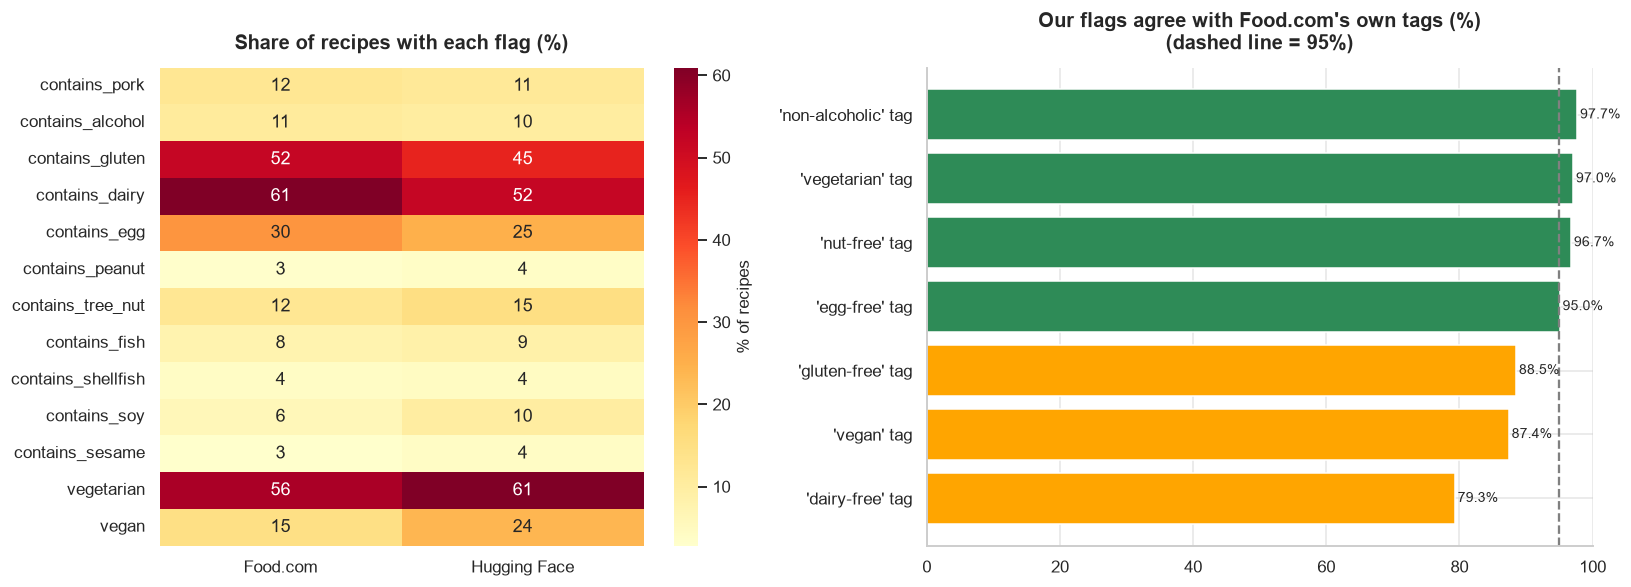

In [37]:
prevalence = pd.DataFrame({"Food.com": df_fc[FLAG_COLUMNS].mean() * 100,
                           "Hugging Face": df_hf[FLAG_COLUMNS].mean() * 100})
agreement = {}
for tag, col, expected in TAG_CHECKS:
    tagged = fc_tag_sets.apply(lambda s, tag=tag: tag in s)
    if tagged.any():
        agreement[f"'{tag}' tag"] = (df_fc.loc[tagged, col] == expected).mean() * 100
agreement = pd.Series(agreement).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 1.1]})
sns.heatmap(prevalence, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0],
            cbar_kws={"label": "% of recipes"})
axes[0].set_title("Share of recipes with each flag (%)")
colors = ["seagreen" if v >= 95 else "orange" for v in agreement.values]
axes[1].barh(agreement.index, agreement.values, color=colors)
axes[1].axvline(95, ls="--", color="gray")
axes[1].set_xlim(0, 100)
label_bars(axes[1], fmt="{:.1f}%")
axes[1].set_title("Our flags agree with Food.com's own tags (%)\n(dashed line = 95%)")
show_figure(fig, "05_restriction_flags")

---

### 5.4.3 Macronutrients Per Serving

Calories, protein, fat, carbs and sodium per serving for both datasets. The first cell defines the conversions; the second applies them and checks the Food.com conversion.

#### 5.4.3.1 Conversion functions

In [38]:
# -------------------------------------------------------
# 5.4.3 Macronutrients Per Serving (both datasets)
#
# Food.com: the 'nutrition' column is a string that encodes
# [calories, total_fat_%dv, sugar_%dv, sodium_%dv,
#  protein_%dv, saturated_fat_%dv, carbs_%dv]
# Calories are per serving; the rest are percent daily
# values. We convert them to grams with the FDA reference
# values that were on US labels when the recipes were posted
# (65 g fat, 300 g carbs, 50 g protein, 2,400 mg sodium).
# The check at the end of this cell confirms the result.
#
# Hugging Face: 'total_nutrients' already has grams for the
# whole recipe, so we divide by servings.
# -------------------------------------------------------

FOODCOM_DAILY_VALUES = {  # new column: (percent column, daily value)
    "fat_g"    : ("fat_pdv", 65),
    "carbs_g"  : ("carbs_pdv", 300),
    "protein_g": ("protein_pdv", 50),
    "sodium_mg": ("sodium_pdv", 2400),
}
HF_NUTRIENT_CODES = {"protein_g": "PROCNT", "fat_g": "FAT", "carbs_g": "CHOCDF", "sodium_mg": "NA"}


def parse_nutrition(nut_str):
    """Parse the nutrition column from Food.com into named fields.

    Args:
        nut_str (str): A string like '[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]'.

    Returns:
        dict: Named nutrient values, or a dict of None values on failure.
    """
    keys = ["calories", "fat_pdv", "sugar_pdv", "sodium_pdv",
            "protein_pdv", "sat_fat_pdv", "carbs_pdv"]
    try:
        values = ast.literal_eval(nut_str)
        return dict(zip(keys, values))
    except (ValueError, TypeError, SyntaxError, MemoryError, RecursionError):
        return {k: None for k in keys}


def add_foodcom_macros(df):
    """Add calories per serving and macros in grams to a Food.com dataframe."""
    nut = pd.DataFrame(df["nutrition"].apply(parse_nutrition).tolist(), index=df.index)
    nut = nut.rename(columns={"calories": "calories_per_serving"}).astype(float)
    df = df.drop(columns=[c for c in nut.columns if c in df.columns]).join(nut)
    for col, (pdv_col, daily_value) in FOODCOM_DAILY_VALUES.items():
        df[col] = df[pdv_col] * daily_value / 100
    return df


def hf_nutrients_per_serving(total_nutrients, servings):
    """Return protein, fat, carbs (g) and sodium (mg) per serving from a HF row."""
    try:
        data = json.loads(total_nutrients)
    except (TypeError, ValueError):
        data = {}
    return {col: (data.get(code) or {}).get("quantity", np.nan) / servings
            for col, code in HF_NUTRIENT_CODES.items()}


def add_hf_macros(df):
    """Add macros per serving to a Hugging Face dataframe."""
    per_serving = pd.DataFrame(
        [hf_nutrients_per_serving(t, s) for t, s in zip(df["total_nutrients"], df["servings"])],
        index=df.index)
    return df.drop(columns=[c for c in per_serving.columns if c in df.columns]).join(per_serving)

#### 5.4.3.2 Apply them and check the Food.com conversion

In [39]:
# Food.com
df_fc = add_foodcom_macros(df_fc)
before = len(df_fc)
df_fc = df_fc[df_fc["calories_per_serving"] <= MAX_KCAL_PER_SERVING]
print(f"Dropped {before - len(df_fc):,} Food.com recipes with missing calories or more than {MAX_KCAL_PER_SERVING:,} kcal per serving")

# Hugging Face
df_hf = add_hf_macros(df_hf)

macro_cols = ["calories_per_serving", "protein_g", "fat_g", "carbs_g", "sodium_mg"]
print("\nPer-serving nutrition (Food.com, macros converted from percent daily value):")
print(df_fc[macro_cols].describe().round(1).to_string())
print("\nPer-serving nutrition (Hugging Face):")
print(df_hf[macro_cols].describe().round(1).to_string())

# Check: do the converted grams add up to the listed calories?
# (fat 9 kcal/g, protein and carbs 4 kcal/g)
check = df_fc[df_fc["calories_per_serving"] > 50]
estimate = 9 * check["fat_g"] + 4 * (check["protein_g"] + check["carbs_g"])
ratio = estimate / check["calories_per_serving"]
print("\nFood.com check - calories from converted grams / listed calories:")
print(f"  median {ratio.median():.2f}, middle 50% between {ratio.quantile(0.25):.2f} and {ratio.quantile(0.75):.2f} (1.00 = exact)")

Dropped 3,049 Food.com recipes with missing calories or more than 3,000 kcal per serving



Per-serving nutrition (Food.com, macros converted from percent daily value):
       calories_per_serving  protein_g     fat_g   carbs_g  sodium_mg
count              225145.0   225145.0  225145.0  225145.0   225145.0
mean                  407.4       16.2      20.1      38.6      658.1
std                   382.6       18.9      24.8      51.6     2390.6
min                     0.0        0.0       0.0       0.0        0.0
25%                   172.6        3.0       5.2      12.0      120.0
50%                   308.8        9.0      13.0      27.0      336.0
75%                   506.9       24.5      26.0      48.0      768.0
max                  2999.8      417.0     324.4     756.0   351936.0

Per-serving nutrition (Hugging Face):
       calories_per_serving  protein_g    fat_g  carbs_g  sodium_mg
count               38043.0    38043.0  38042.0  38043.0    38043.0
mean                  362.6       14.7     18.6     34.4      460.7
std                   304.8       17.5     21.7  


Food.com check - calories from converted grams / listed calories:
  median 0.98, middle 50% between 0.95 and 1.00 (1.00 = exact)


#### 5.4.3.3 Chart: macronutrients per serving in each dataset

> **What it shows:** Protein, fat and carbs per serving in the two datasets that have nutrition data. Similar boxes mean the Food.com conversion to grams is in a believable range.

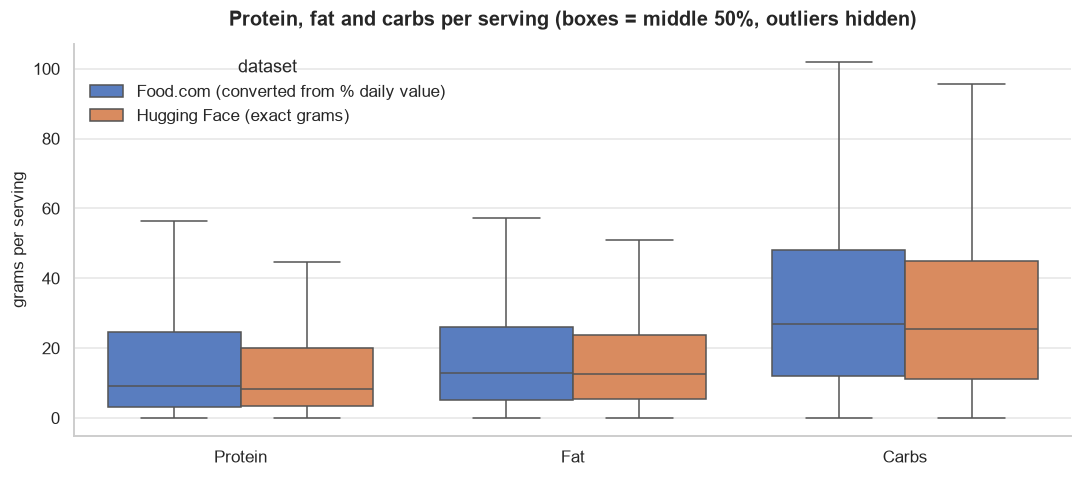

In [40]:
macro_long = pd.concat([
    df_fc[["protein_g", "fat_g", "carbs_g"]].assign(dataset="Food.com (converted from % daily value)"),
    df_hf[["protein_g", "fat_g", "carbs_g"]].assign(dataset="Hugging Face (exact grams)"),
]).melt(id_vars="dataset", var_name="nutrient", value_name="grams per serving")

macro_long["nutrient"] = macro_long["nutrient"].map({"protein_g": "Protein", "fat_g": "Fat", "carbs_g": "Carbs"})
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=macro_long, x="nutrient", y="grams per serving", hue="dataset",
            showfliers=False, ax=ax)
ax.set_xlabel("")
ax.set_title("Protein, fat and carbs per serving (boxes = middle 50%, outliers hidden)")
show_figure(fig, "06_macros_by_dataset")

---

### 5.4.4 Cleaned and Normalized Ingredient Lists

Ingredient names are parsed into lists and normalized so that variants count as one ingredient. The first cell defines the rules; the second applies them.

#### 5.4.4.1 Normalizing rules

In [41]:
# -------------------------------------------------------
# 5.4.4 Cleaned and Normalized Ingredient Lists
# Convert the raw ingredient strings into Python lists,
# then normalize each name so that variants of the same
# ingredient count as one ('eggs', 'large eggs' -> 'egg').
# -------------------------------------------------------

# Exact names that mean the same ingredient
INGREDIENT_SYNONYMS = {
    "garlic clove": "garlic", "clove garlic": "garlic", "large egg": "egg",
    "all-purpose flour": "flour", "all purpose flour": "flour", "plain flour": "flour",
    "kosher salt": "salt", "sea salt": "salt", "table salt": "salt",
    "granulated sugar": "sugar", "white sugar": "sugar",
    "unsalted butter": "butter", "salted butter": "butter",
    "extra virgin olive oil": "olive oil", "extra-virgin olive oil": "olive oil",
    "ground black pepper": "black pepper", "fresh ground black pepper": "black pepper",
    "freshly ground black pepper": "black pepper",
    "scallion": "green onion", "spring onion": "green onion",
    "courgette": "zucchini", "aubergine": "eggplant",
    "fresh cilantro": "cilantro", "fresh coriander": "cilantro", "coriander leaf": "cilantro",
    "garbanzo bean": "chickpea", "chick pea": "chickpea",
}
# Entries that are really two ingredients
SPLIT_INGREDIENTS = {
    "salt and pepper": ["salt", "pepper"],
    "salt & pepper": ["salt", "pepper"],
    "salt and black pepper": ["salt", "black pepper"],
    "salt and freshly ground black pepper": ["salt", "black pepper"],
}
# Leading quantities and units, as in CulinaryDB lines such as
# "1/2 cup grated parmesan cheese" or "2 cloves garlic, minced"
QUANTITY_PATTERN = re.compile(r"^(?:[\d½¼¾⅓⅔⅛]+(?:[./-][\d½¼¾⅓⅔⅛]+)?\s+)+")
UNIT_WORDS = ["cups?", "c", "tablespoons?", "tbsps?", "tbs", "teaspoons?", "tsps?", "ounces?",
              "oz", "pounds?", "lbs?", "grams?", "g", "kg", "kilograms?", "ml", "milliliters?",
              "liters?", "litres?", "l", "pints?", "quarts?", "gallons?", "cans?", "packages?",
              "pkgs?", "jars?", "bottles?", "sticks?", "cloves?", "heads?", "bunch(?:es)?",
              "slices?", "pieces?", "pinch(?:es)?", "dash(?:es)?", "handfuls?", "sprigs?",
              "stalks?", "envelopes?", "containers?", "box(?:es)?", "bags?", "large", "medium",
              "small", "extra-large", "whole", "of"]
UNIT_PATTERN = re.compile(r"^(?:(?:" + "|".join(UNIT_WORDS) + r")\.?\s+)+")
# Preparation words at the start of a name ("chopped onion" -> "onion")
PREP_PATTERN = re.compile(r"^(?:(?:chopped|minced|diced|sliced|grated|shredded|crushed|peeled|"
                          r"fresh|freshly|finely|coarsely|thinly|roughly)\s+)+")

# Words that look plural but are not, and irregular plurals
KEEP_AS_IS = {"molasses", "hummus", "couscous", "asparagus", "citrus", "swiss", "grits",
              "greens", "brussels", "bitters", "schnapps", "oats"}
IRREGULAR_PLURALS = {"leaves": "leaf", "loaves": "loaf", "halves": "half",
                     "cookies": "cookie", "brownies": "brownie", "pies": "pie"}


def singular(word):
    """Return a simple singular form of one word ('tomatoes' -> 'tomato')."""
    if word in IRREGULAR_PLURALS:
        return IRREGULAR_PLURALS[word]
    if word in KEEP_AS_IS or len(word) <= 3:
        return word
    if word.endswith("ies"):
        return word[:-3] + "y"
    if word.endswith("oes"):
        return word[:-2]
    if word.endswith(("ches", "shes", "sses", "xes")):
        return word[:-2]
    if word.endswith("s") and not word.endswith(("ss", "us", "is")):
        return word[:-1]
    return word


def normalize_ingredient(name):
    """Normalize one ingredient name. Returns a list (a few entries split in two).

    Steps: drop notes in brackets, strip a leading quantity and unit
    ("1/2 cup ..."), keep only the part before a comma or " or "
    ("onion, chopped" / "canola oil or vegetable oil"), drop leading
    preparation words, then apply synonyms and a simple singular form.
    """
    text = re.sub(r"\(.*?\)", " ", str(name).lower())   # drop notes in brackets
    text = re.sub(r"\s+", " ", text).strip(" ,.;:-")
    quantity = QUANTITY_PATTERN.match(text)
    if quantity:
        text = UNIT_PATTERN.sub("", text[quantity.end():])
    text = text.split(",")[0].split(" or ")[0]
    text = PREP_PATTERN.sub("", text).strip(" ,.;:-")
    if text in SPLIT_INGREDIENTS:
        return SPLIT_INGREDIENTS[text]
    text = INGREDIENT_SYNONYMS.get(text, text)
    words = text.split()
    if words:
        words[-1] = singular(words[-1])
        text = " ".join(words)
    text = INGREDIENT_SYNONYMS.get(text, text)
    return [text] if text else []


def normalize_ingredient_list(items):
    """Normalize every ingredient in a list and drop repeats (order kept)."""
    out = []
    for item in items:
        out.extend(normalize_ingredient(item))
    return list(dict.fromkeys(out))


def clean_ingredients(raw):
    """Parse a raw ingredient list string into a list of lowercase names.

    Food.com stores lists in Python format ("['salt', 'sugar']") and
    Hugging Face in JSON format ('["salt", "sugar"]'); both are handled.
    """
    return [re.sub(r"\s+", " ", str(i).lower().strip()) for i in parse_list_string(raw)]


def hf_ingredient_foods(raw):
    """Return the plain food names from the Hugging Face 'ingredients' JSON.

    Each entry looks like {"food": "kosher salt", "text": "1 tablespoon kosher salt", ...};
    the 'food' field has no quantities, so it is the better ingredient name.
    """
    return [d["food"] for d in parse_list_string(raw) if isinstance(d, dict) and d.get("food")]

#### 5.4.4.2 Build normalized lists

In [42]:
# --- Build normalized ingredient lists for both datasets ---
df_fc["ingredient_list"] = df_fc["ingredients"].apply(clean_ingredients).apply(normalize_ingredient_list)
df_hf["ingredient_list"] = df_hf["ingredients"].apply(hf_ingredient_foods).apply(normalize_ingredient_list)

# Show a few examples before and after normalizing
print("Sample ingredient lists (Food.com), raw -> normalized:")
for _, row in df_fc[["name", "ingredients", "ingredient_list"]].head(3).iterrows():
    print(f"  {row['name']}")
    print(f"    raw       : {clean_ingredients(row['ingredients'])[:5]}")
    print(f"    normalized: {row['ingredient_list'][:5]}")

raw_names = {i for lst in df_fc["ingredients"].apply(clean_ingredients) for i in lst}
norm_names = {i for lst in df_fc["ingredient_list"] for i in lst}
print(f"\nUnique Food.com ingredient names: {len(raw_names):,} raw -> {len(norm_names):,} normalized")

Sample ingredient lists (Food.com), raw -> normalized:
  arriba   baked winter squash mexican style
    raw       : ['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter']
    normalized: ['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter']
  a bit different  breakfast pizza
    raw       : ['prepared pizza crust', 'sausage patty', 'eggs', 'milk', 'salt and pepper']
    normalized: ['prepared pizza crust', 'sausage patty', 'egg', 'milk', 'salt']
  all in the kitchen  chili
    raw       : ['ground beef', 'yellow onions', 'diced tomatoes', 'tomato paste', 'tomato soup']
    normalized: ['ground beef', 'yellow onion', 'tomato', 'tomato paste', 'tomato soup']



Unique Food.com ingredient names: 14,818 raw -> 13,362 normalized


#### 5.4.4.3 Chart: what ingredient normalization changed

> **What it shows:** Normalizing merges spelling variants, so there are far fewer unique ingredient names, and the most common ones are clean names.

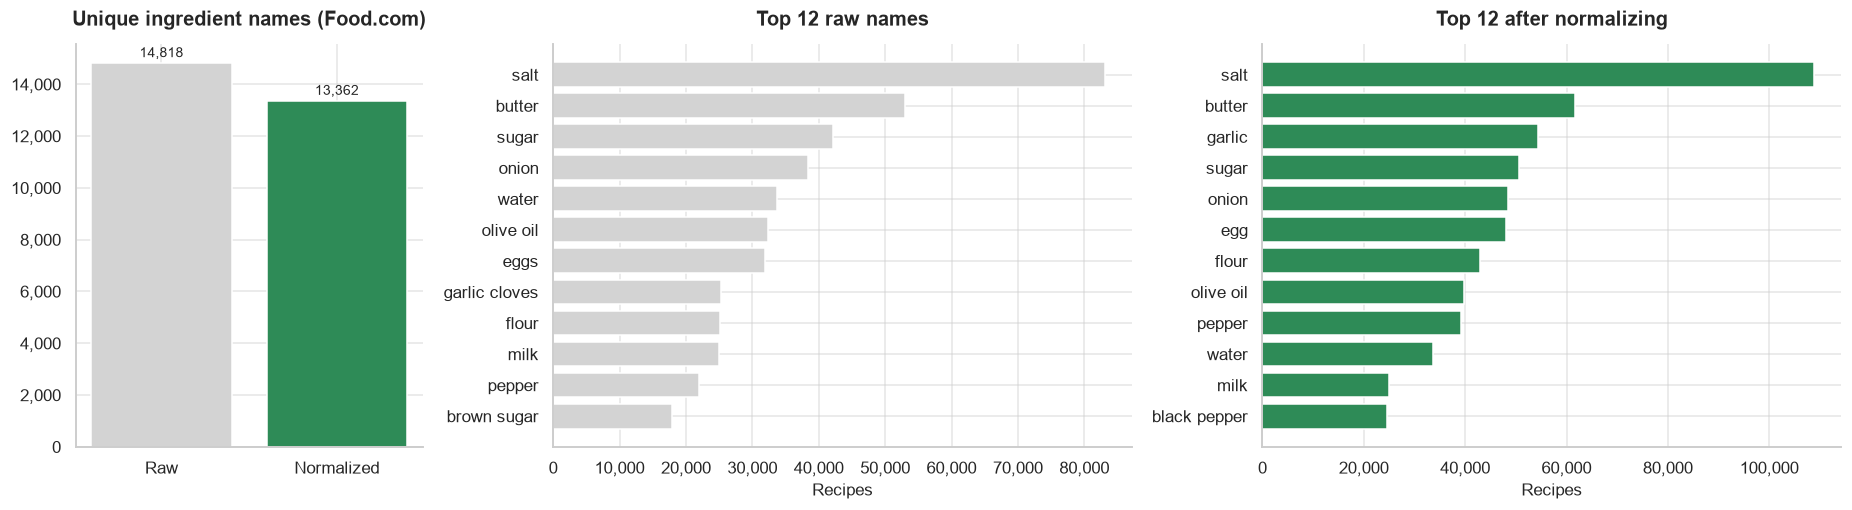

In [43]:
from collections import Counter

raw_top = Counter(i for lst in df_fc["ingredients"].apply(clean_ingredients) for i in lst).most_common(12)
norm_top = Counter(i for lst in df_fc["ingredient_list"] for i in lst).most_common(12)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [0.6, 1, 1]})
axes[0].bar(["Raw", "Normalized"], [len(raw_names), len(norm_names)], color=["lightgray", "seagreen"])
label_bars(axes[0])
thousands(axes[0])
axes[0].set_title("Unique ingredient names (Food.com)")
for ax, top, title, color in [(axes[1], raw_top, "Top 12 raw names", "lightgray"),
                              (axes[2], norm_top, "Top 12 after normalizing", "seagreen")]:
    names, counts = zip(*top[::-1])
    ax.barh(names, counts, color=color)
    ax.set_title(title)
    ax.set_xlabel("Recipes")
    thousands(ax, "x")
show_figure(fig, "07_ingredient_normalization")

---

### 5.4.5 Recipe Complexity

In [44]:
# -------------------------------------------------------
# 5.4.5 Recipe Complexity Proxy
# We define complexity as the number of unique ingredients
# in a recipe. More ingredients typically means more prep
# work and a harder recipe for the Chef Agent to explain.
# -------------------------------------------------------

for df in (df_fc, df_hf):
    df["complexity"] = df["ingredient_list"].apply(lambda lst: len(set(lst)))

print("Recipe complexity statistics (number of unique ingredients, Food.com):")
print(df_fc["complexity"].describe())
print()
print("Example simple recipe (fewest ingredients):")
print(df_fc.nsmallest(1, "complexity")[["name", "complexity", "ingredient_list"]].values)

Recipe complexity statistics (number of unique ingredients, Food.com):
count    225145.000000
mean          9.092078
std           3.722454
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: complexity, dtype: float64

Example simple recipe (fewest ingredients):
[['apple cider reduction' 1 list(['apple cider'])]]


---

## 5.5 Transformation Pipeline

We wrap all cleaning and feature engineering steps into a reusable function that handles every source (Food.com, Hugging Face, CulinaryDB, TheMealDB) and returns the same columns for each, so they can be combined in 5.6. This makes it easy to re-apply the pipeline to new data or to test variations.

#### 5.5.1 The run_pipeline() function

In [45]:
# Columns every source ends up with (missing values are NaN / None)
COMMON_COLUMNS = (["recipe_id", "source", "recipe_name", "cuisine_family", "cuisine_raw",
                   "ingredient_list", "complexity", "calories_per_serving", "protein_g",
                   "fat_g", "carbs_g", "sodium_mg", "servings", "minutes", "instructions", "url"]
                  + FLAG_COLUMNS)


def cuisine_names(raw):
    """Return the labels in `raw` that are known cuisine names, joined by ', '."""
    return ", ".join(l for l in parse_label_list(raw) if l.replace("-", " ") in CUISINE_MAP)


def run_pipeline(df_in, source="foodcom"):
    """Apply the full EverFlavor preprocessing pipeline to a raw dataframe.

    Uses the same helper functions as the step-by-step cells above,
    so both paths produce the same features.

    Args:
        df_in (pd.DataFrame): The raw input dataframe.
        source (str): 'foodcom', 'huggingface', 'culinarydb' or 'themealdb'.

    Returns:
        pd.DataFrame: Cleaned recipes with the COMMON_COLUMNS.
    """
    df = df_in.copy()

    if source == "foodcom":
        df = df.dropna(subset=["name", "ingredients", "nutrition"])
        df = df.drop_duplicates(subset=["name"], keep="first")
        df = df[df["minutes"] <= 1440]
        df = add_foodcom_macros(df)
        df = df[df["calories_per_serving"] <= MAX_KCAL_PER_SERVING].copy()
        df["ingredient_list"] = df["ingredients"].apply(clean_ingredients).apply(normalize_ingredient_list)
        df = add_foodcom_diet_flags(df)
        df["cuisine_family"] = df["tags"].apply(lambda t: map_cuisine(t, substring_match=False))
        df["cuisine_raw"]    = df["tags"].apply(cuisine_names)
        df["recipe_id"]      = "foodcom_" + df["id"].astype(str)
        df["recipe_name"]    = df["name"].str.replace(r"\s+", " ", regex=True).str.strip()
        df["instructions"]   = df["steps"].apply(lambda s: "\n".join(map(str, parse_list_string(s))))

    elif source == "huggingface":
        df["recipe_id"] = "hf_" + df.index.astype(str)
        df["servings"]  = pd.to_numeric(df["servings"], errors="coerce")
        df = df.dropna(subset=["recipe_name", "calories", "cuisine_type", "servings"])
        df = df.drop_duplicates(subset=["recipe_name"], keep="first")
        df = df[(df["servings"] > 0) & (df["servings"] <= MAX_SERVINGS)].copy()
        # 'calories' is for the whole recipe; convert to per serving
        df["calories_per_serving"] = df["calories"] / df["servings"]
        df = df[df["calories_per_serving"] <= MAX_KCAL_PER_SERVING].copy()
        df = add_hf_macros(df)
        df["ingredient_list"] = df["ingredients"].apply(hf_ingredient_foods).apply(normalize_ingredient_list)
        df = add_hf_diet_flags(df)
        df["cuisine_family"] = df["cuisine_type"].apply(map_cuisine)
        df["cuisine_raw"]    = df["cuisine_type"].apply(lambda x: ", ".join(parse_label_list(x)))

    elif source in ("culinarydb", "themealdb"):
        cuisine_col = "cuisine" if source == "culinarydb" else "area"
        df = df.dropna(subset=["recipe_name", "ingredients"])
        df = df.drop_duplicates(subset=["recipe_name"], keep="first").copy()
        df["ingredient_list"] = df["ingredients"].apply(lambda x: normalize_ingredient_list(parse_list_string(x)))
        df = add_keyword_flags(df, "ingredients", name_col="recipe_name")
        df["cuisine_family"] = df[cuisine_col].apply(map_cuisine)
        df["cuisine_raw"]    = df[cuisine_col].fillna("").astype(str).str.lower()
        df["recipe_id"]      = source + "_" + df["recipe_id"].astype(str)
        if source == "themealdb":
            df["url"] = df["source_url"]

    else:
        raise ValueError(f"Unknown source '{source}'. Use 'foodcom', 'huggingface', 'culinarydb' or 'themealdb'.")

    df["source"]     = source
    df["complexity"] = df["ingredient_list"].apply(lambda x: len(set(x)))
    for col in COMMON_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
    return df[COMMON_COLUMNS].reset_index(drop=True)

#### 5.5.2 Run the pipeline on every source

In [46]:
# Re-run the pipeline on every dataset (clean start)
df_fc_clean = run_pipeline(recipes_raw, source="foodcom")
df_hf_clean = run_pipeline(hf_df, source="huggingface")
extra_clean = {name: run_pipeline(df, source=name) for name, df in extra_raw.items()}

print(f"Food.com after pipeline     : {df_fc_clean.shape}")
print(f"Hugging Face after pipeline : {df_hf_clean.shape}")
for name, df in extra_clean.items():
    print(f"{name + ' after pipeline':28s}: {df.shape}")

Food.com after pipeline     : (225145, 29)
Hugging Face after pipeline : (38043, 29)
culinarydb after pipeline   : (44421, 29)
themealdb after pipeline    : (791, 29)


---

## 5.6 Combine All Sources

We stack every cleaned source into one recipe table. The same recipe can appear in more than one source (CulinaryDB, for example, was built from Allrecipes, Food Network and Epicurious, which overlap with the others). We treat recipes with the same title (ignoring case and punctuation) as duplicates and keep the copy with the most information: Hugging Face first (exact nutrition and health labels), then Food.com, TheMealDB and CulinaryDB.

After combining we also:
- drop recipes with fewer than 2 ingredients;
- mark which recipes have nutrition data (`has_nutrition`) and whether it is believable (`nutrition_plausible`): at least 10 kcal, at most 5,000 mg sodium and 150 g protein, and protein, fat and carbs that add up to within 30% of the listed calories;
- mark which recipes have a real cuisine label (`cuisine_labeled`), so cuisine models can treat "Other" as unlabeled instead of as a sixth cuisine;
- give recipes with exactly the same ingredients the same `ingredient_group`, so the split in 5.7 can keep near-duplicates together.

#### 5.6.1 Combine, remove duplicates and add quality columns

In [47]:
# Lower number = kept when the same title appears in several sources
SOURCE_PRIORITY = ["huggingface", "foodcom", "themealdb", "culinarydb"]

df_all = pd.concat([df_hf_clean, df_fc_clean, *extra_clean.values()], ignore_index=True)
counts_before = df_all["source"].value_counts()

title_key = (df_all["recipe_name"].astype(str).str.lower()
             .str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip())
priority = df_all["source"].map({s: i for i, s in enumerate(SOURCE_PRIORITY)})
keep_order = priority.sort_values(kind="stable").index
df_all = df_all.loc[keep_order][~title_key.loc[keep_order].duplicated()].reset_index(drop=True)
counts_after = df_all["source"].value_counts()

# --- Drop recipes with fewer than 2 ingredients (not useful to the agents) ---
before = len(df_all)
df_all = df_all[df_all["complexity"] >= 2].reset_index(drop=True)
print(f"Dropped {before - len(df_all):,} recipes with fewer than 2 ingredients")

# --- A vegan recipe must also be vegetarian (keeps the two flags consistent) ---
df_all["vegan"] = df_all["vegan"] & df_all["vegetarian"]

# --- Nutrition quality ---
NUTRITION_LIMITS = {"min_kcal": 10, "max_sodium_mg": 5000, "max_protein_g": 150}
MACRO_TOLERANCE = 0.30   # macros may differ from listed calories by up to 30%


def nutrition_checks(df):
    """Return one true/false column per nutrition check (True = passes)."""
    kcal = df["calories_per_serving"]
    macro_kcal = 4 * df["protein_g"] + 4 * df["carbs_g"] + 9 * df["fat_g"]
    return pd.DataFrame({
        f"at least {NUTRITION_LIMITS['min_kcal']} kcal": kcal >= NUTRITION_LIMITS["min_kcal"],
        f"sodium <= {NUTRITION_LIMITS['max_sodium_mg']:,} mg": df["sodium_mg"].isna() | (df["sodium_mg"] <= NUTRITION_LIMITS["max_sodium_mg"]),
        f"protein <= {NUTRITION_LIMITS['max_protein_g']} g": df["protein_g"].isna() | (df["protein_g"] <= NUTRITION_LIMITS["max_protein_g"]),
        "macros match calories": macro_kcal.isna() | ((macro_kcal - kcal).abs() <= MACRO_TOLERANCE * kcal.clip(lower=1)),
    })

df_all["has_nutrition"] = df_all["calories_per_serving"].notna()
checks = nutrition_checks(df_all)
df_all["nutrition_plausible"] = df_all["has_nutrition"] & checks.all(axis=1)
print("\nNutrition checks (recipes with nutrition data that fail each one):")
for name, passed in checks[df_all["has_nutrition"]].items():
    print(f"  {name:28s}: {(~passed).sum():>6,}")
print(f"  {'plausible overall':28s}: {df_all['nutrition_plausible'].sum():>6,} of {df_all['has_nutrition'].sum():,}")

# --- Cuisine label and near-duplicate groups ---
df_all["cuisine_labeled"] = df_all["cuisine_family"] != "Other"
same_ingredients = df_all["ingredient_list"].apply(lambda l: "|".join(sorted(set(l))))
# Recipes with only 2 ingredients are too generic to call duplicates: each is its own group
df_all["ingredient_group"] = same_ingredients.where(df_all["complexity"] >= 3, df_all["recipe_id"])
counts_after = df_all["source"].value_counts()

summary = pd.DataFrame({"before": counts_before, "kept": counts_after}).fillna(0).astype(int)
summary["removed"] = summary["before"] - summary["kept"]
print("Recipes per source:")
print(summary.loc[[s for s in SOURCE_PRIORITY if s in summary.index]].to_string())
print(f"\nCombined table: {len(df_all):,} recipes, {df_all.shape[1]} columns")

print("\nCuisine family by source:")
print(pd.crosstab(df_all["cuisine_family"], df_all["source"], margins=True, margins_name="total").to_string())

Dropped 243 recipes with fewer than 2 ingredients

Nutrition checks (recipes with nutrition data that fail each one):
  at least 10 kcal            :  1,264
  sodium <= 5,000 mg          :  1,669
  protein <= 150 g            :    263
  macros match calories       :  8,395
  plausible overall           : 245,463 of 255,860


Recipes per source:
             before    kept  removed
source                              
huggingface   38043   37826      217
foodcom      225145  218034     7111
themealdb       791     583      208
culinarydb    44421   35328     9093

Combined table: 291,771 recipes, 33 columns

Cuisine family by source:
source          culinarydb  foodcom  huggingface  themealdb   total
cuisine_family                                                     
African                448     2694            0         37    3179
Asian                 5950    11553         3172        113   20788
European             11292    22839        13793        227   48151
Latin American        3492     9161         2932        121   15706
Middle Eastern         802     1851          709         44    3406
Other                13344   169936        17220         41  200541
total                35328   218034        37826        583  291771


#### 5.6.2 Chart: combining the sources

> **What it shows:** How many recipes each source keeps after removing duplicates, how the cuisine families are spread across sources, and which nutrition checks recipes fail.

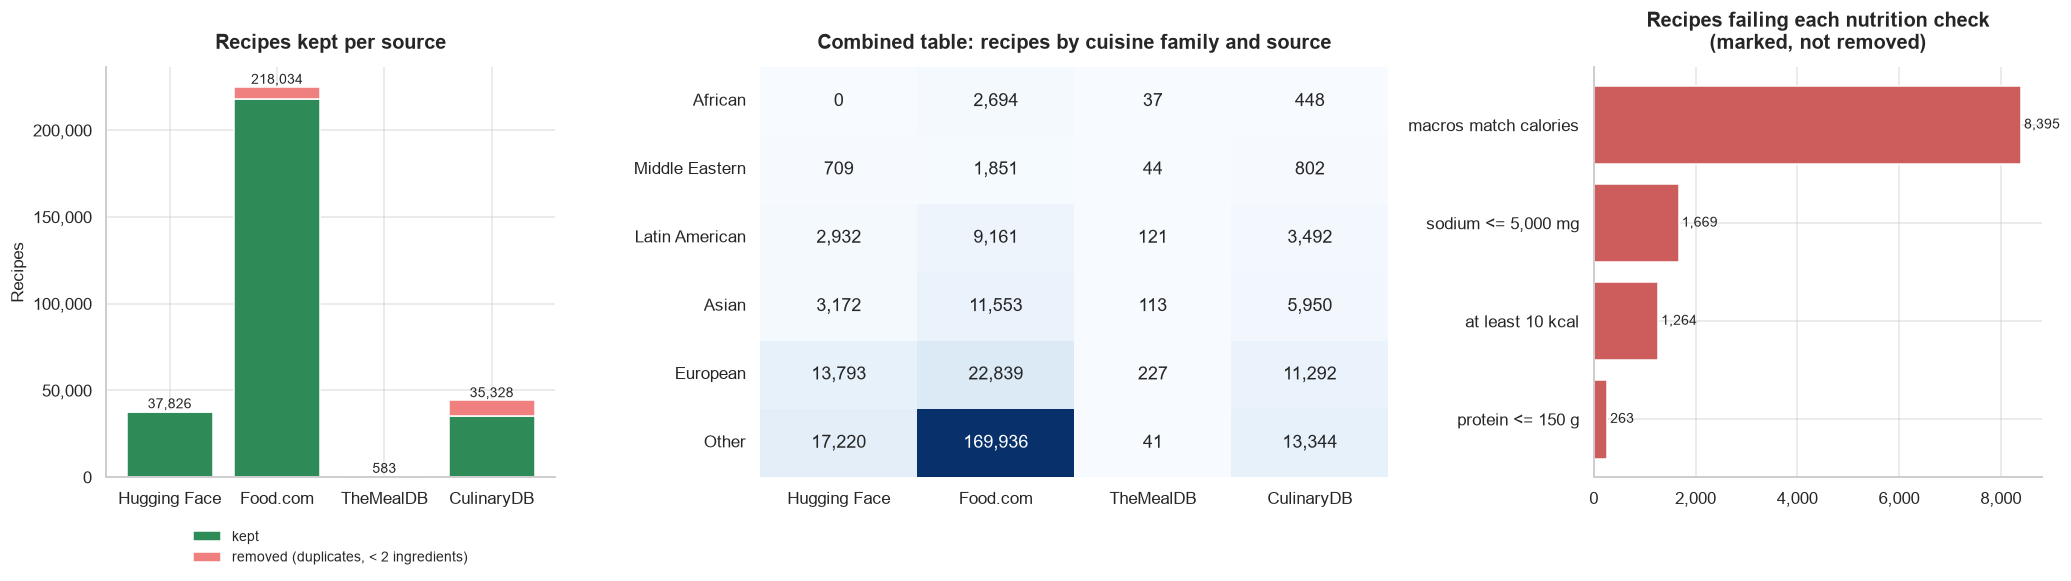

In [48]:
order = [s for s in SOURCE_PRIORITY if s in summary.index]
labels = [SOURCE_LABELS[s] for s in order]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), gridspec_kw={"width_ratios": [1, 1.4, 1]})
kept, removed = summary.loc[order, "kept"], summary.loc[order, "removed"]
axes[0].bar(labels, kept, color="seagreen", label="kept")
axes[0].bar(labels, removed, bottom=kept, color="lightcoral", label="removed (duplicates, < 2 ingredients)")
for x, (k, r) in enumerate(zip(kept, removed)):
    axes[0].text(x, k + r, f"{k:,}", ha="center", va="bottom", fontsize=9)
# Legend under the chart, so it never covers the bars
axes[0].legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=1)
axes[0].set_ylabel("Recipes")
thousands(axes[0])
axes[0].set_title("Recipes kept per source")

by_cuisine = (pd.crosstab(df_all["cuisine_family"], df_all["source"])
              .reindex(index=FAMILY_ORDER, columns=order).fillna(0))
by_cuisine.columns = labels
sns.heatmap(by_cuisine, annot=True, fmt=",.0f", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Combined table: recipes by cuisine family and source")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fails = (~checks[df_all["has_nutrition"]]).sum().sort_values()
axes[2].barh(fails.index, fails.values, color="indianred")
label_bars(axes[2])
thousands(axes[2], "x")
axes[2].set_title("Recipes failing each nutrition check\n(marked, not removed)")
show_figure(fig, "08_combining_sources")

---

## 5.7 Train / Validation / Test Split

We split the combined recipe table using a **stratified split by cuisine family** so that every family keeps the same share in each partition. The split ratio is approximately 70% train, 15% validation, 15% test.

Recipes with exactly the same ingredients but different titles are near-duplicates. If one landed in train and its twin in test, test scores would look better than they really are (data leakage). So we split **ingredient groups**, not single recipes: every recipe in a group goes to the same split. A check at the end confirms that no group appears in two splits.

The test split is not used anywhere in this notebook. It is kept for the final Week 7 evaluation.

#### 5.7.1 Split by ingredient group

In [49]:
from sklearn.model_selection import train_test_split

# Split ingredient groups (5.6), not single recipes, so near-duplicates
# never end up in different splits. Each group is stratified by the
# cuisine family of its first recipe.
groups = df_all.groupby("ingredient_group")["cuisine_family"].first()

# Stratifying needs enough groups in every family, or train_test_split
# raises an error. Families smaller than this are grouped together for
# the split only; their cuisine_family label is not changed.
MIN_PER_FAMILY = 10
family_counts = groups.value_counts()
small_families = [f for f in family_counts[family_counts < MIN_PER_FAMILY].index if f != "Other"]
strata = groups.where(~groups.isin(small_families), "Other")
if small_families:
    print(f"Families with fewer than {MIN_PER_FAMILY} groups, grouped with 'Other' for stratifying: {small_families}")


def safe_strata(labels):
    """Return the labels for stratifying, or None if any group has fewer than 2 rows."""
    return labels if labels.value_counts().min() >= 2 else None


# Split positions (0, 1, 2, ...) rather than the group keys themselves:
# this works with every pandas version, including pandas 3, whose
# default text type is not accepted by train_test_split as an index.
positions = np.arange(len(groups))
strata_by_pos = pd.Series(strata.to_numpy(dtype=object))

# First split: 70% train, 30% temp (which we will split again into val + test)
train_pos, temp_pos = train_test_split(
    positions, test_size=0.30, stratify=safe_strata(strata_by_pos), random_state=42)

# Second split: 50% of temp = 15% val, 50% of temp = 15% test
temp_strata = strata_by_pos.iloc[temp_pos].reset_index(drop=True)
if safe_strata(temp_strata) is None:
    print("Note: too few groups to stratify the val/test split; using a random split instead.")
val_rel, test_rel = train_test_split(
    np.arange(len(temp_pos)), test_size=0.50, stratify=safe_strata(temp_strata), random_state=42)

split_of_group = pd.Series("train", index=groups.index, dtype=object)
split_of_group.iloc[temp_pos[val_rel]] = "val"
split_of_group.iloc[temp_pos[test_rel]] = "test"
df_all["split"] = df_all["ingredient_group"].map(split_of_group)

train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
val_df   = df_all[df_all["split"] == "val"].reset_index(drop=True)
test_df  = df_all[df_all["split"] == "test"].reset_index(drop=True)

print("Dataset split summary:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s}: {len(df):>7,} rows ({len(df) / len(df_all) * 100:.1f}%)")

# Leakage check: no ingredient group may appear in two splits
shared = (set(train_df["ingredient_group"]) & set(test_df["ingredient_group"])) | \
         (set(train_df["ingredient_group"]) & set(val_df["ingredient_group"])) | \
         (set(val_df["ingredient_group"]) & set(test_df["ingredient_group"]))
print(f"\nIngredient groups shared between splits: {len(shared)} (must be 0)")

print("\nCuisine family distribution in each split (%):")
print(pd.DataFrame({name: df["cuisine_family"].value_counts(normalize=True).mul(100).round(1)
                    for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]}).to_string())

Dataset split summary:
  Train: 204,112 rows (70.0%)
  Val  :  43,885 rows (15.0%)
  Test :  43,774 rows (15.0%)



Ingredient groups shared between splits: 0 (must be 0)

Cuisine family distribution in each split (%):
                Train   Val  Test
cuisine_family                   
Other            68.7  68.8  68.7
European         16.5  16.5  16.5
Asian             7.1   7.1   7.1
Latin American    5.4   5.4   5.4
Middle Eastern    1.2   1.2   1.2
African           1.1   1.1   1.1


#### 5.7.2 Chart: the three splits

> **What it shows:** Each cuisine family should have the same share in train, validation and test. Matching bars mean the split is balanced.

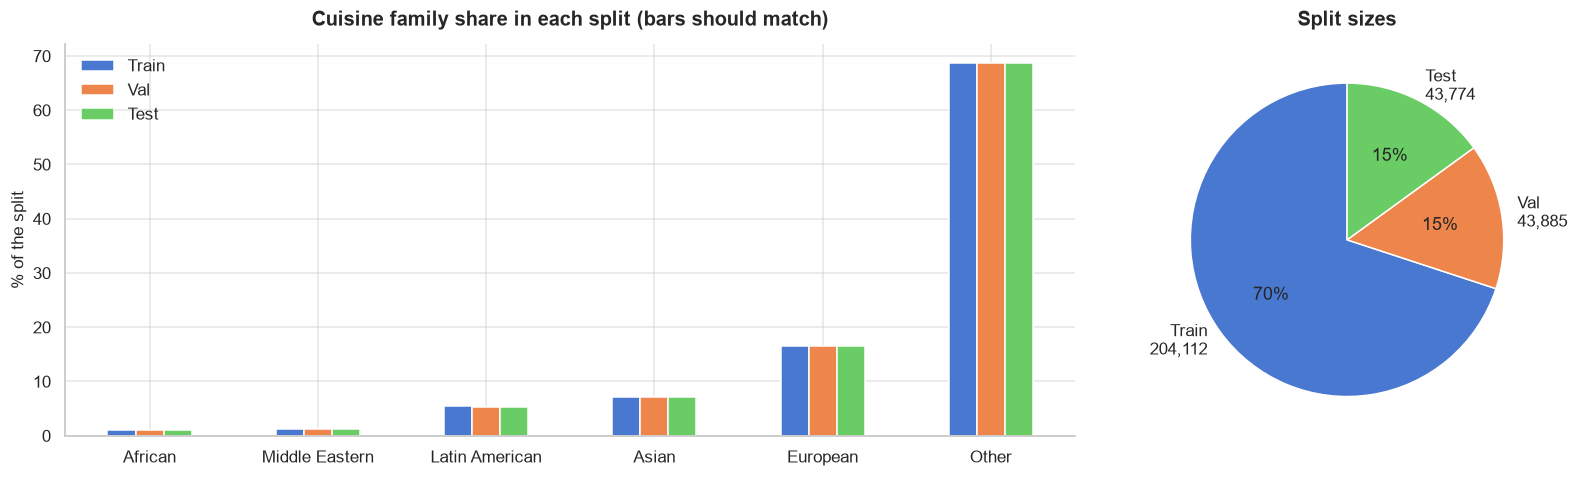

In [50]:
split_share = pd.DataFrame({name: df["cuisine_family"].value_counts(normalize=True).mul(100)
                            for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]}
                           ).reindex(FAMILY_ORDER).fillna(0)
sizes = pd.Series({"Train": len(train_df), "Val": len(val_df), "Test": len(test_df)})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
split_share.plot.bar(ax=axes[0], rot=0)
axes[0].set_ylabel("% of the split")
axes[0].set_xlabel("")
axes[0].set_title("Cuisine family share in each split (bars should match)")
axes[1].pie(sizes, labels=[f"{k}\n{v:,}" for k, v in sizes.items()], autopct="%1.0f%%",
            colors=sns.color_palette("muted", 3), startangle=90)
axes[1].set_title("Split sizes")
show_figure(fig, "09_splits")

---

## 5.8 Fill In Missing Nutrition

More than 46,000 recipes have no believable calorie data: all of CulinaryDB and TheMealDB (they publish no nutrition), plus the Food.com and Hugging Face recipes that failed the checks in 5.6. The Nutritionist Agent needs a calorie value for every recipe, so we estimate the missing ones from two kinds of evidence:

1. **Similar recipes with real nutrition.** A model learns calories per serving from the titles and ingredients of the training recipes whose listed nutrition passed every check.
2. **Official USDA data.** [USDA FoodData Central](https://fdc.nal.usda.gov/) publishes two free bulk downloads (no API key needed):
   - **FNDDS** (the survey food database): about 5,400 prepared dishes ("Rice, fried", "Vegetable curry") with calories per 100 g and a typical portion weight, which gives official calories per serving.
   - **SR Legacy**: about 7,800 single ingredients with nutrients per 100 g.

   Each recipe is matched to its closest USDA dishes by title, and each ingredient to a USDA ingredient. These matches become extra inputs for the model.

**What to expect:** CulinaryDB lists no ingredient amounts and no servings, so no method can compute exact calories for it. The estimates are labeled clearly instead:
- `nutrition_source` is `listed` (real data) or `estimated`;
- `calories_est_min` and `calories_est_max` give the likely range (8 in 10 real values fall inside it);
- `usda_dish` and `usda_dish_kcal` name the closest official USDA dish and its calories per serving, as a reference anyone can check.

The model is trained on the training split only, and its accuracy is measured on validation recipes whose real calories we know. The baseline recommender in 6.3 still ranks only recipes with listed nutrition.

#### 5.8.1 Download the USDA reference data

In [51]:
import zipfile

import requests

# -------------------------------------------------------
# USDA FoodData Central bulk downloads: official, free, no key.
# Saved once to data/raw/usda_fdc/ and reused unless
# REFRESH_DOWNLOADS is True (set in 2.3).
# -------------------------------------------------------
USDA_DIR = Path("data/raw/usda_fdc")
USDA_DOWNLOADS = {
    # name      : (download URL, top-level key in the JSON file)
    "fndds"     : ("https://fdc.nal.usda.gov/fdc-datasets/FoodData_Central_survey_food_json_2024-10-31.zip", "SurveyFoods"),
    "sr_legacy" : ("https://fdc.nal.usda.gov/fdc-datasets/FoodData_Central_sr_legacy_food_json_2018-04.zip", "SRLegacyFoods"),
}
# USDA nutrient name -> our column (values are per 100 g)
USDA_NUTRIENTS = {"Energy": "kcal_100g", "Protein": "protein_100g", "Total lipid (fat)": "fat_100g",
                  "Carbohydrate, by difference": "carbs_100g", "Sodium, Na": "sodium_mg_100g"}


def download_usda(name):
    """Return the local zip for one USDA download, downloading it if needed."""
    url, _ = USDA_DOWNLOADS[name]
    target = USDA_DIR / url.rsplit("/", 1)[-1]
    if target.exists() and not REFRESH_DOWNLOADS:
        return target
    USDA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {target.name} from USDA ...")
    response = requests.get(url, timeout=300)
    response.raise_for_status()   # this URL has no key in it, so the error is safe to show
    # Write under a temporary name first, so an interrupted download is never mistaken for a finished one
    partial = target.with_suffix(".part")
    partial.write_bytes(response.content)
    partial.replace(target)
    return target


def usda_table(name):
    """Read one USDA download into a table: one row per food, nutrients per 100 g."""
    _, key = USDA_DOWNLOADS[name]
    with zipfile.ZipFile(download_usda(name)) as archive:
        json_name = next(n for n in archive.namelist() if n.endswith(".json"))
        foods = json.loads(archive.read(json_name))[key]
    rows = []
    for food in foods:
        row = {"fdc_id": food["fdcId"], "description": food["description"]}
        for item in food.get("foodNutrients", []):
            nutrient = item.get("nutrient", {})
            column = USDA_NUTRIENTS.get(nutrient.get("name"))
            # Energy is listed in both kcal and kJ: keep kcal only
            if column and (column != "kcal_100g" or str(nutrient.get("unitName", "")).lower() == "kcal"):
                row[column] = item.get("amount")
        # FNDDS gives a typical portion for when the amount eaten is unknown
        row["serving_g"] = next((p.get("gramWeight") for p in food.get("foodPortions", [])
                                 if p.get("portionDescription") == "Quantity not specified"), None)
        rows.append(row)
    return pd.DataFrame(rows).dropna(subset=["kcal_100g"]).reset_index(drop=True)


usda_dishes = usda_table("fndds").dropna(subset=["serving_g"]).reset_index(drop=True)
usda_dishes["kcal_serving"] = usda_dishes["kcal_100g"] * usda_dishes["serving_g"] / 100
usda_ingredients = usda_table("sr_legacy").drop(columns="serving_g")

print(f"USDA FNDDS dishes    : {len(usda_dishes):,} (each with a typical portion weight)")
print(f"USDA SR Legacy foods : {len(usda_ingredients):,}")
print("\nExample dishes:")
examples = usda_dishes[usda_dishes["description"].isin(
    ["Rice, fried, NFS", "Vegetable curry", "Bread, paratha", "Lasagna with meat", "Hummus, plain"])]
print(examples[["description", "serving_g", "kcal_100g", "kcal_serving"]]
      .rename(columns={"serving_g": "typical serving (g)", "kcal_100g": "kcal per 100 g",
                       "kcal_serving": "kcal per serving"})
      .round(0).to_string(index=False))

USDA FNDDS dishes    : 5,362 (each with a typical portion weight)
USDA SR Legacy foods : 7,793

Example dishes:
      description  typical serving (g)  kcal per 100 g  kcal per serving
    Hummus, plain                 60.0           243.0             146.0
   Bread, paratha                 70.0           326.0             228.0
Lasagna with meat                250.0           139.0             348.0
 Rice, fried, NFS                198.0           174.0             345.0
  Vegetable curry                240.0            86.0             206.0


#### 5.8.2 Match recipes to USDA dishes and ingredients

- **Dishes:** each recipe title is compared with every USDA dish description. The title's main word (usually its last word: "coconut cabbage **curry**") must appear in the dish description, which stops matches such as "spice vegetable fried rice" -> "spice cake". We keep the 5 best matches.
- **Ingredients:** each ingredient name is matched to a USDA ingredient, preferring raw, plain entries. Common ingredients that automatic matching gets wrong (for example "flour" -> potato flour, "milk" -> dried buttermilk) use a hand-checked USDA entry instead, like the sample in 2.4.1.2.

The matched ingredients are saved as `data/processed/usda_ingredient_nutrition.csv`, a per-100 g nutrition table the Nutritionist Agent can use directly.

In [52]:
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer


# singular() comes from the ingredient normalizing rules in 5.4.4
def words(text):
    return [singular(w) for w in re.findall(r"[a-z]+", str(text).lower())]


def norm_text(text):
    return " ".join(words(text))


# Title words that say nothing about the dish itself
TITLE_FILLER = {"and", "with", "the", "for", "easy", "best", "homemade", "style", "recipe", "quick",
                "simple", "mom", "grandma", "old", "fashioned", "classic", "ii", "iii", "oamc"}


def head_word(title):
    """The last meaningful word of a title, usually the dish: 'coconut cabbage curry' -> 'curry'."""
    meaningful = [w for w in words(title) if len(w) > 2 and w not in TITLE_FILLER]
    return meaningful[-1] if meaningful else ""


# ---------------------------------------------------------------
# 1. Recipe title -> closest USDA dishes
# ---------------------------------------------------------------
DISH_TOP_K = 5         # matches kept per recipe
DISH_MIN_SCORE = 0.25  # weaker matches are ignored
CANDIDATES = 50        # only the most similar USDA entries are scored in detail (much faster)


def top_candidates(similarity, row):
    """Positions and similarities of the CANDIDATES most similar USDA entries for one row."""
    start, end = similarity.indptr[row], similarity.indptr[row + 1]
    positions, values = similarity.indices[start:end], similarity.data[start:end]
    if len(values) > CANDIDATES:
        keep = np.argpartition(-values, CANDIDATES)[:CANDIDATES]
        positions, values = positions[keep], values[keep]
    return positions, values


def match_dishes(titles, dishes):
    """Return (scores, positions) of the best USDA dishes for each title, shape (n, DISH_TOP_K).

    Score = text similarity, +0.35 if the title's main word is in the first
    part of the USDA description (its food group, as in 'Rice, fried'),
    +0.1 if it appears later, -0.2 if it is missing. A score of 0 means no match.
    """
    vectorizer = TfidfVectorizer(token_pattern=r"[a-z]{3,}", sublinear_tf=True, ngram_range=(1, 2))
    dish_matrix = vectorizer.fit_transform(dishes["description"].map(norm_text))
    similarity = (vectorizer.transform([norm_text(t) for t in titles]) @ dish_matrix.T).tocsr()
    first_part = [set(words(d.split(",")[0])) for d in dishes["description"]]
    anywhere = [set(words(d)) for d in dishes["description"]]

    scores = np.zeros((len(titles), DISH_TOP_K))
    positions = np.zeros((len(titles), DISH_TOP_K), dtype=int)
    for row, title in enumerate(titles):
        candidates, text_score = top_candidates(similarity, row)
        if len(candidates) == 0:
            continue
        head = head_word(title)
        score = text_score + np.array(
            [0.35 if head in first_part[j] else 0.1 if head in anywhere[j] else -0.2 for j in candidates])
        best = np.argsort(-score)[:DISH_TOP_K]
        best = best[score[best] > DISH_MIN_SCORE]
        scores[row, :len(best)] = score[best]
        positions[row, :len(best)] = candidates[best]
    return scores, positions


dish_scores, dish_positions = match_dishes(df_all["recipe_name"].tolist(), usda_dishes)
dish_matched = dish_scores[:, 0] > 0
dish_weights = dish_scores + 1e-9


def dish_average(values):
    """Similarity-weighted average of a USDA dish column over each recipe's matches."""
    picked = values[dish_positions]
    return np.where(dish_matched, (picked * dish_weights).sum(axis=1) / dish_weights.sum(axis=1), np.nan)


usda_features = pd.DataFrame({
    "dish_kcal"   : dish_average(usda_dishes["kcal_serving"].to_numpy()),
    "dish_density": dish_average(usda_dishes["kcal_100g"].to_numpy()),
    "dish_score"  : dish_scores[:, 0],
}, index=df_all.index)

# The single closest dish, kept in the data as a reference anyone can check
best_dish = dish_positions[:, 0]
df_all["usda_dish"] = np.where(dish_matched, usda_dishes["description"].to_numpy()[best_dish], None)
df_all["usda_dish_kcal"] = np.where(dish_matched, usda_dishes["kcal_serving"].to_numpy()[best_dish].round(0), np.nan)
print(f"Recipes matched to a USDA dish: {dish_matched.mean() * 100:.0f}%")

# ---------------------------------------------------------------
# 2. Ingredient name -> USDA ingredient
# ---------------------------------------------------------------
# Hand-checked matches for common ingredients that automatic matching gets wrong
FLOUR = "Wheat flour, white, all-purpose, enriched, bleached"
VEGETABLE_OIL = "Oil, soybean, salad or cooking"
BLACK_PEPPER = "Spices, pepper, black"
CAYENNE = "Spices, pepper, red or cayenne"
CHICKEN_BREAST = "Chicken, broiler or fryers, breast, skinless, boneless, meat only, raw"
CHICKEN_STOCK = "Soup, stock, chicken, home-prepared"
INGREDIENT_USDA = {
    "sugar": "Sugars, granulated", "powdered sugar": "Sugars, powdered", "confectioners' sugar": "Sugars, powdered",
    "flour": FLOUR, "olive oil": "Oil, olive, salad or cooking", "vegetable oil": VEGETABLE_OIL,
    "oil": VEGETABLE_OIL, "canola oil": VEGETABLE_OIL,
    "pepper": BLACK_PEPPER, "black pepper": BLACK_PEPPER, "ground pepper": BLACK_PEPPER,
    "milk": "Milk, whole, 3.25% milkfat, with added vitamin D",
    "tomato": "Tomatoes, red, ripe, raw, year round average",
    "green onion": "Onions, spring or scallions (includes tops and bulb), raw",
    "baking powder": "Leavening agents, baking powder, double-acting, sodium aluminum sulfate",
    "cinnamon": "Spices, cinnamon, ground", "ground cinnamon": "Spices, cinnamon, ground",
    "vanilla": "Vanilla extract", "vanilla extract": "Vanilla extract",
    "sour cream": "Cream, sour, cultured", "garlic powder": "Spices, garlic powder",
    "soy sauce": "Soy sauce made from soy and wheat (shoyu)",
    "cheddar cheese": "Cheese, cheddar (Includes foods for USDA's Food Distribution Program)",
    "parmesan cheese": "Cheese, parmesan, grated", "cream cheese": "Cheese, cream",
    "mozzarella cheese": "Cheese, mozzarella, whole milk",
    "mayonnaise": "Salad dressing, mayonnaise, regular", "potato": "Potatoes, flesh and skin, raw",
    "butter": "Butter, salted", "egg": "Egg, whole, raw, fresh",
    "heavy cream": "Cream, fluid, heavy whipping", "whipping cream": "Cream, fluid, heavy whipping",
    "chicken broth": CHICKEN_STOCK, "chicken stock": CHICKEN_STOCK,
    "chicken breast": CHICKEN_BREAST, "boneless skinless chicken breast": CHICKEN_BREAST,
    "ground beef": "Beef, ground, 80% lean meat / 20% fat, raw",
    "cumin": "Spices, cumin seed", "ground cumin": "Spices, cumin seed", "paprika": "Spices, paprika",
    "chili powder": "Spices, chili powder", "oregano": "Spices, oregano, dried",
    "dried oregano": "Spices, oregano, dried", "cayenne pepper": CAYENNE, "cayenne": CAYENNE,
    "nutmeg": "Spices, nutmeg, ground", "ground nutmeg": "Spices, nutmeg, ground",
    "worcestershire sauce": "Sauce, worcestershire", "lime juice": "Lime juice, raw",
    "dijon mustard": "Mustard, prepared, yellow",
    "red bell pepper": "Peppers, sweet, red, raw", "green bell pepper": "Peppers, sweet, green, raw",
    "green pepper": "Peppers, sweet, green, raw",
    "walnut": "Nuts, walnuts, english", "pecan": "Nuts, pecans", "almond": "Nuts, almonds",
    "bacon": "Pork, cured, bacon, unprepared", "cornstarch": "Cornstarch",
    "zucchini": "Squash, summer, zucchini, includes skin, raw", "banana": "Bananas, raw", "spinach": "Spinach, raw",
    "coconut milk": "Nuts, coconut milk, canned (liquid expressed from grated meat and water)",
    "rice": "Rice, white, long-grain, regular, raw, enriched",
}
missing_entries = sorted(set(INGREDIENT_USDA.values()) - set(usda_ingredients["description"]))
if missing_entries:
    raise ValueError(f"These hand-checked USDA entries are not in the download: {missing_entries}")


def match_ingredients(names, foods):
    """Return {ingredient: (row in foods, 'hand-checked' or 'automatic')} for the names that match."""
    vectorizer = TfidfVectorizer(token_pattern=r"[a-z]{3,}")
    food_matrix = vectorizer.fit_transform(foods["description"].map(norm_text))
    similarity = (vectorizer.transform([norm_text(n) for n in names]) @ food_matrix.T).tocsr()
    first_part = [norm_text(d.split(",")[0]) for d in foods["description"]]
    is_raw = foods["description"].str.contains("raw", case=False).to_numpy()
    n_details = foods["description"].str.count(",").to_numpy()   # fewer details = more generic food
    row_of = {d: i for i, d in enumerate(foods["description"])}

    matches = {}
    for row, name in enumerate(names):
        if name in INGREDIENT_USDA:
            matches[name] = (row_of[INGREDIENT_USDA[name]], "hand-checked")
            continue
        candidates, text_score = top_candidates(similarity, row)
        if len(candidates) == 0:
            continue
        target = norm_text(name)
        last = target.split()[-1:]
        bonus = np.array([0.5 if first_part[j] == target else 0.25 if first_part[j].split()[-1:] == last else 0.0
                          for j in candidates])
        score = text_score + bonus + 0.1 * is_raw[candidates] - 0.02 * n_details[candidates]
        best = int(np.argmax(score))
        if score[best] > 0.45:
            matches[name] = (candidates[best], "automatic")
    return matches


ingredient_counts = Counter(i for ingredients in df_all["ingredient_list"] for i in set(ingredients))
ingredient_matches = match_ingredients(sorted(ingredient_counts), usda_ingredients)
matched_names = list(ingredient_matches)
matched_rows = [ingredient_matches[name][0] for name in matched_names]
ingredient_nutrition = (
    usda_ingredients.iloc[matched_rows][["fdc_id", "description", *USDA_NUTRIENTS.values()]]
    .rename(columns={"description": "usda_description"})
    .assign(ingredient=matched_names,
            recipes=[ingredient_counts[name] for name in matched_names],
            match=[ingredient_matches[name][1] for name in matched_names])
    .loc[:, ["ingredient", "recipes", "match", "fdc_id", "usda_description", *USDA_NUTRIENTS.values()]]
    .sort_values("recipes", ascending=False)
    .reset_index(drop=True)
)

INGREDIENT_TABLE_FILE = Path("data/processed/usda_ingredient_nutrition.csv")
ingredient_nutrition.to_csv(INGREDIENT_TABLE_FILE, index=False)

uses_matched = ingredient_nutrition["recipes"].sum() / sum(ingredient_counts.values())
print(f"Ingredient names matched to USDA: {len(ingredient_nutrition):,} of {len(ingredient_counts):,} "
      f"({uses_matched * 100:.0f}% of all ingredient uses)")
print(f"Saved to {INGREDIENT_TABLE_FILE.as_posix()}\n")
print(ingredient_nutrition.head(12)[["ingredient", "usda_description", "kcal_100g", "match"]].to_string(index=False))

# ---------------------------------------------------------------
# 3. Recipe-level energy features from the matched ingredients.
#    Amounts are unknown, so these describe how energy-dense the
#    ingredients are (oil, butter, sugar, nuts), not the total.
# ---------------------------------------------------------------
kcal_per_100g = dict(zip(ingredient_nutrition["ingredient"], ingredient_nutrition["kcal_100g"]))

# One row per (recipe, ingredient), then summarize per recipe
ingredient_kcal = df_all["ingredient_list"].explode().map(kcal_per_100g).astype(float).dropna()
by_recipe = ingredient_kcal.groupby(level=0)
energy = pd.DataFrame({
    "ing_kcal_mean"     : by_recipe.mean(),
    "ing_kcal_max"      : by_recipe.max(),
    "ing_share_over_300": (ingredient_kcal > 300).groupby(level=0).mean(),
    "ing_share_over_500": (ingredient_kcal > 500).groupby(level=0).mean(),
}).reindex(df_all.index)   # recipes with no matched ingredient get missing values
usda_features = pd.concat([usda_features, energy], axis=1)

Recipes matched to a USDA dish: 89%


Ingredient names matched to USDA: 39,974 of 46,350 (97% of all ingredient uses)
Saved to data/processed/usda_ingredient_nutrition.csv

  ingredient                                    usda_description  kcal_100g        match
        salt                                         Salt, table        0.0    automatic
      butter                                      Butter, salted      717.0 hand-checked
      garlic                                         Garlic, raw      149.0    automatic
       sugar                                  Sugars, granulated      387.0 hand-checked
       onion                                         Onions, raw       40.0    automatic
         egg                              Egg, whole, raw, fresh      143.0 hand-checked
   olive oil                        Oil, olive, salad or cooking      884.0 hand-checked
       flour Wheat flour, white, all-purpose, enriched, bleached      364.0 hand-checked
      pepper                               Spices, pepper, black

#### 5.8.3 Train the estimator and measure its accuracy

Two models, both trained on **training recipes with listed, believable nutrition**:

1. A **ridge regression** on the words in the title and the ingredient list ("cookies" and "butter" mean more calories, "salad" and "broth" fewer).
2. A **gradient-boosted model** that combines the ridge prediction with the USDA evidence from 5.8.2 (closest dishes' calories per serving, energy density of the ingredients) and the number of ingredients.

Protein, fat, carbs and sodium get their own ridge models; protein, fat and carbs are then scaled so they add up to the estimated calories (4, 9 and 4 kcal per gram).

**Accuracy check:** the models predict validation recipes whose real calories we know. Half of them set the likely range (the 10th to 90th percentile of the errors), and the other half measure how good the estimates are, so the reported numbers are honest.

In [53]:
from scipy import sparse  # installed with scikit-learn
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict

# Training rows: training split with listed, believable nutrition (no validation or test data)
is_fit = (df_all["split"] == "train") & df_all["nutrition_plausible"]
is_check = (df_all["split"] == "val") & df_all["nutrition_plausible"]
fit_rows, check_rows = df_all[is_fit], df_all[is_check]


def unique_ingredients(ingredients):
    return list(dict.fromkeys(ingredients))


# --- Text features: ingredient names and title words ---
ingredient_vectorizer = TfidfVectorizer(analyzer=unique_ingredients, min_df=2, sublinear_tf=True)
title_vectorizer = TfidfVectorizer(token_pattern=r"[a-z]{3,}", ngram_range=(1, 2), min_df=3)


def text_matrix(rows, fit=False):
    ingredients, titles = rows["ingredient_list"], rows["recipe_name"].str.lower().tolist()
    if fit:
        return sparse.hstack([ingredient_vectorizer.fit_transform(ingredients),
                              title_vectorizer.fit_transform(titles)]).tocsr()
    return sparse.hstack([ingredient_vectorizer.transform(ingredients),
                          title_vectorizer.transform(titles)]).tocsr()


def combined_inputs(rows, text_prediction):
    """Ridge prediction + USDA evidence + number of ingredients (missing USDA values are allowed)."""
    return np.column_stack([text_prediction, usda_features.loc[rows.index].to_numpy(),
                            rows["complexity"].to_numpy()])


X_fit, X_check = text_matrix(fit_rows, fit=True), text_matrix(check_rows)
y_fit = np.log(fit_rows["calories_per_serving"].to_numpy())   # log: errors in proportion, not in kcal

# 1. Ridge on text. Its training predictions come from 5-fold cross-validation,
#    so the second model learns from honest (unseen) predictions.
text_model = Ridge(alpha=3.0)
text_fit_prediction = cross_val_predict(text_model, X_fit, y_fit, cv=5)
text_model.fit(X_fit, y_fit)

# 2. Gradient boosting on the ridge prediction + USDA evidence
calorie_model = HistGradientBoostingRegressor(loss="absolute_error", max_iter=500, learning_rate=0.05,
                                              random_state=42)
calorie_model.fit(combined_inputs(fit_rows, text_fit_prediction), y_fit)


def estimate_calories(rows, X):
    return np.exp(calorie_model.predict(combined_inputs(rows, text_model.predict(X))))


# --- Macros: one ridge model each, on the same text features ---
MACROS = ["protein_g", "fat_g", "carbs_g", "sodium_mg"]
macro_models = {}
for column in MACROS:
    known = fit_rows[column].notna().to_numpy()
    macro_models[column] = Ridge(alpha=3.0).fit(X_fit[known], np.log1p(fit_rows[column].to_numpy()[known]))


def estimate_macros(X, kcal):
    """Macro estimates; protein, fat and carbs are scaled to add up to the estimated calories."""
    values = {column: np.expm1(model.predict(X)).clip(min=0) for column, model in macro_models.items()}
    macro_kcal = 4 * values["protein_g"] + 9 * values["fat_g"] + 4 * values["carbs_g"]
    scale = np.divide(kcal, macro_kcal, out=np.ones_like(kcal), where=macro_kcal > 0)
    for column in ["protein_g", "fat_g", "carbs_g"]:
        values[column] = values[column] * scale
    return values


# ---------------------------------------------------------------
# Accuracy on validation recipes with real (listed) calories
# ---------------------------------------------------------------
real_kcal = check_rows["calories_per_serving"].to_numpy()
estimated_kcal = estimate_calories(check_rows, X_check)
calibrate = np.random.default_rng(42).random(len(check_rows)) < 0.5   # half sets the range, half measures
measure = ~calibrate

# Likely range: the 10th to 90th percentile of the errors (in proportion), from the calibration half
RANGE_QUANTILES = (0.10, 0.90)
log_errors = np.log(real_kcal) - np.log(estimated_kcal)
range_low, range_high = np.quantile(log_errors[calibrate], RANGE_QUANTILES)
in_range = ((real_kcal >= estimated_kcal * np.exp(range_low)) &
            (real_kcal <= estimated_kcal * np.exp(range_high)))

dish_only = usda_features.loc[check_rows.index, "dish_kcal"].fillna(np.median(np.exp(y_fit))).to_numpy()
METHODS = {
    "Guess the median"                : np.full(len(real_kcal), np.median(np.exp(y_fit))),
    "Closest USDA dishes only"        : dish_only,
    "Similar recipes (title + ingredients)": np.exp(text_model.predict(X_check)),
    "Similar recipes + USDA (used)"   : estimated_kcal,
}


def accuracy(estimate):
    real = real_kcal[measure]
    error = np.abs(estimate[measure] - real)
    return {"average error (kcal)": error.mean(), "typical error (kcal)": np.median(error),
            "within 20% (%)": (error <= 0.2 * real).mean() * 100,
            "within 30% (%)": (error <= 0.3 * real).mean() * 100}


estimate_accuracy = pd.DataFrame({name: accuracy(est) for name, est in METHODS.items()}).T.round(1)
print(f"Accuracy on {measure.sum():,} validation recipes with real calories (not used for training):\n")
print(estimate_accuracy.to_string())
print(f"\nLikely range: estimate x {np.exp(range_low):.2f} to estimate x {np.exp(range_high):.2f}")
print(f"Real value inside the range: {in_range[measure].mean() * 100:.0f}% (target 80%)")

macro_estimates = estimate_macros(X_check, estimated_kcal)
print("\nMacro estimates, typical error on the same recipes:")
for column in MACROS:
    real = check_rows[column].to_numpy()
    ok = measure & ~np.isnan(real)
    print(f"  {column:10s}: {np.median(np.abs(macro_estimates[column][ok] - real[ok])):6.1f} "
          f"(real median {np.median(real[ok]):.1f})")

Accuracy on 18,541 validation recipes with real calories (not used for training):

                                       average error (kcal)  typical error (kcal)  within 20% (%)  within 30% (%)
Guess the median                                      229.6                 152.1            21.1            32.1
Closest USDA dishes only                              256.1                 154.4            17.0            25.8
Similar recipes (title + ingredients)                 188.7                 105.7            28.8            42.0
Similar recipes + USDA (used)                         186.2                 104.3            29.2            42.8

Likely range: estimate x 0.47 to estimate x 2.11
Real value inside the range: 79% (target 80%)

Macro estimates, typical error on the same recipes:
  protein_g :    3.7 (real median 9.0)
  fat_g     :    5.5 (real median 13.7)
  carbs_g   :   10.5 (real median 27.0)
  sodium_mg :  163.2 (real median 336.0)


#### 5.8.4 Fill the gaps

Every recipe without listed, believable nutrition gets the estimates. Listed values are never changed. For the Food.com and Hugging Face recipes whose listed values failed the checks in 5.6, the estimate replaces the unbelievable value (the original stays in the raw files).

In [54]:
to_fill = df_all[~df_all["nutrition_plausible"]]
X_fill = text_matrix(to_fill)
kcal_limits = (NUTRITION_LIMITS["min_kcal"], MAX_KCAL_PER_SERVING)

fill_kcal = estimate_calories(to_fill, X_fill).clip(*kcal_limits)
fill_macros = estimate_macros(X_fill, fill_kcal)

df_all["nutrition_source"] = "listed"
df_all.loc[to_fill.index, "nutrition_source"] = "estimated"
df_all.loc[to_fill.index, "calories_per_serving"] = fill_kcal.round(1)
for column, values in fill_macros.items():
    df_all.loc[to_fill.index, column] = values.round(1)
df_all["calories_est_min"] = np.nan
df_all["calories_est_max"] = np.nan
df_all.loc[to_fill.index, "calories_est_min"] = (fill_kcal * np.exp(range_low)).clip(*kcal_limits).round(0)
df_all.loc[to_fill.index, "calories_est_max"] = (fill_kcal * np.exp(range_high)).clip(*kcal_limits).round(0)

# The splits are separate tables: rebuild them so they include the filled values
train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
val_df   = df_all[df_all["split"] == "val"].reset_index(drop=True)
test_df  = df_all[df_all["split"] == "test"].reset_index(drop=True)

print("Nutrition source by recipe source:")
print(pd.crosstab(df_all["source"].map(SOURCE_LABELS), df_all["nutrition_source"], margins=True,
                  margins_name="total").to_string())
print(f"\nEvery recipe now has calories: {df_all['calories_per_serving'].notna().all()}")

print("\nExamples of filled recipes (kcal per serving):")
examples = df_all[df_all["nutrition_source"] == "estimated"].groupby("source").sample(n=2, random_state=42)
print(examples[["recipe_name", "source", "calories_per_serving", "calories_est_min", "calories_est_max",
                "usda_dish", "usda_dish_kcal"]]
      .rename(columns={"calories_per_serving": "estimate", "calories_est_min": "min",
                       "calories_est_max": "max", "usda_dish_kcal": "USDA kcal"})
      .to_string(index=False, max_colwidth=34))

Nutrition source by recipe source:
nutrition_source  estimated  listed   total
source                                     
CulinaryDB            35328       0   35328
Food.com               8915  209119  218034
Hugging Face           1482   36344   37826
TheMealDB               583       0     583
total                 46308  245463  291771

Every recipe now has calories: True

Examples of filled recipes (kcal per serving):
                       recipe_name      source  estimate   min   max                          usda_dish  USDA kcal
               Summertime Horchata  culinarydb     411.5 193.0 870.0           Horchata, made with milk      226.0
   Tropical Grilled Chicken Breast  culinarydb     325.8 153.0 689.0 Chicken breast, grilled with sa...      354.0
           limoncello cosmopolitan     foodcom     118.6  56.0 251.0                                NaN        NaN
          chicken in red wine oamc     foodcom     341.6 160.0 722.0                          Wine, red      153

#### 5.8.5 Chart: how good are the estimates?

> **What it shows:** Left: estimated against real calories for validation recipes (points on the dashed line are exact). Middle: the average error of each method; USDA evidence and similar recipes together do best. Right: how often the real value falls inside the likely range, for each cuisine family (the target is 80%).

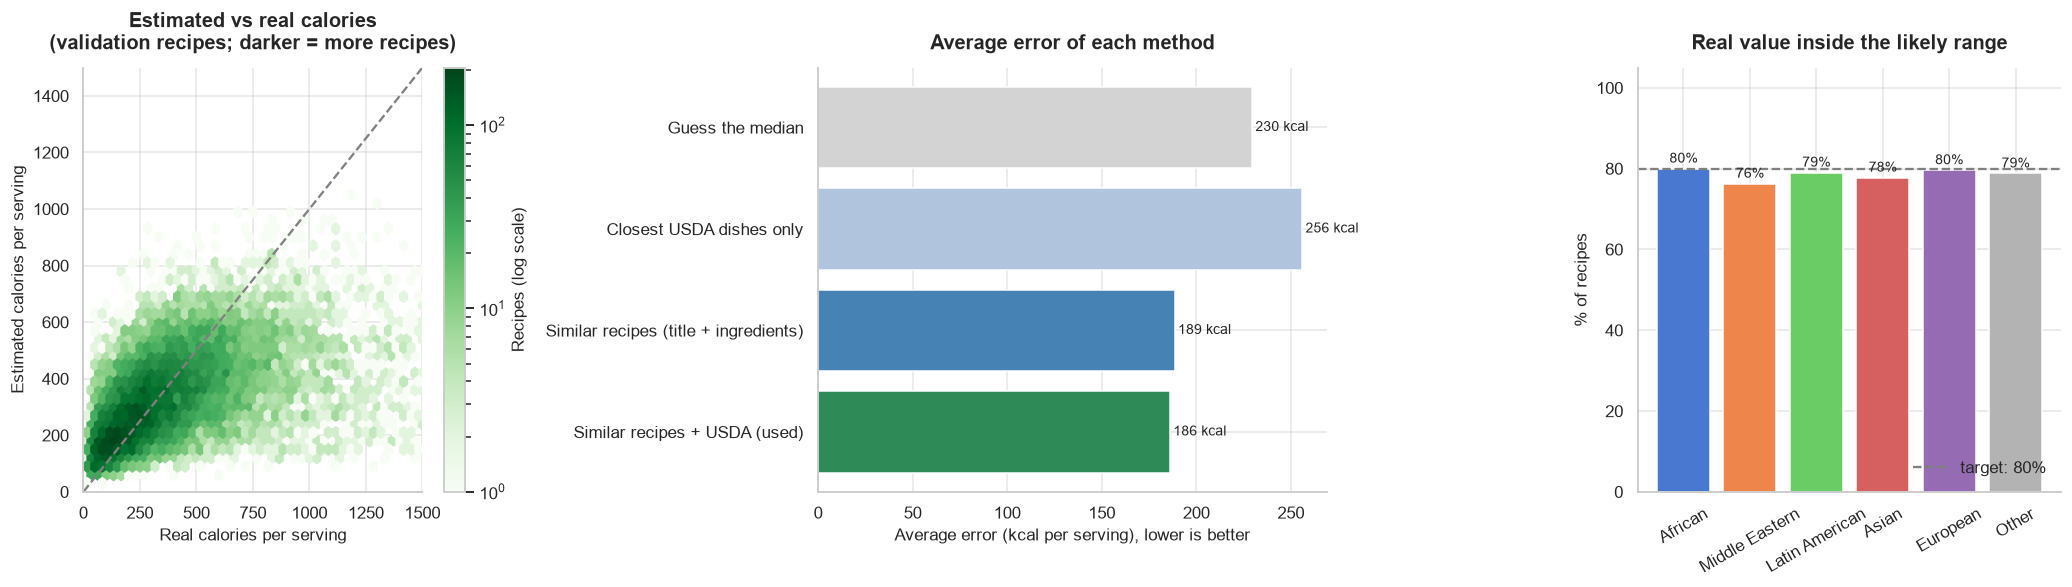

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), gridspec_kw={"width_ratios": [1, 1.2, 1]})

# Left: estimated vs real calories (the half of the validation recipes used for measuring)
limit = 1500
hexes = axes[0].hexbin(real_kcal[measure], estimated_kcal[measure], gridsize=45, cmap="Greens",
                       bins="log", mincnt=1, extent=(0, limit, 0, limit))
axes[0].plot([0, limit], [0, limit], ls="--", color="gray")
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("Real calories per serving")
axes[0].set_ylabel("Estimated calories per serving")
axes[0].set_title("Estimated vs real calories\n(validation recipes; darker = more recipes)")
fig.colorbar(hexes, ax=axes[0], label="Recipes (log scale)")

# Middle: average error of each method
errors = estimate_accuracy["average error (kcal)"]
colors = ["lightgray", "lightsteelblue", "steelblue", "seagreen"]
axes[1].barh(errors.index, errors.values, color=colors)
label_bars(axes[1], "{:,.0f} kcal")
axes[1].invert_yaxis()
axes[1].set_xlabel("Average error (kcal per serving), lower is better")
axes[1].set_title("Average error of each method")

# Right: real value inside the likely range, by cuisine family
check_family = check_rows["cuisine_family"].to_numpy()
coverage = pd.Series({f: in_range[measure & (check_family == f)].mean() * 100
                      for f in FAMILY_ORDER if (measure & (check_family == f)).any()})
axes[2].bar(coverage.index, coverage.values, color=[FAMILY_COLORS[f] for f in coverage.index])
axes[2].axhline(80, ls="--", color="gray", label="target: 80%")
label_bars(axes[2], "{:.0f}%")
axes[2].set_ylim(0, 105)
axes[2].legend(loc="lower right")
axes[2].set_ylabel("% of recipes")
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_title("Real value inside the likely range")

show_figure(fig, "15_nutrition_estimates")

#### 5.8.6 Chart and table: average and min-to-max calories

> **What it shows:** Left: how many recipes in each source have listed or estimated nutrition, so the gap that was filled is visible. Right: calories per serving for each cuisine family, listed and estimated side by side: the thin line runs from the minimum to the maximum, the thick bar covers the middle 50% of recipes, and the dot is the average. Estimates cluster nearer the middle than real values, because an estimate cannot know when a recipe is unusually light or heavy. Their averages are also lower: the model aims at the typical (median) recipe, and calorie data is skewed by a few very rich recipes, which pull the listed averages up.

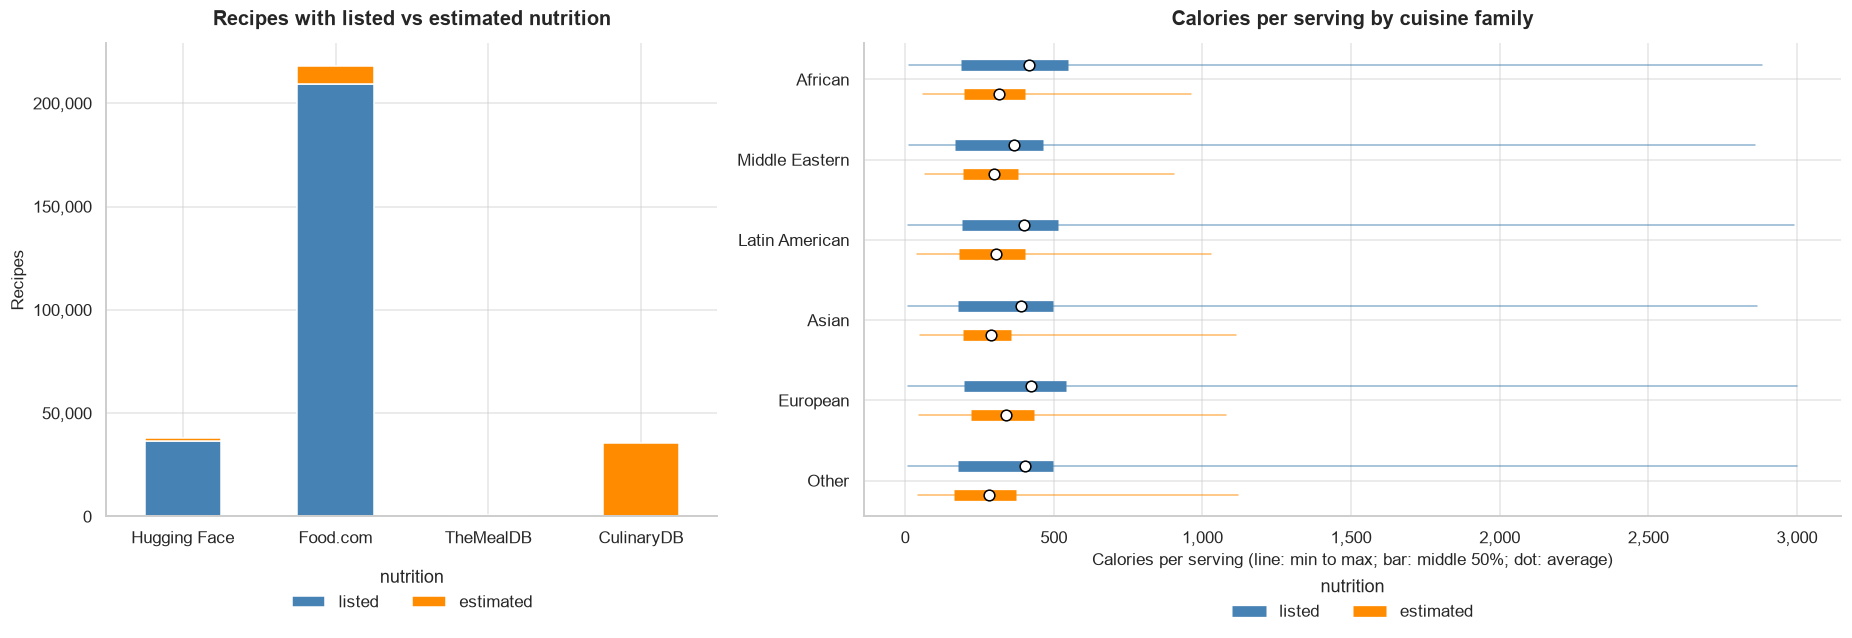

Calories per serving by cuisine family:
                                 recipes  average  minimum  maximum
cuisine_family nutrition_source                                    
African        estimated             625    317.0     60.0    961.0
               listed               2554    415.0     13.0   2884.0
Middle Eastern estimated             913    299.0     67.0    904.0
               listed               2493    365.0     13.0   2860.0
Latin American estimated            4125    304.0     40.0   1027.0
               listed              11581    400.0     10.0   2991.0
Asian          estimated            6624    290.0     51.0   1114.0
               listed              14164    388.0     10.0   2866.0
European       estimated           12456    339.0     47.0   1078.0
               listed              35695    422.0     11.0   3000.0
Other          estimated           21565    283.0     43.0   1120.0
               listed             178976    404.0     10.0   2999.0

Calorie

In [56]:
NUTRITION_SOURCES = {"listed": "steelblue", "estimated": "darkorange"}

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1, 1.6]})

# Left: listed vs estimated recipes per source
by_source = (pd.crosstab(df_all["source"], df_all["nutrition_source"])
             .reindex(index=[s for s in SOURCE_PRIORITY if s in set(df_all["source"])],
                      columns=list(NUTRITION_SOURCES), fill_value=0))
by_source.index = by_source.index.map(SOURCE_LABELS)
by_source.plot.bar(stacked=True, ax=axes[0], rot=0, color=list(NUTRITION_SOURCES.values()))
axes[0].set_xlabel("")
axes[0].set_ylabel("Recipes")
thousands(axes[0])
axes[0].legend(title="nutrition", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
axes[0].set_title("Recipes with listed vs estimated nutrition")

# Right: min to max, middle 50% and average calories by cuisine family
families = [f for f in FAMILY_ORDER if (df_all["cuisine_family"] == f).any()]
for row, family in enumerate(families):
    for offset, (source, color) in zip((-0.18, 0.18), NUTRITION_SOURCES.items()):
        kcal = df_all.loc[(df_all["cuisine_family"] == family) & (df_all["nutrition_source"] == source),
                          "calories_per_serving"]
        if kcal.empty:
            continue
        y = row + offset
        axes[1].plot([kcal.min(), kcal.max()], [y, y], color=color, lw=1, alpha=0.6)
        axes[1].plot([kcal.quantile(0.25), kcal.quantile(0.75)], [y, y], color=color, lw=7, solid_capstyle="butt",
                     label=source if row == 0 else None)
        axes[1].plot(kcal.mean(), y, "o", color="white", markeredgecolor="black", markersize=7)
axes[1].set_yticks(range(len(families)))
axes[1].set_yticklabels(families)
axes[1].invert_yaxis()
axes[1].set_xlabel("Calories per serving (line: min to max; bar: middle 50%; dot: average)")
axes[1].legend(title="nutrition", loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
thousands(axes[1], "x")
axes[1].set_title("Calories per serving by cuisine family")

show_figure(fig, "16_calories_by_cuisine")

# The same numbers as a table
summary_kcal = (df_all.groupby(["cuisine_family", "nutrition_source"])["calories_per_serving"]
                .agg(recipes="count", average="mean", minimum="min", maximum="max")
                .reindex(families, level=0).round(0))
print("Calories per serving by cuisine family:")
print(summary_kcal.to_string())
print("\nCalories per serving by source:")
print(df_all.groupby(["source", "nutrition_source"])["calories_per_serving"]
      .agg(recipes="count", average="mean", minimum="min", maximum="max").round(0).to_string())

---

## 5.9 Data Validation

Before saving, automatic checks confirm that the data follows the rules the agents and models rely on: the right columns and types, only allowed values, believable ranges, consistent flags, and no recipe or ingredient group in two splits. If any check fails, the cell stops with a list of the problems, so bad data is never saved.

In [57]:
ALLOWED_FAMILIES = {"Asian", "European", "Latin American", "African", "Middle Eastern", "Other"}
ALLOWED_SOURCES = set(SOURCE_PRIORITY)
EXTRA_COLUMNS = ["has_nutrition", "nutrition_plausible", "cuisine_labeled", "ingredient_group", "split",
                 "nutrition_source", "calories_est_min", "calories_est_max", "usda_dish", "usda_dish_kcal"]
BOOL_COLUMNS = FLAG_COLUMNS + ["has_nutrition", "nutrition_plausible", "cuisine_labeled"]


def validate_recipes(df):
    """Run every rule on a recipe table. Returns a dict {rule: passed}."""
    missing = [c for c in COMMON_COLUMNS + EXTRA_COLUMNS if c not in df.columns]
    if missing:
        return {f"columns present (missing: {missing})": False}
    kcal = df["calories_per_serving"].dropna()
    estimated = df["nutrition_source"] == "estimated"
    servings = df["servings"].dropna()
    return {
        "recipe_id is unique"                         : df["recipe_id"].is_unique,
        "every recipe has a name"                     : df["recipe_name"].notna().all(),
        "cuisine_family has only allowed values"      : df["cuisine_family"].isin(ALLOWED_FAMILIES).all(),
        "source has only allowed values"              : df["source"].isin(ALLOWED_SOURCES).all(),
        "every recipe has at least 2 ingredients"     : (df["complexity"] >= 2).all(),
        "flags are true/false only"                   : all(df[c].dtype == bool for c in BOOL_COLUMNS),
        f"calories between 0 and {MAX_KCAL_PER_SERVING:,} kcal": kcal.between(0, MAX_KCAL_PER_SERVING).all(),
        f"servings between 1 and {MAX_SERVINGS}"      : servings.between(1, MAX_SERVINGS).all(),
        "plausible nutrition only where data exists"  : (~df["nutrition_plausible"] | df["has_nutrition"]).all(),
        "every recipe has calories (listed or estimated)": df["calories_per_serving"].notna().all(),
        "estimates only where listed data was missing or unbelievable": (estimated == ~df["nutrition_plausible"]).all(),
        "every estimate lies inside its likely range" : df.loc[estimated, "calories_per_serving"].between(
            df.loc[estimated, "calories_est_min"], df.loc[estimated, "calories_est_max"]).all(),
        "vegan recipes are also vegetarian"           : (~df["vegan"] | df["vegetarian"]).all(),
        "every recipe is in exactly one split"        : df["split"].isin(["train", "val", "test"]).all(),
        "no ingredient group spans two splits"        : (df.groupby("ingredient_group")["split"].nunique() == 1).all(),
    }

results = validate_recipes(df_all)
for rule, passed in results.items():
    print(f"  [{'pass' if passed else 'FAIL'}] {rule}")
failed = [rule for rule, passed in results.items() if not passed]
if failed:
    raise ValueError(f"Data validation failed: {failed}")
print(f"\nAll {len(results)} checks passed.")

  [pass] recipe_id is unique
  [pass] every recipe has a name
  [pass] cuisine_family has only allowed values
  [pass] source has only allowed values
  [pass] every recipe has at least 2 ingredients
  [pass] flags are true/false only
  [pass] calories between 0 and 3,000 kcal
  [pass] servings between 1 and 50
  [pass] plausible nutrition only where data exists
  [pass] every recipe has calories (listed or estimated)
  [pass] estimates only where listed data was missing or unbelievable
  [pass] every estimate lies inside its likely range
  [pass] vegan recipes are also vegetarian
  [pass] every recipe is in exactly one split
  [pass] no ingredient group spans two splits

All 15 checks passed.


---

## 5.10 Save the Processed Data

The combined table and the three splits are saved as Parquet files, which keep list columns and true/false flags intact. A text editor cannot open them; load them with `pd.read_parquet()` or the Data Wrangler extension in VS Code.

We also save a **dataset record** (`data/processed/dataset_info.json`): the source versions, library versions, random seed, filter settings and row counts used for this run, so results can be reproduced and described in the report.

In [58]:
# Save as Parquet: smaller and faster than CSV, and it keeps
# list columns (ingredient_list) and true/false flags intact.
SPLIT_FILES = {
    "train": "data/processed/recipes_train.parquet",
    "val"  : "data/processed/recipes_val.parquet",
    "test" : "data/processed/recipes_test.parquet",
}
ALL_RECIPES_FILE = "data/interim/recipes_all.parquet"

train_df.to_parquet(SPLIT_FILES["train"], index=False)
val_df.to_parquet(SPLIT_FILES["val"], index=False)
test_df.to_parquet(SPLIT_FILES["test"], index=False)
df_all.to_parquet(ALL_RECIPES_FILE, index=False)

print("Files saved:")
for file_path in [*SPLIT_FILES.values(), ALL_RECIPES_FILE]:
    print(f"  {file_path:42s} {os.path.getsize(file_path) / 1e6:6.1f} MB")

# ------------------------------------------------------------------
# Dataset record: what went into this run
# ------------------------------------------------------------------
import datetime
import platform
from importlib.metadata import PackageNotFoundError, version


def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return None


def hf_revision(repo_id):
    """The exact Hugging Face dataset revision (commit), or None if offline."""
    try:
        from huggingface_hub import HfApi
        return HfApi().dataset_info(repo_id).sha
    except Exception:  # noqa: BLE001 - offline, not installed, or Hub error: record no revision
        return None

dataset_info = {
    "created": datetime.datetime.now().astimezone().date().isoformat(),
    "random_seed": 42,
    "python": platform.python_version(),
    "libraries": {p: package_version(p) for p in ["pandas", "numpy", "scikit-learn", "pyarrow", "datasets", "kagglehub"]},
    "sources": {
        "foodcom": {"kaggle_dataset": "shuyangli94/food-com-recipes-and-user-interactions",
                    "version": Path(path).name if "path" in globals() else None},
        "huggingface": {"dataset": "datahiveai/recipes-with-nutrition",
                        "revision": hf_revision("datahiveai/recipes-with-nutrition")},
        "culinarydb": {"url": "https://cosylab.iiitd.edu.in/culinarydb/static/data/CulinaryDB.zip"},
        "themealdb": {"url": "https://www.themealdb.com/api/json/v1/1/search.php"},
    },
    "settings": {"MAX_KCAL_PER_SERVING": MAX_KCAL_PER_SERVING, "MAX_SERVINGS": MAX_SERVINGS,
                 "NUTRITION_LIMITS": NUTRITION_LIMITS, "MACRO_TOLERANCE": MACRO_TOLERANCE,
                 "split": "70/15/15 by ingredient group, stratified by cuisine family"},
    "rows": {"all": len(df_all), "train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "rows_by_source": df_all["source"].value_counts().to_dict(),
    "rows_by_cuisine": df_all["cuisine_family"].value_counts().to_dict(),
    "recipes_with_plausible_nutrition": int(df_all["nutrition_plausible"].sum()),
    "nutrition_source": df_all["nutrition_source"].value_counts().to_dict(),
    "nutrition_estimates": {
        "usda_downloads": {name: url for name, (url, _) in USDA_DOWNLOADS.items()},
        "likely_range_factors": [round(float(np.exp(range_low)), 3), round(float(np.exp(range_high)), 3)],
        "validation_accuracy": estimate_accuracy.to_dict(orient="index"),
    },
}
DATASET_INFO_FILE = "data/processed/dataset_info.json"


def to_json(value):
    """Turn numpy numbers into plain Python ones for JSON."""
    return value.item() if hasattr(value, "item") else str(value)

with open(DATASET_INFO_FILE, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, indent=2, default=to_json)
print(f"\nDataset record saved to {DATASET_INFO_FILE}")
print(json.dumps({k: dataset_info[k] for k in ["created", "sources", "rows"]}, indent=2, default=to_json))

Files saved:
  data/processed/recipes_train.parquet         63.1 MB
  data/processed/recipes_val.parquet           14.0 MB
  data/processed/recipes_test.parquet          14.0 MB
  data/interim/recipes_all.parquet             89.7 MB



Dataset record saved to data/processed/dataset_info.json
{
  "created": "2026-10-04",
  "sources": {
    "foodcom": {
      "kaggle_dataset": "shuyangli94/food-com-recipes-and-user-interactions",
      "version": "2"
    },
    "huggingface": {
      "dataset": "datahiveai/recipes-with-nutrition",
      "revision": "33ff70ba3dc1a1a77395fc477934b4ffb18a347d"
    },
    "culinarydb": {
      "url": "https://cosylab.iiitd.edu.in/culinarydb/static/data/CulinaryDB.zip"
    },
    "themealdb": {
      "url": "https://www.themealdb.com/api/json/v1/1/search.php"
    }
  },
  "rows": {
    "all": 291771,
    "train": 204112,
    "val": 43885,
    "test": 43774
  }
}


---

## 5.11 Hand-Check Sample for Restriction Flags

Our restriction flags mostly agree with Food.com's own dietary tags (5.4.2), but those tags can be wrong too. The safety filter must catch **every** recipe that breaks a restriction, so we check blind samples by hand:

1. The cell below saves 200 random recipes per round (50 per source) to `docs/flag_review/flag_review_sample_round<N>.csv`. Our flag values are **not** in the file, so reviewers are not influenced by them, and no recipe appears in two rounds.
2. A reviewer saves a copy as `flag_review_labeled_round<N>.csv`, reads each recipe's ingredients and name, and fills each flag column with `1` (contains it / is vegetarian / is vegan), `0`, or leaves it blank when the answer depends on the brand.
3. Run the cell again. It compares our flags with the answers. **Recall** is the share of recipes that really contain something that we also flagged. It matters most, because a missed allergen is worse than an extra exclusion.

**Rounds so far:** round 1 found that gluten was caught only 81% of the time, mostly because wheat is hidden in product names (crackers, pastry, spaghetti, buns). The keyword lists in 5.4.2 were extended using those examples, so round 1 now gives optimistic numbers. Round 2 is a fresh sample that measures the improved flags fairly. How the labels were made is described in `docs/flag_review/labeling_notes.md`.

Samples are only written once, so reviewers' work is never overwritten. The `docs/` folder is committed, so the team can share labeled files through GitHub.

In [59]:
REVIEW_DIR = Path("docs/flag_review")
REVIEW_PER_SOURCE = 50
# Each round is a separate blind sample (no recipe appears twice). Round 1 was used
# to improve the keyword lists in 5.4.2, so only later rounds measure them fairly.
REVIEW_ROUNDS = {1: 42, 2: 7}   # round -> random seed


def sample_file(round_no):
    return REVIEW_DIR / f"flag_review_sample_round{round_no}.csv"


def labeled_file(round_no):
    return REVIEW_DIR / f"flag_review_labeled_round{round_no}.csv"


# 1. Blind samples for reviewers (each written once, never overwritten)
REVIEW_DIR.mkdir(parents=True, exist_ok=True)
already_sampled = set()
for round_no, seed in REVIEW_ROUNDS.items():
    path = sample_file(round_no)
    if path.exists():
        already_sampled |= set(pd.read_csv(path, usecols=["recipe_id"], dtype=str)["recipe_id"])
        print(f"Round {round_no} sample already exists: {path}")
        continue
    pool = df_all[~df_all["recipe_id"].isin(already_sampled)]
    # Same number of recipes from each source (fewer if a source is small)
    picked = [g.sample(min(len(g), REVIEW_PER_SOURCE), random_state=seed).index
              for _, g in pool.groupby("source")]
    sample = pool.loc[np.concatenate(picked)]
    sheet = pd.DataFrame({
        "recipe_id"  : sample["recipe_id"],
        "source"     : sample["source"],
        "recipe_name": sample["recipe_name"],
        "ingredients": sample["ingredient_list"].apply(lambda l: " | ".join(l)),
        "url"        : sample["url"],
    })
    for flag in FLAG_COLUMNS:
        sheet[flag] = ""          # reviewers fill 1 or 0
    sheet.to_csv(path, index=False)
    already_sampled |= set(sheet["recipe_id"])
    print(f"Saved {len(sheet)} recipes for review to {path}")

# 2. Score our flags against every round that has been labeled
ANSWERS = {"1": 1, "0": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0,
           "1.0": 1, "0.0": 0}


def score_flags(labeled_path):
    """Recall and precision of each flag against one labeled file (blank answers are skipped)."""
    labeled = pd.read_csv(labeled_path, dtype={"recipe_id": str}).merge(
        df_all[["recipe_id"] + FLAG_COLUMNS], on="recipe_id", suffixes=("_true", "_ours"))
    rows = []
    for flag in FLAG_COLUMNS:
        true = labeled[f"{flag}_true"].astype(str).str.strip().str.lower().map(ANSWERS)
        ours = labeled[f"{flag}_ours"].astype(int)
        known = true.notna()
        if not known.any():
            continue   # nobody has reviewed this flag yet
        true, ours = true[known].astype(int), ours[known]
        # For vegetarian / vegan the risky case is "not vegetarian", so score that side
        if flag in ("vegetarian", "vegan"):
            true, ours = 1 - true, 1 - ours
        tp = ((true == 1) & (ours == 1)).sum()
        positives, flagged = (true == 1).sum(), (ours == 1).sum()
        rows.append({"flag": flag if flag not in ("vegetarian", "vegan") else f"not {flag}",
                     "reviewed": int(known.sum()), "positives": int(positives),
                     # NaN when the sample has no such recipes, instead of a misleading 0
                     "recall": tp / positives if positives else np.nan,
                     "precision": tp / flagged if flagged else np.nan})
    if not rows:
        raise ValueError(f"{labeled_path.name} has no answers yet; fill flag columns with 1 or 0.")
    return pd.DataFrame(rows).set_index("flag").round(3)


flag_scores = {}
for round_no in REVIEW_ROUNDS:
    if labeled_file(round_no).exists():
        flag_scores[round_no] = score_flags(labeled_file(round_no))
        note = " (used to improve the keywords, so optimistic)" if round_no == 1 else ""
        print(f"\nRound {round_no}: flag accuracy against the labeled sample{note}:")
        print(flag_scores[round_no].to_string())
    else:
        print(f"\nRound {round_no}: no labeled file yet. Fill in a copy named {labeled_file(round_no).name}.")

if flag_scores:
    latest = max(flag_scores)
    low = flag_scores[latest][flag_scores[latest]["recall"] < 0.95].index.tolist()
    print(f"\nFlags with recall below 0.95 in round {latest} (extend their keyword lists in 5.4.2): {low or 'none'}")

Round 1 sample already exists: docs\flag_review\flag_review_sample_round1.csv
Round 2 sample already exists: docs\flag_review\flag_review_sample_round2.csv

Round 1: flag accuracy against the labeled sample (used to improve the keywords, so optimistic):
                    reviewed  positives  recall  precision
flag                                                      
contains_pork            197         32   1.000      1.000
contains_alcohol         199         30   1.000      0.968
contains_gluten          193         94   0.989      0.969
contains_dairy           197        100   1.000      0.990
contains_egg             199         63   0.984      1.000
contains_peanut          200          4   1.000      1.000
contains_tree_nut        200         20   1.000      1.000
contains_fish            200         19   1.000      1.000
contains_shellfish       198         13   1.000      1.000
contains_soy             198         15   0.933      1.000
contains_sesame          199         1

---

# WEEK 6 - EXPLORATORY DATA ANALYSIS

In this section we analyze the preprocessed datasets to uncover patterns, identify gaps, and derive insights that will shape how we build the three EverFlavor agents. We also build a simple baseline model that the agents can rely on before more sophisticated approaches are developed.

---

## 6.0 Setup

The training split from 5.10 (the chart style comes from 2.3.3) (reloaded from file after a kernel restart).

In [60]:
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# The chart style and show_figure() come from section 2.3.3
# The setup cell in 2.3 moves to the project folder; without it,
# the data/ paths below point to the wrong place after a restart.
if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Run the setup cell in section 2.3 first (it is needed after every kernel restart).")

# Load the processed training split if not already in memory
try:
    _ = train_df
    print("Training dataframe already in memory.")
except NameError:
    train_df = pd.read_parquet("data/processed/recipes_train.parquet")
    print("Loaded training data from file.")

print(f"Training set shape: {train_df.shape}")

Training dataframe already in memory.
Training set shape: (204112, 39)


---

## 6.1 Statistical Analysis

### 6.1.1 Calorie Distribution

#### 6.1.1.1 Charts: calories per serving

> **What it shows:** The spread of listed (real) calories across the training recipes, and how it differs by cuisine family.

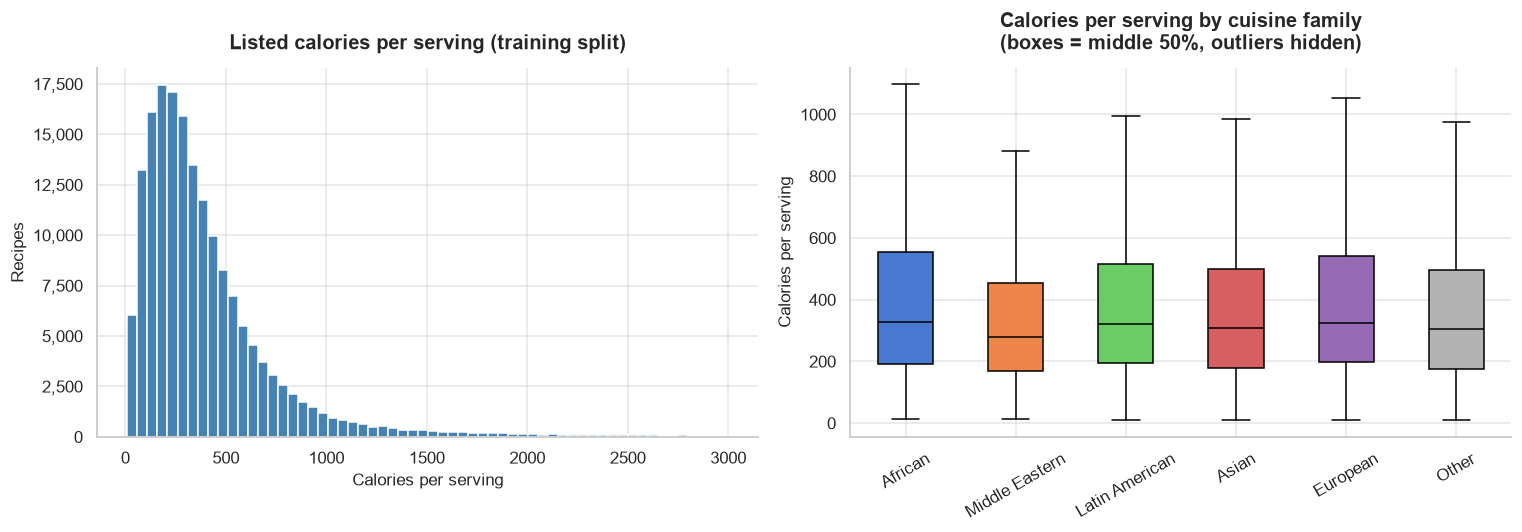

In [61]:
# Real (listed) calories only: the estimates from 5.8 are summarized there
listed = train_df[train_df["nutrition_plausible"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of calories per serving (full training set)
axes[0].hist(listed["calories_per_serving"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Calories per serving")
axes[0].set_ylabel("Recipes")
thousands(axes[0])
axes[0].set_title("Listed calories per serving (training split)")

# Right: Box plot of calories by cuisine family
# (families with no recipes, such as African here, are left out)
families = [f for f in FAMILY_ORDER if (listed["cuisine_family"] == f).any()]
data_by_family = [
    listed[listed["cuisine_family"] == f]["calories_per_serving"].values
    for f in families
]
boxes = axes[1].boxplot(data_by_family, patch_artist=True, showfliers=False,
                        medianprops={"color": "black"})
for box, family in zip(boxes["boxes"], families):
    box.set_facecolor(FAMILY_COLORS[family])
axes[1].set_xticks(range(1, len(families) + 1))
axes[1].set_xticklabels(families, rotation=30)
axes[1].set_ylabel("Calories per serving")
axes[1].set_title("Calories per serving by cuisine family\n(boxes = middle 50%, outliers hidden)")

show_figure(fig, "11_calories_per_serving")

#### 6.1.1.2 Calorie statistics by cuisine family

In [62]:
# Numeric summary of calories by cuisine family
print("Listed calorie statistics by cuisine family (training set):")
print(
    train_df[train_df["nutrition_plausible"]].groupby("cuisine_family")["calories_per_serving"]
    .agg(["count", "mean", "median", "std"])
    .round(1)
    .to_string()
)

Listed calorie statistics by cuisine family (training set):
                 count   mean  median    std
cuisine_family                              
African           1787  417.7   328.9  334.4
Asian             9885  385.7   308.1  314.6
European         24973  422.1   324.6  347.5
Latin American    8144  404.0   321.8  327.7
Middle Eastern    1762  364.3   279.2  306.2
Other           125168  403.9   305.3  373.3


---

### 6.1.2 Cuisine Coverage

> **What it shows:** How many training recipes each cuisine family has. African and Middle Eastern are much smaller than the others.

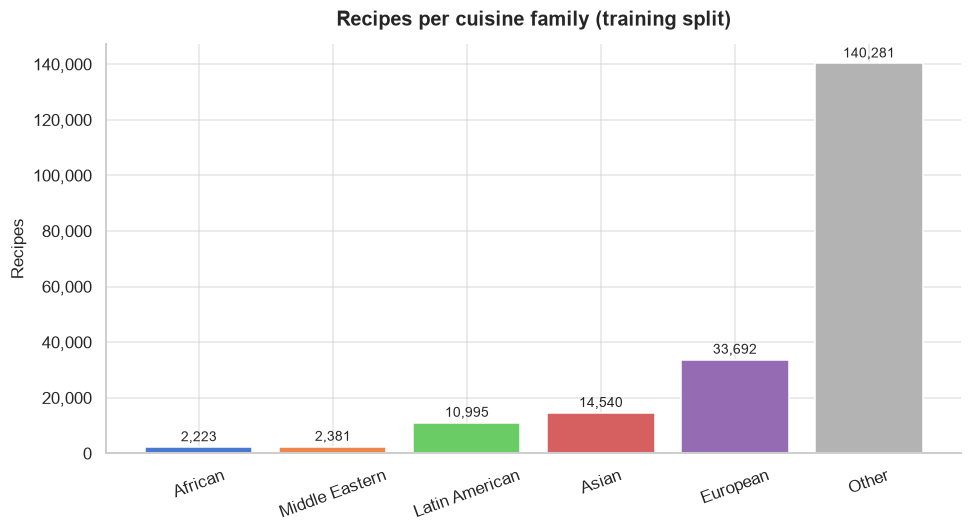


Cuisine counts:
cuisine_family
African             2223
Middle Eastern      2381
Latin American     10995
Asian              14540
European           33692
Other             140281


In [63]:
cuisine_counts = train_df["cuisine_family"].value_counts().reindex(FAMILY_ORDER).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cuisine_counts.index, cuisine_counts.values,
       color=[FAMILY_COLORS[f] for f in cuisine_counts.index])
label_bars(ax)
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title("Recipes per cuisine family (training split)")
ax.tick_params(axis="x", rotation=20)
show_figure(fig, "12_cuisine_coverage")

print("\nCuisine counts:")
print(cuisine_counts.to_string())

---

### 6.1.3 Most Frequent Ingredients (All Sources)

> **What it shows:** The 20 most used ingredients across all sources, after normalizing.

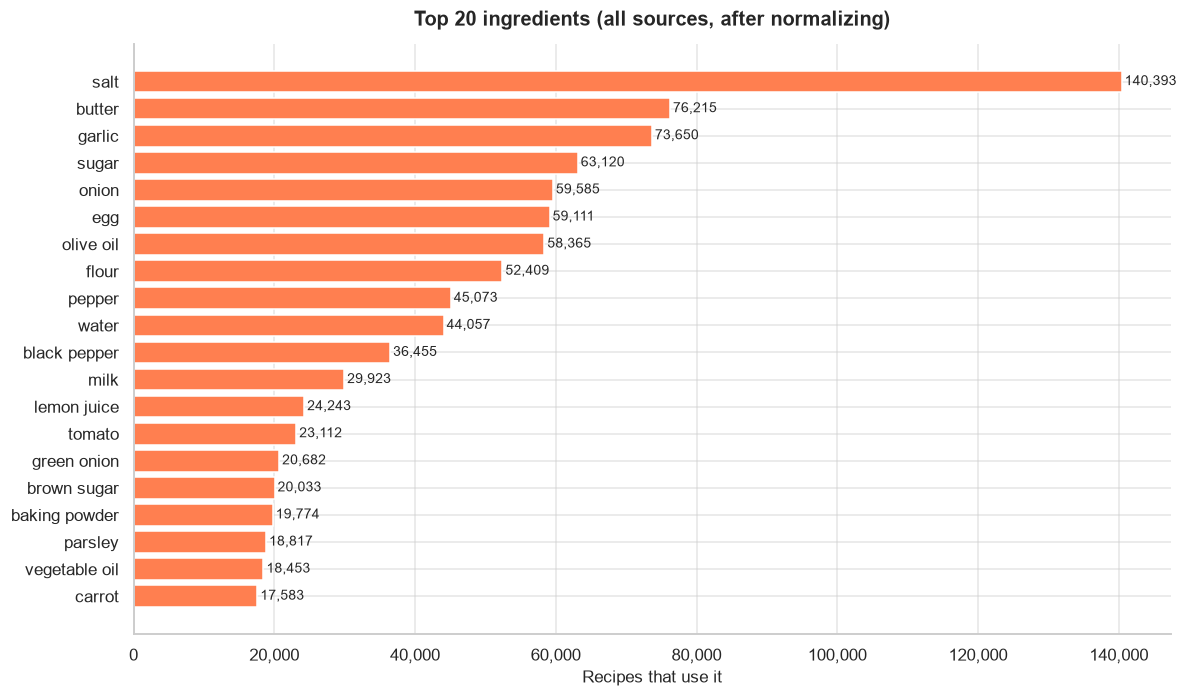


Top 20 ingredients:
  salt                           140,393
  butter                         76,215
  garlic                         73,650
  sugar                          63,120
  onion                          59,585
  egg                            59,111
  olive oil                      58,365
  flour                          52,409
  pepper                         45,073
  water                          44,057
  black pepper                   36,455
  milk                           29,923
  lemon juice                    24,243
  tomato                         23,112
  green onion                    20,682
  brown sugar                    20,033
  baking powder                  19,774
  parsley                        18,817
  vegetable oil                  18,453
  carrot                         17,583


In [64]:
# Use the combined table from 5.6 (or reload it after a restart)
try:
    _ = df_all
except NameError:
    df_all = pd.read_parquet("data/interim/recipes_all.parquet")

# Flatten all ingredient lists into a single list of names
# (Parquet returns lists as arrays, so convert each one)
all_ingredients = []
for lst in df_all["ingredient_list"]:
    if lst is not None:
        all_ingredients.extend(list(lst))

top_ingredients = Counter(all_ingredients).most_common(20)
names, counts = zip(*top_ingredients)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(names[::-1], counts[::-1], color="coral")
label_bars(ax)
ax.set_xlabel("Recipes that use it")
thousands(ax, "x")
ax.set_title("Top 20 ingredients (all sources, after normalizing)")
show_figure(fig, "13_top_ingredients")

print("\nTop 20 ingredients:")
for name, count in top_ingredients:
    print(f"  {name:30s} {count:,}")

---

### 6.1.4 Recipe Complexity Distribution (All Sources)

> **What it shows:** How many different ingredients a recipe uses.

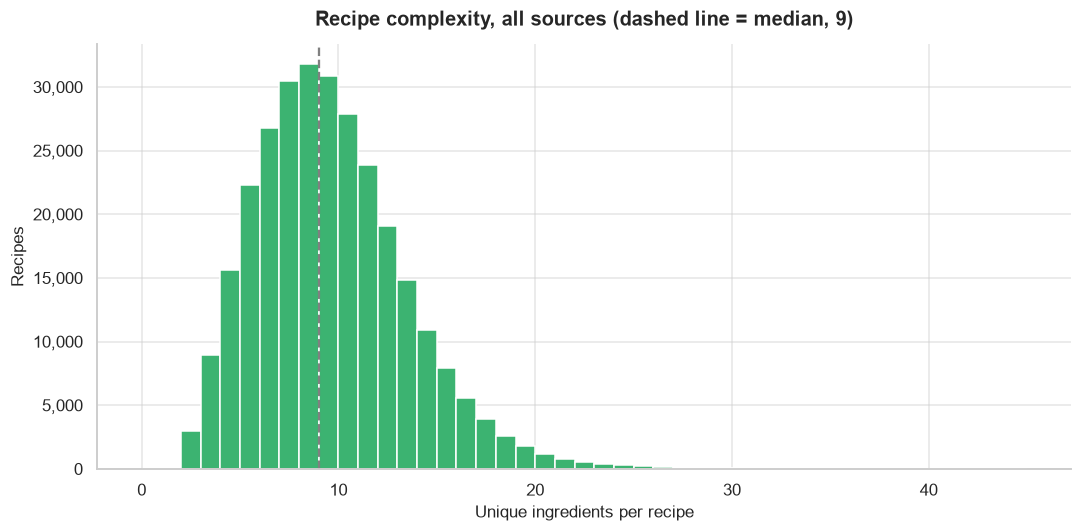

Complexity statistics:
count    291771.000000
mean          9.138598
std           3.841381
min           2.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          44.000000
Name: complexity, dtype: float64


In [65]:
fig, ax = plt.subplots(figsize=(10, 5))
complexity = df_all["complexity"].dropna()
ax.hist(complexity, bins=range(int(complexity.max()) + 2), color="mediumseagreen", edgecolor="white")
ax.axvline(complexity.median(), ls="--", color="gray")
ax.set_xlabel("Unique ingredients per recipe")
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title(f"Recipe complexity, all sources (dashed line = median, {complexity.median():.0f})")
show_figure(fig, "14_recipe_complexity")

print("Complexity statistics:")
print(df_all["complexity"].describe())

### 6.1.5 Recipe Complexity vs Calories

Do recipes with more ingredients have more calories? We compare the number of ingredients with two measures, using recipes with **listed** calories only:

- **calories per serving**, as listed by the source;
- **calorie density of the ingredients**: the average USDA energy per 100 g of the recipe's ingredients (from the USDA ingredient table in 5.8.2). It shows whether a recipe is built from energy-dense ingredients (oil, butter, sugar, nuts) or light ones (vegetables, broth), independent of portion size.

> **What it shows:** Left: the typical calories per serving for each number of ingredients (line = median, band = middle 50% of recipes). Right: the typical calorie density of the ingredients. A flat line means the number of ingredients says little about calories.

**What we found:** recipes with more ingredients have more calories per serving, but their ingredients are, on average, slightly *less* energy-dense. Longer recipes are bigger, fuller dishes (mains with several components), not richer ones. For the Chef Agent, the number of ingredients is a useful hint for both effort and portion size.

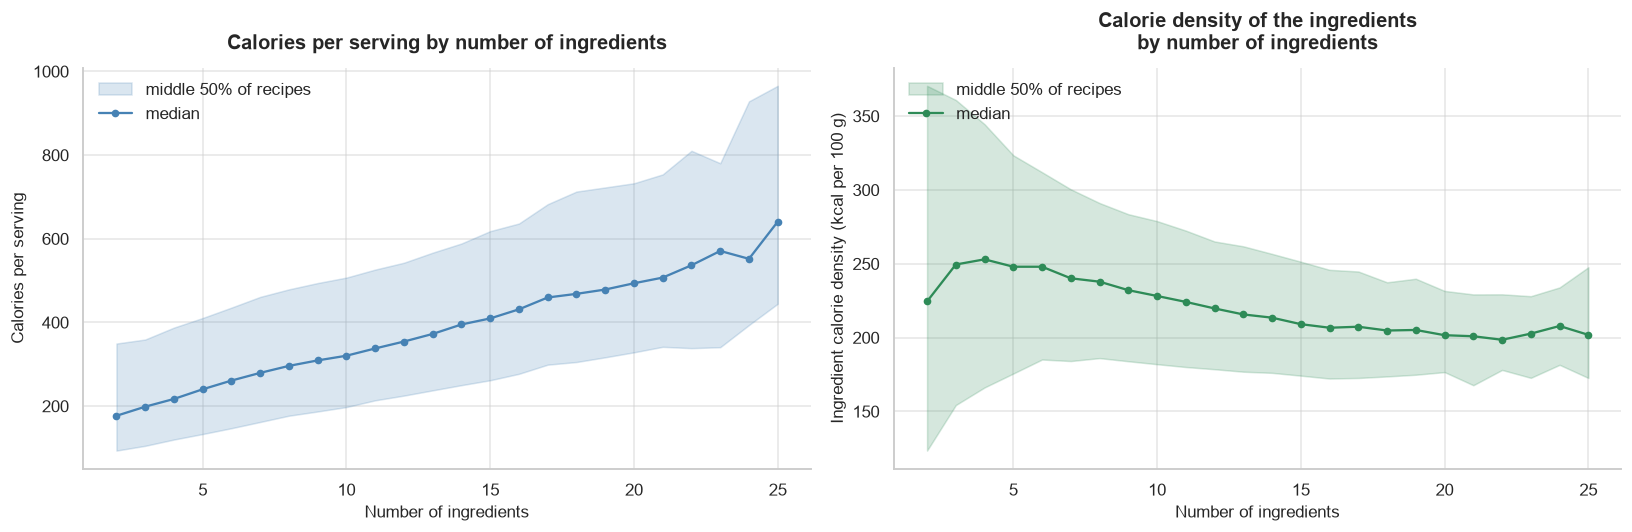

Recipes with listed calories (training split): 171,719
Rank correlation, ingredients vs calories per serving : +0.24
Rank correlation, ingredients vs ingredient density   : -0.14
Rank correlation, ingredient density vs calories      : +0.08

Median calories per serving by number of ingredients:
            recipes  kcal_median  density_median
complexity                                      
3              4770        199.0           250.0
5             12703        240.0           248.0
8             19109        296.0           238.0
10            16842        320.0           228.0
15             4592        410.0           209.0
20              619        494.0           202.0
25               73        641.0           202.0


In [66]:
# The USDA ingredient table is read from its file (5.8.2), so this works after a restart
ingredient_kcal_100g = (pd.read_csv("data/processed/usda_ingredient_nutrition.csv")
                        .set_index("ingredient")["kcal_100g"])

listed = train_df[train_df["nutrition_plausible"]].copy()
# One row per (recipe, ingredient), then the average energy per 100 g for each recipe
per_ingredient = pd.to_numeric(listed["ingredient_list"].explode().map(ingredient_kcal_100g), errors="coerce")
listed["ingredient_kcal_100g"] = per_ingredient.groupby(level=0).mean()

MAX_SHOWN = 25   # few recipes have more ingredients than this
by_count = (listed[listed["complexity"] <= MAX_SHOWN].groupby("complexity")
            .agg(recipes=("recipe_id", "size"),
                 kcal_median=("calories_per_serving", "median"),
                 kcal_q25=("calories_per_serving", lambda s: s.quantile(0.25)),
                 kcal_q75=("calories_per_serving", lambda s: s.quantile(0.75)),
                 density_median=("ingredient_kcal_100g", "median"),
                 density_q25=("ingredient_kcal_100g", lambda s: s.quantile(0.25)),
                 density_q75=("ingredient_kcal_100g", lambda s: s.quantile(0.75))))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, column, color, label in [
    (axes[0], "kcal", "steelblue", "Calories per serving"),
    (axes[1], "density", "seagreen", "Ingredient calorie density (kcal per 100 g)"),
]:
    ax.fill_between(by_count.index, by_count[f"{column}_q25"], by_count[f"{column}_q75"], color=color, alpha=0.2,
                    label="middle 50% of recipes")
    ax.plot(by_count.index, by_count[f"{column}_median"], color=color, marker="o", markersize=4, label="median")
    ax.set_xlabel("Number of ingredients")
    ax.set_ylabel(label)
    ax.legend(loc="upper left")
axes[0].set_title("Calories per serving by number of ingredients")
axes[1].set_title("Calorie density of the ingredients\nby number of ingredients")
show_figure(fig, "17_complexity_vs_calories")

# Rank correlation (Spearman): -1 to 1, where 0 means no relationship
correlation = listed[["complexity", "calories_per_serving", "ingredient_kcal_100g"]].corr(method="spearman")
print(f"Recipes with listed calories (training split): {len(listed):,}")
print(f"Rank correlation, ingredients vs calories per serving : {correlation.loc['complexity', 'calories_per_serving']:+.2f}")
print(f"Rank correlation, ingredients vs ingredient density   : {correlation.loc['complexity', 'ingredient_kcal_100g']:+.2f}")
print(f"Rank correlation, ingredient density vs calories      : {correlation.loc['ingredient_kcal_100g', 'calories_per_serving']:+.2f}")
print("\nMedian calories per serving by number of ingredients:")
print(by_count.loc[[n for n in (3, 5, 8, 10, 15, 20, 25) if n in by_count.index],
                   ["recipes", "kcal_median", "density_median"]].round(0).to_string())

---

## 6.2 Pattern Identification

Based on the analysis above, we identify the following key patterns and data challenges.

In [67]:
print("=" * 60)
print("KEY PATTERNS AND DATA CHALLENGES")
print("=" * 60)

FAMILIES = ["Asian", "European", "Latin American", "African", "Middle Eastern"]
total = cuisine_counts.sum()

# Pattern 1: Uneven cuisine coverage
dominant = cuisine_counts.idxmax()
print("\n1. UNEVEN CUISINE COVERAGE")
print(f"   '{dominant}' is the largest group at {cuisine_counts.max() / total * 100:.1f}% of training recipes.")
for family in FAMILIES:
    n = cuisine_counts.get(family, 0)
    print(f"   {family:15s}: {n:>7,} ({n / total * 100:.1f}%)")
print("   Action: Weight or oversample the smaller families when training models.")

# Pattern 2: Many recipes have no cuisine label
other_by_source = train_df.groupby("source")["cuisine_family"].apply(lambda s: (s == "Other").mean() * 100)
print("\n2. MANY RECIPES HAVE NO CUISINE FAMILY ('Other')")
for src, pct in other_by_source.items():
    print(f"   {src:12s}: {pct:.1f}% 'Other'")
print("   Food.com cuisine comes from tags, and many recipes have no cuisine tag.")
print("   Action: Predict cuisine for unlabeled recipes from their ingredients (Week 7).")

# Pattern 3: Calorie outliers
q99 = train_df.loc[train_df["nutrition_plausible"], "calories_per_serving"].quantile(0.99)
print("\n3. CALORIE OUTLIERS")
print("   Hugging Face calories were whole-recipe totals; they are now divided by servings.")
print(f"   Recipes above {MAX_KCAL_PER_SERVING:,} kcal per serving or {MAX_SERVINGS} servings were removed.")
print(f"   99th percentile is now {q99:,.0f} kcal per serving.")
print("   Action: Review the remaining high values; some 'servings' fields may be wrong.")

# Pattern 4: Ingredient name variation
n_unique = len(set(all_ingredients))
print("\n4. INGREDIENT NAME VARIATION")
print(f"   After normalization there are still {n_unique:,} unique ingredient names.")
print("   Brand names, descriptions ('low-fat', 'boneless') and synonyms remain.")
print("   Action: Extend the synonym dictionary in 5.4.4, or map names to USDA foods.")

# Pattern 5: Nutrition data completeness
has_kcal = train_df.groupby("source")["nutrition_plausible"].mean() * 100
print("\n5. NUTRITION DATA COMPLETENESS")
for src, pct in has_kcal.items():
    print(f"   {src:12s}: {pct:.0f}% of recipes have listed calories; the rest are estimated (5.8)")
print("   Food.com macros are converted from percent daily values (approximate).")
print("   Action: Estimates (with a likely range) fill the gap; prefer listed values when ranking.")

print("\n" + "=" * 60)

KEY PATTERNS AND DATA CHALLENGES

1. UNEVEN CUISINE COVERAGE
   'Other' is the largest group at 68.7% of training recipes.
   Asian          :  14,540 (7.1%)
   European       :  33,692 (16.5%)
   Latin American :  10,995 (5.4%)
   African        :   2,223 (1.1%)
   Middle Eastern :   2,381 (1.2%)
   Action: Weight or oversample the smaller families when training models.

2. MANY RECIPES HAVE NO CUISINE FAMILY ('Other')
   culinarydb  : 37.9% 'Other'
   foodcom     : 77.9% 'Other'
   huggingface : 45.7% 'Other'
   themealdb   : 5.7% 'Other'
   Food.com cuisine comes from tags, and many recipes have no cuisine tag.
   Action: Predict cuisine for unlabeled recipes from their ingredients (Week 7).

3. CALORIE OUTLIERS
   Hugging Face calories were whole-recipe totals; they are now divided by servings.
   Recipes above 3,000 kcal per serving or 50 servings were removed.
   99th percentile is now 2,017 kcal per serving.
   Action: Review the remaining high values; some 'servings' fields may

---

## 6.3 Simple Baseline Model

Before building a sophisticated recommendation engine, we establish a rule-based baseline. The baseline logic is:

1. Filter recipes by cuisine family.
2. Apply dietary restriction filters (e.g., vegetarian only, or a list of flags to avoid such as pork and alcohol).
3. Keep only recipes with plausible nutrition data (5.6).
4. Rank the remaining recipes by how close their calorie count is to the user's target.
5. **Safety filter:** re-check each candidate's ingredients and name with the keyword rules from 5.4.2, independently of the stored flags, and drop any that fail. This mirrors the hard-coded filter the final system runs after the agents generate a recipe.
6. Return the top N results.

This baseline directly mirrors the core task of the Nutritionist Agent and gives us a measurable starting point to improve on.

In [68]:
# The safety filter reuses the keyword rules from 5.4.2
if "make_flag" not in globals():
    raise RuntimeError("Run the cells in section 5.4.2 first: the safety filter uses their keyword rules.")


def passes_safety_filter(row, avoid=(), vegetarian=False, vegan=False):
    """Re-check one recipe's ingredients and name against the restrictions.

    Independent of the stored flags, so a wrong flag cannot let a recipe through.
    """
    text = ingredient_text(row["ingredient_list"]) + " | " + str(row["recipe_name"]).lower()
    for flag in avoid:
        keywords, exceptions = FLAG_RULES[flag]
        if make_flag(text, keywords, exceptions):
            return False
    if vegetarian and make_flag(text, MEAT_KEYWORDS, MEAT_EXCEPTIONS):
        return False
    return not (vegan and make_flag(text, ANIMAL_KEYWORDS, ANIMAL_EXCEPTIONS))


def baseline_recommend(
    df,
    cuisine_family=None,
    calorie_target=500,
    vegetarian_only=False,
    vegan_only=False,
    gluten_free=False,
    avoid=(),
    top_n=5
):
    """Simple rule-based recipe recommender (baseline model).

    Filters by cuisine and dietary flags, then ranks by
    proximity to the calorie target.

    Args:
        df (pd.DataFrame): The preprocessed recipe dataframe.
        cuisine_family (str | None): One of the five EverFlavor families, or None for all.
        calorie_target (float): Desired calories per serving.
        vegetarian_only (bool): Restrict to vegetarian recipes.
        vegan_only (bool): Restrict to vegan recipes.
        gluten_free (bool): Restrict to gluten-free recipes.
        avoid (tuple): Flag columns to exclude, e.g. ("contains_pork", "contains_alcohol").
        top_n (int): Number of recommendations to return.

    Returns:
        pd.DataFrame: Top N matching recipes sorted by calorie distance.
    """
    results = df.copy()

    # Step 1: Filter by cuisine family
    if cuisine_family:
        results = results[results["cuisine_family"] == cuisine_family]

    # Step 2: Apply dietary flags
    if vegetarian_only:
        results = results[results["vegetarian"] == True]
    if vegan_only:
        results = results[results["vegan"] == True]
    if gluten_free:
        results = results[results["contains_gluten"] == False]
    for flag in avoid:
        results = results[results[flag] == False]

    # Step 3: Keep only recipes with plausible nutrition data
    results = results[results["nutrition_plausible"]]

    if results.empty:
        print("No recipes matched the given filters.")
        return pd.DataFrame()

    # Step 4: Rank by distance to calorie target
    results["calorie_distance"] = (results["calories_per_serving"] - calorie_target).abs()
    results = results.sort_values("calorie_distance")

    # Step 5: Safety filter on the best candidates
    all_avoid = tuple(avoid) + (("contains_gluten",) if gluten_free else ())
    candidates = results.head(top_n * 20)
    safe = candidates[candidates.apply(
        lambda r: passes_safety_filter(r, all_avoid, vegetarian_only, vegan_only), axis=1)]
    if len(safe) < len(candidates):
        print(f"(safety filter removed {len(candidates) - len(safe)} of {len(candidates)} candidates)")

    return safe.head(top_n)


# Columns shown for every test below
display_cols = ["recipe_name", "source", "cuisine_family", "calories_per_serving",
                "vegetarian", "calorie_distance"]

BASELINE_TESTS = [
    ("Test 1: Asian vegetarian recipes near 400 kcal per serving",
     {"cuisine_family": "Asian", "calorie_target": 400, "vegetarian_only": True}),
    ("Test 2: Middle Eastern gluten-free recipes near 600 kcal per serving",
     {"cuisine_family": "Middle Eastern", "calorie_target": 600, "gluten_free": True}),
    ("Test 3: Middle Eastern, no pork or alcohol, near 550 kcal (the README example)",
     {"cuisine_family": "Middle Eastern", "calorie_target": 550,
          "avoid": ("contains_pork", "contains_alcohol")}),
    ("Test 4: African vegetarian recipes near 500 kcal per serving",
     {"cuisine_family": "African", "calorie_target": 500, "vegetarian_only": True}),
]

# -------------------------------------------------------
# Test the baseline on the training split
# -------------------------------------------------------
for title, kwargs in BASELINE_TESTS:
    print(f"Baseline {title}")
    print("-" * 60)
    recs = baseline_recommend(train_df, top_n=5, **kwargs)
    if not recs.empty:
        print(recs[display_cols].to_string(index=False))
    print()

Baseline Test 1: Asian vegetarian recipes near 400 kcal per serving
------------------------------------------------------------


                    recipe_name      source cuisine_family  calories_per_serving  vegetarian  calorie_distance
               Besanwali Bhindi huggingface          Asian            399.812699        True          0.187301
                    muslim naan     foodcom          Asian            399.600000        True          0.400000
tamarind rice with sesame seeds     foodcom          Asian            399.400000        True          0.600000
       lip smackin almond halwa     foodcom          Asian            400.600000        True          0.600000
   Indian Spinach and Chickpeas huggingface          Asian            399.308023        True          0.691977

Baseline Test 2: Middle Eastern gluten-free recipes near 600 kcal per serving
------------------------------------------------------------
                                            recipe_name      source cuisine_family  calories_per_serving  vegetarian  calorie_distance
                                  Smoky Fried Chickpeas hug

                                                recipe_name  source cuisine_family  calories_per_serving  vegetarian  calorie_distance
                                             impossible pie foodcom        African                 499.2        True               0.8
                  sweetened condensed milk biscuits cookies foodcom        African                 502.3        True               2.3
cumin spiced honey carrots with lemon coriander vinaigrette foodcom        African                 497.1        True               2.9
                vegetables couscous with caramelised onions foodcom        African                 496.4        True               3.6
                               diphaphata stove top muffins foodcom        African                 504.5        True               4.5



---

## 6.4 Key Insights for the Three EverFlavor Agents

Based on the Week 6 analysis, we draw actionable conclusions for each agent.

In [69]:
# Numbers quoted below are computed from the data, not typed in
kcal = train_df.loc[train_df["nutrition_plausible"], "calories_per_serving"]
kcal_q25, kcal_median, kcal_q75 = kcal.quantile([0.25, 0.5, 0.75])
cx = df_all["complexity"]
top_4 = ", ".join(name for name, _ in top_ingredients[:4])
african_n = (train_df["cuisine_family"] == "African").sum()
mideast_n = (train_df["cuisine_family"] == "Middle Eastern").sum()
with_steps = df_all["instructions"].notna().mean() * 100

print("=" * 65)
print("INSIGHTS FOR THE THREE EVERFLAVOR AGENTS")
print("=" * 65)

print(f"""
NUTRITIONIST AGENT
------------------
- Calories per serving are right-skewed. Half of the training recipes
  with calorie data fall between {kcal_q25:,.0f} and {kcal_q75:,.0f} kcal (median {kcal_median:,.0f} kcal).
- Protein, fat, carbs and sodium are now in grams per serving: exact
  for Hugging Face, converted from percent daily values for Food.com,
  and estimated in 5.8 for CulinaryDB, TheMealDB and recipes with
  unbelievable values (labeled 'estimated', with a likely range).
- Restriction flags cover pork, alcohol, gluten, dairy, egg, peanut,
  tree nut, fish, shellfish, soy and sesame, plus vegetarian and vegan.
  They are keyword-based (with Hugging Face labels where they exist),
  so they are a first filter, not a guarantee.
- USDA data is the ground truth for ingredient-level nutrition:
  data/processed/usda_ingredient_nutrition.csv has per-100 g values
  for the matched ingredients, and each recipe names its closest USDA dish.

CHEF AGENT
----------
- The most common ingredients ({top_4}) are generic
  staples. Culturally specific ingredients appear less often,
  which will require extra attention when generating authentic recipes.
- Recipe complexity ranges from {cx.min():.0f} to {cx.max():.0f} unique ingredients
  (median {cx.median():.0f}). The Chef Agent should present simpler recipes
  (fewer than 10 ingredients) to beginner users and more complex ones
  to experienced cooks.
- The training set has {african_n:,} African and {mideast_n:,} Middle Eastern recipes,
  mostly from Food.com cuisine tags, CulinaryDB and TheMealDB.
- {with_steps:.0f}% of recipes include cooking instructions (Food.com and TheMealDB).

SOURCING AGENT
--------------
- Specialty ingredients (miso paste, tahini, plantain, harissa, etc.)
  are not commonly stocked at general supermarkets.
- The Google Places API integration should use cuisine family as the
  primary search tag (e.g., 'Asian grocery store near me').
- A fallback should suggest online retailers for ingredients that
  are not available locally.
""")
print("=" * 65)

INSIGHTS FOR THE THREE EVERFLAVOR AGENTS

NUTRITIONIST AGENT
------------------
- Calories per serving are right-skewed. Half of the training recipes
  with calorie data fall between 181 and 505 kcal (median 309 kcal).
- Protein, fat, carbs and sodium are now in grams per serving: exact
  for Hugging Face, converted from percent daily values for Food.com,
  and estimated in 5.8 for CulinaryDB, TheMealDB and recipes with
  unbelievable values (labeled 'estimated', with a likely range).
- Restriction flags cover pork, alcohol, gluten, dairy, egg, peanut,
  tree nut, fish, shellfish, soy and sesame, plus vegetarian and vegan.
  They are keyword-based (with Hugging Face labels where they exist),
  so they are a first filter, not a guarantee.
- USDA data is the ground truth for ingredient-level nutrition:
  data/processed/usda_ingredient_nutrition.csv has per-100 g values
  for the matched ingredients, and each recipe names its closest USDA dish.

CHEF AGENT
----------
- The most common ing

---

## 6.5 Final Dataset Summary

In [70]:
# Counts are read from memory, or from the saved files after a restart
def saved_rows(csv_path):
    """Return the saved CSV as a dataframe, or an empty one if it is missing."""
    return pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()


def split_rows(var_name, parquet_path):
    """Number of rows in a split, from memory if loaded, else from its file."""
    if var_name in globals():
        return len(globals()[var_name])
    if os.path.exists(parquet_path):
        return len(pd.read_parquet(parquet_path, columns=["recipe_id"]))
    return 0

usda_saved = saved_rows("data/raw/usda_sample.csv")
off_saved  = saved_rows("data/raw/open_food_facts_sample.csv")
off_queries_with_results = off_saved["search_query"].nunique() if not off_saved.empty else 0

print("=" * 65)
print("FINAL PREPROCESSED DATASET SUMMARY")
print("=" * 65)

print("\nCOMBINED RECIPE TABLE")
print(f"  Total recipes (cleaned, duplicates removed): {len(df_all):,}")
print(f"  Columns                                    : {df_all.shape[1]}")
print("  Saved to                                   : data/interim/recipes_all.parquet")
print("\n  Recipes by source:")
for src, n in df_all["source"].value_counts().items():
    print(f"    {src:14s} {n:>8,}")
print("\n  Recipes by cuisine family:")
for family, n in df_all["cuisine_family"].value_counts().items():
    print(f"    {family:14s} {n:>8,}")

print("\n  Nutrition (calories per serving):")
for source, n in df_all["nutrition_source"].value_counts().items():
    print(f"    {source:14s} {n:>8,}")

print(f"""
SPLITS (stratified by cuisine family, near-duplicates kept together)
  Train set                     : {split_rows('train_df', 'data/processed/recipes_train.parquet'):,} rows
  Validation set                : {split_rows('val_df', 'data/processed/recipes_val.parquet'):,} rows
  Test set                      : {split_rows('test_df', 'data/processed/recipes_test.parquet'):,} rows
  Saved to                      : data/processed/recipes_train/val/test.parquet

USDA SAMPLE
  Ingredients saved             : {len(usda_saved)}
  Saved to                      : data/raw/usda_sample.csv

OPEN FOOD FACTS SAMPLE
  Queries with results          : {off_queries_with_results}
  Product records saved         : {len(off_saved)}
  Saved to                      : data/raw/open_food_facts_sample.csv
""")
print("=" * 65)

FINAL PREPROCESSED DATASET SUMMARY

COMBINED RECIPE TABLE
  Total recipes (cleaned, duplicates removed): 291,771
  Columns                                    : 39
  Saved to                                   : data/interim/recipes_all.parquet

  Recipes by source:
    foodcom         218,034
    huggingface      37,826
    culinarydb       35,328
    themealdb           583

  Recipes by cuisine family:
    Other           200,541
    European         48,151
    Asian            20,788
    Latin American   15,706
    Middle Eastern    3,406
    African           3,179

  Nutrition (calories per serving):
    listed          245,463
    estimated        46,308

SPLITS (stratified by cuisine family, near-duplicates kept together)
  Train set                     : 204,112 rows
  Validation set                : 43,885 rows
  Test set                      : 43,774 rows
  Saved to                      : data/processed/recipes_train/val/test.parquet

USDA SAMPLE
  Ingredients saved           

---

## 6.6 Preparing for Week 7: Leak-Free Features and Evaluation

Week 7 trains real models. This section sets up the parts every model needs and tests them with a simple **baseline cuisine classifier** (predict the cuisine family from the ingredients):

1. **Features learned from training data only.** The ingredient vocabulary is built inside a scikit-learn `Pipeline` that is fitted on the training split only. Validation and test recipes are only transformed, never used for fitting.
2. **Rare ingredients dropped.** Ingredients that appear in fewer than 5 training recipes are left out of the vocabulary.
3. **Labeled recipes only, with class weights.** The classifier learns from recipes with a real cuisine label. Class weights make the small African and Middle Eastern families count as much as the large ones.
4. **Evaluation on the validation split.** We report macro-F1, which gives each cuisine equal weight, plus per-cuisine scores and per-source results. The test split stays untouched for the final Week 7 evaluation.
5. **Saving and reuse.** The fitted pipeline is saved, so user input at prediction time gets exactly the same processing. We also check which of a user's ingredients the model has never seen.

#### 6.6.1 Feature pipeline and class weights

In [71]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

MIN_INGREDIENT_COUNT = 5   # ingredients in fewer training recipes are dropped


def ingredient_tokens(ingredients):
    """Analyzer for CountVectorizer: each normalized ingredient is one token.

    Defined at the top level so the saved pipeline can be loaded again
    (define this function before calling joblib.load in another notebook).
    """
    return list(ingredients)

# Cuisine models learn only from recipes with a real cuisine label
train_labeled = train_df[train_df["cuisine_labeled"]]
val_labeled   = val_df[val_df["cuisine_labeled"]]

cuisine_model = Pipeline([
    ("ingredients", CountVectorizer(analyzer=ingredient_tokens, min_df=MIN_INGREDIENT_COUNT, binary=True)),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
# Fitted on TRAIN only: the vocabulary and weights never see val/test data
cuisine_model.fit(train_labeled["ingredient_list"], train_labeled["cuisine_family"])

vocab = cuisine_model.named_steps["ingredients"].vocabulary_
n_train_ingredients = len({i for l in train_labeled["ingredient_list"] for i in l})
print(f"Training recipes with a cuisine label: {len(train_labeled):,}")
print(f"Ingredient vocabulary: {len(vocab):,} kept of {n_train_ingredients:,} "
      f"(those in fewer than {MIN_INGREDIENT_COUNT} recipes were dropped)")

classes = np.array(sorted(train_labeled["cuisine_family"].unique()))
weights = compute_class_weight("balanced", classes=classes, y=train_labeled["cuisine_family"])
print("\nClass weights (higher = smaller family, counted more):")
for family, w in zip(classes, weights):
    print(f"  {family:15s} {w:5.2f}")

Training recipes with a cuisine label: 63,831
Ingredient vocabulary: 4,624 kept of 24,142 (those in fewer than 5 recipes were dropped)

Class weights (higher = smaller family, counted more):
  African          5.74
  Asian            0.88
  European         0.38
  Latin American   1.16
  Middle Eastern   5.36


#### 6.6.2 Evaluate on the validation split

In [72]:
from sklearn.metrics import accuracy_score, classification_report, f1_score


def evaluate_cuisine_model(model, df):
    """Print overall, per-cuisine and per-source results; return predictions."""
    pred = pd.Series(model.predict(df["ingredient_list"]), index=df.index)
    true = df["cuisine_family"]
    print(f"Macro-F1 : {f1_score(true, pred, average='macro'):.3f}  (each cuisine counts equally)")
    print(f"Accuracy : {accuracy_score(true, pred):.3f}")
    print("\nPer cuisine:")
    print(classification_report(true, pred, digits=3))
    print("Per source (error analysis by slice):")
    for src_name, g in df.groupby("source"):
        print(f"  {src_name:12s} n={len(g):>6,}  macro-F1={f1_score(g['cuisine_family'], pred[g.index], average='macro'):.3f}"
              f"  accuracy={accuracy_score(g['cuisine_family'], pred[g.index]):.3f}")
    return pred

print("VALIDATION RESULTS (the test split stays untouched until Week 7)")
print("=" * 60)
val_pred = evaluate_cuisine_model(cuisine_model, val_labeled)

print("\nMost common confusions (true -> predicted):")
pairs = pd.DataFrame({"true": val_labeled["cuisine_family"], "predicted": val_pred})
confusions = pairs[pairs["true"] != pairs["predicted"]].value_counts().head(5)
print(confusions.to_string())

print("\nExamples of African recipes predicted as something else:")
wrong = val_labeled[(val_labeled["cuisine_family"] == "African") & (val_pred != "African")]
for _, r in wrong.head(5).iterrows():
    print(f"  - {r['recipe_name']}  -> {val_pred[r.name]}")

VALIDATION RESULTS (the test split stays untouched until Week 7)
Macro-F1 : 0.624  (each cuisine counts equally)
Accuracy : 0.770

Per cuisine:


                precision    recall  f1-score   support

       African      0.250     0.523     0.338       480
         Asian      0.875     0.800     0.836      3128
      European      0.910     0.789     0.845      7223
Latin American      0.741     0.772     0.756      2358
Middle Eastern      0.252     0.548     0.345       511

      accuracy                          0.770     13700
     macro avg      0.605     0.686     0.624     13700
  weighted avg      0.825     0.770     0.791     13700

Per source (error analysis by slice):
  culinarydb   n= 3,320  macro-F1=0.650  accuracy=0.811
  foodcom      n= 7,194  macro-F1=0.646  accuracy=0.772
  huggingface  n= 3,105  macro-F1=0.480  accuracy=0.724
  themealdb    n=    81  macro-F1=0.536  accuracy=0.679

Most common confusions (true -> predicted):
true            predicted     
European        Middle Eastern    529
                Latin American    423
                African           368
Latin American  European          247
Eur

#### 6.6.3 Chart: where the baseline cuisine classifier gets it right and wrong

> **What it shows:** Left: which cuisines the baseline confuses (the diagonal is correct). Right: the F1 score for each cuisine; higher is better.

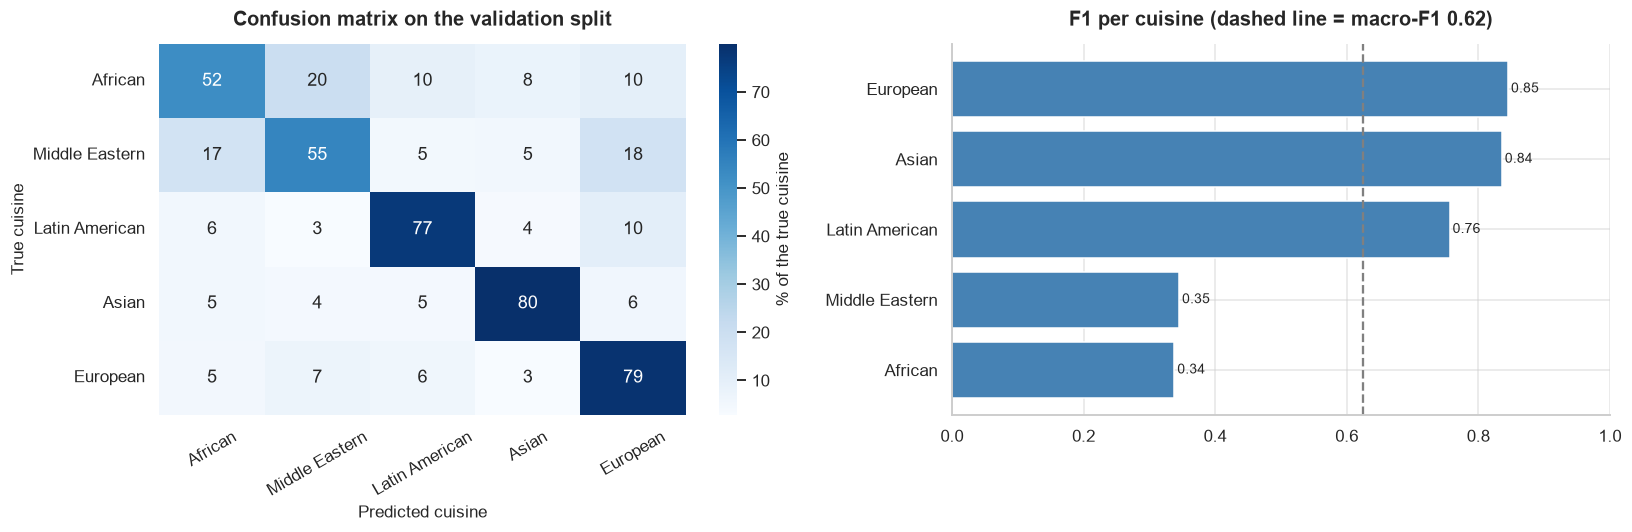

In [73]:
from sklearn.metrics import confusion_matrix

families = [f for f in FAMILY_ORDER if f != "Other"]
matrix = confusion_matrix(val_labeled["cuisine_family"], val_pred, labels=families, normalize="true") * 100
per_family_f1 = pd.Series(f1_score(val_labeled["cuisine_family"], val_pred, labels=families, average=None),
                          index=families)
macro = f1_score(val_labeled["cuisine_family"], val_pred, average="macro")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues", xticklabels=families, yticklabels=families,
            cbar_kws={"label": "% of the true cuisine"}, ax=axes[0])
axes[0].set_xlabel("Predicted cuisine")
axes[0].set_ylabel("True cuisine")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Confusion matrix on the validation split")
axes[1].barh(per_family_f1.index, per_family_f1.values, color="steelblue")
axes[1].axvline(macro, ls="--", color="gray")
axes[1].set_xlim(0, 1)
label_bars(axes[1], fmt="{:.2f}")
axes[1].set_title(f"F1 per cuisine (dashed line = macro-F1 {macro:.2f})")
show_figure(fig, "10_cuisine_baseline_results")

#### 6.6.4 Save the pipeline and check new ingredients

In [74]:
import joblib

# Save the fitted pipeline (models/ is git-ignored; it is recreated by this cell)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_FILE = MODEL_DIR / "cuisine_baseline.joblib"
joblib.dump(cuisine_model, MODEL_FILE)
print(f"Saved fitted pipeline to {MODEL_FILE} ({MODEL_FILE.stat().st_size / 1e6:.1f} MB)")


def check_user_ingredients(user_ingredients, model=cuisine_model):
    """Normalize a user's ingredients the same way as the training data and
    report which ones the model has never seen (useful for monitoring)."""
    normalized = normalize_ingredient_list(user_ingredients)
    vocab = model.named_steps["ingredients"].vocabulary_
    unseen = [i for i in normalized if i not in vocab]
    return normalized, unseen

example = ["2 cups basmati rice", "1 lb lamb shoulder, cubed", "berbere spice", "injera", "Chopped Onions"]
normalized, unseen = check_user_ingredients(example)
print("\nExample user input :", example)
print("Normalized         :", normalized)
print("Unseen by the model:", unseen or "none")
print("Predicted cuisine  :", cuisine_model.predict([normalized])[0])

Saved fitted pipeline to models\cuisine_baseline.joblib (0.3 MB)

Example user input : ['2 cups basmati rice', '1 lb lamb shoulder, cubed', 'berbere spice', 'injera', 'Chopped Onions']
Normalized         : ['basmati rice', 'lamb shoulder', 'berbere spice', 'injera', 'onion']
Unseen by the model: ['berbere spice', 'injera']
Predicted cuisine  : Middle Eastern


---

## Weeks 4-6 Completion Checklist

In [75]:
# Each item can name a file or folder that proves it was done.
# Items with a path are only ticked if that path exists;
# items without one (documentation steps) are ticked by hand.
checklist = [
    # Week 4
    ("WEEK 4", "Identified and documented all data sources", None),
    ("WEEK 4", "Created data/raw, data/interim, data/processed folders", "data/processed"),
    ("WEEK 4", "USDA FoodData Central API connected (key from Colab Secrets or .env)", "data/raw/usda_sample.csv"),
    ("WEEK 4", "USDA ingredient sample saved to data/raw/usda_sample.csv", "data/raw/usda_sample.csv"),
    ("WEEK 4", "Food.com dataset downloaded via kagglehub", None),
    ("WEEK 4", "Food.com 1,000-row sample saved to data/raw/food_com_sample.csv", "data/raw/food_com_sample.csv"),
    ("WEEK 4", "Hugging Face recipes-with-nutrition loaded via datasets library", None),
    ("WEEK 4", "Hugging Face 1,000-row sample saved to data/raw/hf_recipes_sample.csv", "data/raw/hf_recipes_sample.csv"),
    ("WEEK 4", "Open Food Facts fully integrated: search, barcode lookup, quality check, save", "data/raw/open_food_facts_sample.csv"),
    ("WEEK 4", "Open Food Facts sample saved to data/raw/open_food_facts_sample.csv", "data/raw/open_food_facts_sample.csv"),
    ("WEEK 4", "CulinaryDB recipes downloaded and saved", "data/raw/culinarydb_recipes.parquet"),
    ("WEEK 4", "TheMealDB recipes collected through its API and saved", "data/raw/themealdb_recipes.parquet"),
    ("WEEK 4", "Optional and later sources (RecipeDB, Google Places) documented", None),
    ("WEEK 4", "Privacy and ethics note written", None),
    # Week 5
    ("WEEK 5", "Missing value and duplicate analysis completed for both datasets", None),
    ("WEEK 5", "Outlier analysis completed (calories per serving, servings, cook time)", None),
    ("WEEK 5", "Data cleaning applied (drop missing, dedup, servings and calorie caps)", None),
    ("WEEK 5", "cuisine_family mapped for every source (labels, Food.com tags, regions)", None),
    ("WEEK 5", "Restriction flags engineered (pork, alcohol, gluten, dairy, 7 allergens, veg, vegan)", None),
    ("WEEK 5", "Flags checked against Food.com's own dietary tags", None),
    ("WEEK 5", "Macronutrients in grams per serving (Hugging Face exact, Food.com converted)", None),
    ("WEEK 5", "Ingredient lists cleaned, tokenized and normalized (quantities and units removed)", None),
    ("WEEK 5", "Nutrition plausibility checks (calories, sodium, protein, macros vs calories)", None),
    ("WEEK 5", "Recipe complexity feature created", None),
    ("WEEK 5", "Reusable run_pipeline() function built for every source", None),
    ("WEEK 5", "All sources combined into one table, duplicates removed", "data/interim/recipes_all.parquet"),
    ("WEEK 5", "Train/val/test split (70/15/15) stratified, near-duplicates kept together", "data/processed/recipes_test.parquet"),
    ("WEEK 5", "USDA FNDDS and SR Legacy reference data downloaded (official, no key)", "data/raw/usda_fdc"),
    ("WEEK 5", "Missing nutrition estimated (similar recipes + USDA), labeled, with a likely range", None),
    ("WEEK 5", "USDA ingredient nutrition table saved", "data/processed/usda_ingredient_nutrition.csv"),
    ("WEEK 5", "Automatic data validation checks passed", None),
    ("WEEK 5", "Dataset record saved (versions, settings, counts)", "data/processed/dataset_info.json"),
    ("WEEK 5", "Blind hand-check samples exported for flag review", "docs/flag_review/flag_review_sample_round2.csv"),
    ("WEEK 5", "Flags scored against a fresh labeled sample", "docs/flag_review/flag_review_labeled_round2.csv"),
    ("WEEK 5", "Processed files saved as Parquet", "data/processed/recipes_train.parquet"),
    # Week 6
    ("WEEK 6", "Calorie distribution visualized and analyzed", "data/processed/figures/11_calories_per_serving.png"),
    ("WEEK 6", "Cuisine coverage bar chart created", "data/processed/figures/12_cuisine_coverage.png"),
    ("WEEK 6", "Top 20 ingredient frequency chart created", "data/processed/figures/13_top_ingredients.png"),
    ("WEEK 6", "Recipe complexity distribution analyzed", "data/processed/figures/14_recipe_complexity.png"),
    ("WEEK 6", "Recipe complexity vs calories and calorie density analyzed", "data/processed/figures/17_complexity_vs_calories.png"),
    ("WEEK 6", "Five key data patterns identified", None),
    ("WEEK 6", "Baseline model (filters, avoid list, calorie ranking, safety filter) implemented", None),
    ("WEEK 6", "Key insights derived for Nutritionist, Chef, and Sourcing agents", None),
    ("WEEK 6", "Final dataset summary printed", None),
    ("WEEK 6", "Charts for raw data, cleaning, labels, flags, nutrition, normalization, combining, splits and results", "data/processed/figures/10_cuisine_baseline_results.png"),
    ("WEEK 6", "Charts for the nutrition estimates and calories by cuisine", "data/processed/figures/16_calories_by_cuisine.png"),
    ("WEEK 6", "Leak-free feature pipeline fitted on training data only", None),
    ("WEEK 6", "Cuisine baseline evaluated (macro-F1, per cuisine, per source)", None),
    ("WEEK 6", "Fitted pipeline saved for reuse at prediction time", "models/cuisine_baseline.joblib"),
]

current_week = None
completed = 0
for week, item, proof_path in checklist:
    if week != current_week:
        print(f"\n{'=' * 55}")
        print(f"  {week}")
        print(f"{'=' * 55}")
        current_week = week
    done = proof_path is None or os.path.exists(proof_path)
    completed += done
    note = "" if done else f"  (missing: {proof_path})"
    print(f"  [{'x' if done else ' '}] {item}{note}")

print(f"\nTotal items completed: {completed} / {len(checklist)}")
if completed == len(checklist):
    print("\nNotebook complete. Ready for Week 7 - Model Development.")
else:
    print("\nSome items are not done yet. Re-run the cells for the missing files above.")


  WEEK 4
  [x] Identified and documented all data sources
  [x] Created data/raw, data/interim, data/processed folders
  [x] USDA FoodData Central API connected (key from Colab Secrets or .env)
  [x] USDA ingredient sample saved to data/raw/usda_sample.csv
  [x] Food.com dataset downloaded via kagglehub
  [x] Food.com 1,000-row sample saved to data/raw/food_com_sample.csv
  [x] Hugging Face recipes-with-nutrition loaded via datasets library
  [x] Hugging Face 1,000-row sample saved to data/raw/hf_recipes_sample.csv
  [x] Open Food Facts fully integrated: search, barcode lookup, quality check, save
  [x] Open Food Facts sample saved to data/raw/open_food_facts_sample.csv
  [x] CulinaryDB recipes downloaded and saved
  [x] TheMealDB recipes collected through its API and saved
  [x] Optional and later sources (RecipeDB, Google Places) documented
  [x] Privacy and ethics note written

  WEEK 5
  [x] Missing value and duplicate analysis completed for both datasets
  [x] Outlier analysis co